# 📊 GroupBy Business Analysis

## SuperStore Sales Analytics

### From Transaction-Level Data to Business-Level Insights

---

## 📌 Overview

GroupBy Business Analysis is the next analytical stage after
Data Inspection, Data Cleaning, Feature Engineering, and EDA.

The objective is to transform transaction-level sales data into
meaningful business summaries using Pandas `groupby()`.

The analysis focuses on:

- 💰 Sales Performance
- 📈 Profitability
- 📦 Quantity & Orders
- 🛍️ Product Performance
- 👥 Customer Performance
- 🌎 Geographic Performance
- 🏷️ Category & Sub-Category Analysis
- 🚚 Shipping Analysis
- 💳 Payment Analysis
- 📅 Time-Based Performance

---

## 🎯 Business Objective

The main objective is to answer:

> **Which customers, products, categories, regions, and time periods
> are driving sales and profitability?**

GroupBy analysis converts raw transaction records into
decision-ready business summaries.

---

# 🔄 Analytical Workflow

```text
Feature-Engineered CSV
        ↓
Load Dataset
        ↓
Validate Data
        ↓
Identify Dimensions
        ↓
Identify Measures
        ↓
Basic GroupBy
        ↓
Multiple-Column GroupBy
        ↓
Aggregation Analysis
        ↓
Business KPIs
        ↓
Ranking & Comparison
        ↓
Business Insights

# 🧠 Business Questions

The GroupBy analysis should answer the following key business
questions.

---

## 💰 Sales

- Which category generates the most sales?
- Which region generates the most revenue?
- Which products are the top sellers?
- Which customers contribute the most revenue?

---

## 📈 Profitability

- Which category is most profitable?
- Which products generate losses?
- Which states have weak profitability?
- Which customers generate the highest profit?

---

## 👥 Customers

- Which customer segment has the highest sales?
- Which customers place the most orders?
- Which customers generate the highest profit?

---

## 🛍️ Products

- Which products sell the most?
- Which products generate the most profit?
- Which sub-categories perform poorly?

---

## 🌎 Geography

- Which region is strongest?
- Which states drive the most revenue?
- Which cities are major markets?

---

## 🚚 Operations

- Which shipping mode handles the most orders?
- Which payment mode is most commonly used?
- How do returns differ across business categories?

---

## 📅 Time

- Which year generated the highest sales?
- Which months perform best?
- Which periods generate the highest profit?

---

# ⚠️ Important Aggregation Rule

Business metrics should be calculated using the **original
transaction-level columns**.

### Original Analytical Columns

```text
Sales
Profit
Quantity
Order_ID
Customer_ID
Product_ID
````

Feature-engineered aggregate columns such as:

```text
Customer_Total_Sales
Product_Total_Sales
Region_Total_Sales
State_Total_Sales
City_Total_Sales
Category_Total_Sales
```

should **not be blindly summed**, because these values are repeated
across multiple transaction rows.

### ✅ Correct Approach

```text
Transaction Data
       ↓
GROUPBY Dimension
       ↓
Aggregate Original Metrics
       ↓
Business Metric
```

---

# 📦 Business Summary Tables

The GroupBy analysis will produce reusable analytical tables.

```text
category_performance
subcategory_performance
product_performance
customer_performance
segment_performance
region_performance
state_performance
city_performance
shipping_performance
payment_performance
return_performance
yearly_performance
monthly_performance
quarterly_performance
region_category
segment_category
region_segment
```

---

# 🎯 Final Outcome

The GroupBy analysis transforms transaction-level data into
business-level insights.

```text
5,901 Transaction Records
          ↓
     Pandas GROUPBY
          ↓
 Business Dimensions
          ↓
 Aggregated Metrics
          ↓
      Rankings
          ↓
Contribution Analysis
          ↓
    Business KPIs
          ↓
 Actionable Insights
```

---

# 🚀 Next Project Stages

```text
GroupBy Analysis
       ↓
SQL Business Analytics
       ↓
Power BI Data Model
       ↓
DAX Measures
       ↓
Interactive Dashboard
       ↓
Executive Business Insights
```

---

# 🏆 GroupBy Analysis Checklist

| Analysis                | Status |
| ----------------------- | :----: |
| Basic GroupBy           |    ⬜   |
| Multiple Aggregations   |    ⬜   |
| Category Analysis       |    ⬜   |
| Sub-Category Analysis   |    ⬜   |
| Product Analysis        |    ⬜   |
| Customer Analysis       |    ⬜   |
| Segment Analysis        |    ⬜   |
| Region Analysis         |    ⬜   |
| State Analysis          |    ⬜   |
| City Analysis           |    ⬜   |
| Shipping Analysis       |    ⬜   |
| Payment Analysis        |    ⬜   |
| Returns Analysis        |    ⬜   |
| Year Analysis           |    ⬜   |
| Month Analysis          |    ⬜   |
| Quarter Analysis        |    ⬜   |
| Multi-Dimension GroupBy |    ⬜   |
| Ranking Analysis        |    ⬜   |
| Contribution Analysis   |    ⬜   |
| Business KPIs           |    ⬜   |

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

# Display / Formatting
from IPython.display import display

# 📦 Required Libraries

The following Python libraries are used for GroupBy Business Analysis.

- **Pandas** → Data loading, grouping, aggregation, ranking, and analysis
- **NumPy** → Numerical calculations and business metrics
- **IPython.display** → Clean display of analytical DataFrames

Only the required libraries are imported to keep the notebook
simple, lightweight, and reproducible.

In [2]:
df = pd.read_csv("SuperStore_Feature_Engineered.csv")

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (5901, 54)


,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,...,City_Total_Profit,Segment_Total_Sales,Segment_Total_Profit,Category_Total_Sales,Category_Total_Profit,SubCategory_Total_Sales,SubCategory_Total_Profit,ShipMode_Order_Count,PaymentMode_Order_Count,Return_Flag
0,4918,CA-2019-160304,2019-01-01,2019-07-01,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,...,133.8078,509743.1262,57805.7991,451508.6452,10006.6112,57577.6862,-342.8883,1773,1562,0
1,4919,CA-2019-160304,2019-02-01,2019-07-01,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,...,133.8078,509743.1262,57805.7991,451508.6452,10006.6112,57577.6862,-342.8883,1773,1562,0
2,4920,CA-2019-160304,2019-02-01,2019-07-01,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,...,133.8078,509743.1262,57805.7991,470587.9910,90458.2486,196563.5460,22308.9179,1773,985,0
3,3074,CA-2019-125206,2019-03-01,2019-05-01,First Class,LR-16915,Lena Radford,Consumer,United States,Los Angeles,...,19174.9301,753002.1291,81338.5875,643707.6870,74797.2461,150341.3180,13607.0875,499,1562,0
4,8604,US-2019-116365,2019-03-01,2019-08-01,Standard Class,CA-12310,Christine Abelman,Corporate,United States,San Antonio,...,-23.1982,509743.1262,57805.7991,470587.9910,90458.2486,122301.0860,25336.6455,1773,1562,0


In [3]:
df.tail()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,...,City_Total_Profit,Segment_Total_Sales,Segment_Total_Profit,Category_Total_Sales,Category_Total_Profit,SubCategory_Total_Sales,SubCategory_Total_Profit,ShipMode_Order_Count,PaymentMode_Order_Count,Return_Flag
5896,907,CA-2020-143259,NaN,2021-03-01,Standard Class,PO-18865,Patrick O'Donnell,Consumer,United States,New York City,...,34760.2974,753002.1291,81338.5875,451508.6452,10006.6112,57577.6862,-342.8883,1773,1717,0
5897,1297,CA-2020-115427,NaN,2021-03-01,Standard Class,EB-13975,Erica Bern,Corporate,United States,Fairfield,...,907.3211,509743.1262,57805.7991,643707.6870,74797.2461,174978.3900,17885.3759,1773,1562,1
5898,5092,CA-2020-156720,NaN,2021-03-01,Standard Class,JM-15580,Jill Matthias,Consumer,United States,Loveland,...,3.8730,753002.1291,81338.5875,643707.6870,74797.2461,15205.2380,598.4175,1773,1562,0
5899,909,CA-2020-143259,NaN,2021-03-01,Standard Class,PO-18865,Patrick O'Donnell,Consumer,United States,New York City,...,34760.2974,753002.1291,81338.5875,643707.6870,74797.2461,174978.3900,17885.3759,1773,1717,0
5900,5093,CA-2020-151450,NaN,2021-04-01,Standard Class,JM-15580,Jill Matthias,Consumer,United States,Loveland,...,3.8730,753002.1291,81338.5875,643707.6870,74797.2461,15205.2380,598.4175,1773,1717,0


In [4]:
df.columns

Index(['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode',
       'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State',
       'Region', 'Product_ID', 'Category', 'Sub-Category', 'Product_Name',
       'Sales', 'Quantity', 'Profit', 'Returns', 'Payment_Mode', 'Order_Year',
       'Order_Quarter', 'Order_Month', 'Order_Month_Name', 'Order_Day',
       'Order_Day_Name', 'Shipping_Days', 'Sales_Per_Unit', 'Profit_Per_Unit',
       'Profit_Margin', 'Customer_Order_Count', 'Customer_Total_Sales',
       'Customer_Total_Profit', 'Product_Order_Count', 'Product_Total_Sales',
       'Product_Total_Profit', 'Product_Total_Quantity',
       'Product_Profit_Margin', 'Region_Total_Sales', 'Region_Total_Profit',
       'State_Total_Sales', 'State_Total_Profit', 'City_Total_Sales',
       'City_Total_Profit', 'Segment_Total_Sales', 'Segment_Total_Profit',
       'Category_Total_Sales', 'Category_Total_Profit',
       'SubCategory_Total_Sales', 'SubCategory_Total_Profit',
 

In [5]:
df.index

RangeIndex(start=0, stop=5901, step=1)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5901 entries, 0 to 5900
Data columns (total 54 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Row_ID                    5901 non-null   int64  
 1   Order_ID                  5901 non-null   str    
 2   Order_Date                2410 non-null   str    
 3   Ship_Date                 2351 non-null   str    
 4   Ship_Mode                 5901 non-null   str    
 5   Customer_ID               5901 non-null   str    
 6   Customer_Name             5901 non-null   str    
 7   Segment                   5901 non-null   str    
 8   Country                   5901 non-null   str    
 9   City                      5901 non-null   str    
 10  State                     5901 non-null   str    
 11  Region                    5901 non-null   str    
 12  Product_ID                5901 non-null   str    
 13  Category                  5901 non-null   str    
 14  Sub-Category       

In [7]:
for column, dtype in df.dtypes.items():
    print(f"{column} → {dtype}")

Row_ID → int64
Order_ID → str
Order_Date → str
Ship_Date → str
Ship_Mode → str
Customer_ID → str
Customer_Name → str
Segment → str
Country → str
City → str
State → str
Region → str
Product_ID → str
Category → str
Sub-Category → str
Product_Name → str
Sales → float64
Quantity → int64
Profit → float64
Returns → str
Payment_Mode → str
Order_Year → float64
Order_Quarter → float64
Order_Month → float64
Order_Month_Name → str
Order_Day → float64
Order_Day_Name → str
Shipping_Days → float64
Sales_Per_Unit → float64
Profit_Per_Unit → float64
Profit_Margin → float64
Customer_Order_Count → int64
Customer_Total_Sales → float64
Customer_Total_Profit → float64
Product_Order_Count → int64
Product_Total_Sales → float64
Product_Total_Profit → float64
Product_Total_Quantity → int64
Product_Profit_Margin → float64
Region_Total_Sales → float64
Region_Total_Profit → float64
State_Total_Sales → float64
State_Total_Profit → float64
City_Total_Sales → float64
City_Total_Profit → float64
Segment_Total_Sales →

In [8]:
df.memory_usage()

Index                          132
Row_ID                       47208
Order_ID                    129822
Order_Date                   72046
Ship_Date                    71456
Ship_Mode                   122587
Customer_ID                  94416
Customer_Name               123711
Segment                      99580
Country                     123921
City                        102251
State                        97467
Region                       75886
Product_ID                  135723
Category                    122814
Sub-Category                 89663
Product_Name                266347
Sales                        47208
Quantity                     47208
Profit                       47208
Returns                      59297
Payment_Mode                 73971
Order_Year                   47208
Order_Quarter                47208
Order_Month                  47208
Order_Month_Name             62981
Order_Day                    47208
Order_Day_Name               65309
Shipping_Days       

In [9]:
df.sample()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,...,City_Total_Profit,Segment_Total_Sales,Segment_Total_Profit,Category_Total_Sales,Category_Total_Profit,SubCategory_Total_Sales,SubCategory_Total_Profit,ShipMode_Order_Count,PaymentMode_Order_Count,Return_Flag
2076,3951,CA-2019-119963,NaN,NaN,Standard Class,SN-20710,Steve Nguyen,Home Office,United States,Pasadena,...,147.3124,303059.0679,36117.7193,451508.6452,10006.6112,181945.998,13406.7032,1773,1717,0


In [10]:
memory = pd.DataFrame({
    "Memory_Bytes": df.memory_usage(deep=True),
    "Memory_KB": df.memory_usage(deep=True) / 1024,
    "Memory_MB": df.memory_usage(deep=True) / (1024 ** 2)
})

display(memory)

,Memory_Bytes,Memory_KB,Memory_MB
Index,132,0.128906,0.000126
Row_ID,47208,46.101562,0.045021
Order_ID,129822,126.779297,0.123808
Order_Date,72046,70.357422,0.068708
Ship_Date,71456,69.781250,0.068146
Ship_Mode,122587,119.713867,0.116908
Customer_ID,94416,92.203125,0.090042
Customer_Name,123711,120.811523,0.117980
Segment,99580,97.246094,0.094967
Country,123921,121.016602,0.118180


In [11]:
df

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,...,City_Total_Profit,Segment_Total_Sales,Segment_Total_Profit,Category_Total_Sales,Category_Total_Profit,SubCategory_Total_Sales,SubCategory_Total_Profit,ShipMode_Order_Count,PaymentMode_Order_Count,Return_Flag
0,4918,CA-2019-160304,2019-01-01,2019-07-01,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,...,133.8078,509743.1262,57805.7991,451508.6452,10006.6112,57577.6862,-342.8883,1773,1562,0
1,4919,CA-2019-160304,2019-02-01,2019-07-01,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,...,133.8078,509743.1262,57805.7991,451508.6452,10006.6112,57577.6862,-342.8883,1773,1562,0
2,4920,CA-2019-160304,2019-02-01,2019-07-01,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,...,133.8078,509743.1262,57805.7991,470587.9910,90458.2486,196563.5460,22308.9179,1773,985,0
3,3074,CA-2019-125206,2019-03-01,2019-05-01,First Class,LR-16915,Lena Radford,Consumer,United States,Los Angeles,...,19174.9301,753002.1291,81338.5875,643707.6870,74797.2461,150341.3180,13607.0875,499,1562,0
4,8604,US-2019-116365,2019-03-01,2019-08-01,Standard Class,CA-12310,Christine Abelman,Corporate,United States,San Antonio,...,-23.1982,509743.1262,57805.7991,470587.9910,90458.2486,122301.0860,25336.6455,1773,1562,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5896,907,CA-2020-143259,NaN,2021-03-01,Standard Class,PO-18865,Patrick O'Donnell,Consumer,United States,New York City,...,34760.2974,753002.1291,81338.5875,451508.6452,10006.6112,57577.6862,-342.8883,1773,1717,0
5897,1297,CA-2020-115427,NaN,2021-03-01,Standard Class,EB-13975,Erica Bern,Corporate,United States,Fairfield,...,907.3211,509743.1262,57805.7991,643707.6870,74797.2461,174978.3900,17885.3759,1773,1562,1
5898,5092,CA-2020-156720,NaN,2021-03-01,Standard Class,JM-15580,Jill Matthias,Consumer,United States,Loveland,...,3.8730,753002.1291,81338.5875,643707.6870,74797.2461,15205.2380,598.4175,1773,1562,0
5899,909,CA-2020-143259,NaN,2021-03-01,Standard Class,PO-18865,Patrick O'Donnell,Consumer,United States,New York City,...,34760.2974,753002.1291,81338.5875,643707.6870,74797.2461,174978.3900,17885.3759,1773,1717,0


In [12]:
# Total sales by category
category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

display(category_sales)
print("\n")
display(category_sales.describe().T)

Category
Office Supplies    643707.6870
Technology         470587.9910
Furniture          451508.6452
Name: Sales, dtype: float64

count         3.000000
mean     521934.774400
std      105889.031733
min      451508.645200
25%      461048.318100
50%      470587.991000
75%      557147.839000
max      643707.687000
Name: Sales, dtype: float64

In [13]:
# Total profit by category
category_profit = (
    df.groupby("Category")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

display(category_profit)
print("\n")
display(category_profit.describe().T)

Category
Technology         90458.2486
Office Supplies    74797.2461
Furniture          10006.6112
Name: Profit, dtype: float64

count        3.000000
mean     58420.701967
std      42652.782892
min      10006.611200
25%      42401.928650
50%      74797.246100
75%      82627.747350
max      90458.248600
Name: Profit, dtype: float64

In [14]:
# Total sales by region
region_sales = (
    df.groupby("Region")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

display(region_sales)
print("\n")
display(region_sales.describe().T)

Region
West       522441.0520
East       450234.6660
Central    341007.5242
South      252121.0810
Name: Sales, dtype: float64

count         4.000000
mean     391451.080800
std      119123.582455
min      252121.081000
25%      318785.913400
50%      395621.095100
75%      468286.262500
max      522441.052000
Name: Sales, dtype: float64

In [15]:
# Total profit by region
region_profit = (
    df.groupby("Region")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

display(region_profit)
print("\n")
display(region_profit.describe().T)

Region
West       67859.9582
East       53400.4243
Central    27450.0071
South      26551.7163
Name: Profit, dtype: float64

count        4.000000
mean     43815.526475
std      20296.751213
min      26551.716300
25%      27225.434400
50%      40425.215700
75%      57015.307775
max      67859.958200
Name: Profit, dtype: float64

In [16]:
# Total sales by sub-category
subcategory_sales = (
    df.groupby("Sub-Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

display(subcategory_sales)
print("\n")
display(subcategory_sales.describe().T)

Sub-Category
Phones         196563.5460
Chairs         181945.9980
Binders        174978.3900
Storage        150341.3180
Accessories    122301.0860
Tables         119293.7430
Paper           99453.6120
Furnishings     92691.2180
Machines        91987.5610
Appliances      80305.2470
Copiers         59735.7980
Bookcases       57577.6862
Art             50762.9760
Supplies        36720.9860
Labels          19397.4560
Envelopes       16542.4640
Fasteners       15205.2380
Name: Sales, dtype: float64

count        17.000000
mean      92106.136659
std       58637.229584
min       15205.238000
25%       50762.976000
50%       91987.561000
75%      122301.086000
max      196563.546000
Name: Sales, dtype: float64

In [17]:
# Total profit by sub-category
subcategory_profit = (
    df.groupby("Sub-Category")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

display(subcategory_profit)
print("\n")
display(subcategory_profit.describe().T)

Sub-Category
Copiers        42774.5828
Accessories    25336.6455
Phones         22308.9179
Paper          21112.3779
Binders        17885.3759
Storage        13607.0875
Chairs         13406.7032
Appliances     13166.6098
Furnishings     8034.4328
Art             3635.9257
Envelopes       3508.5073
Labels          2937.2212
Fasteners        598.4175
Machines          38.1024
Bookcases       -342.8883
Supplies       -1654.2767
Tables        -11091.6365
Name: Profit, dtype: float64

count       17.000000
mean     10309.535641
std      12969.304754
min     -11091.636500
25%        598.417500
50%       8034.432800
75%      17885.375900
max      42774.582800
Name: Profit, dtype: float64

In [18]:
# Total sales by customer segment
segment_sales = (
    df.groupby("Segment")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

display(segment_sales)
print("\n")
display(segment_sales.describe().T)

Segment
Consumer       753002.1291
Corporate      509743.1262
Home Office    303059.0679
Name: Sales, dtype: float64

count         3.000000
mean     521934.774400
std      225219.152815
min      303059.067900
25%      406401.097050
50%      509743.126200
75%      631372.627650
max      753002.129100
Name: Sales, dtype: float64

In [19]:
# Total profit by customer segment
segment_profit = (
    df.groupby("Segment")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

display(segment_profit)
print("\n")
display(segment_profit.describe().T)

Segment
Consumer       81338.5875
Corporate      57805.7991
Home Office    36117.7193
Name: Profit, dtype: float64

count        3.000000
mean     58420.701967
std      22616.704210
min      36117.719300
25%      46961.759200
50%      57805.799100
75%      69572.193300
max      81338.587500
Name: Profit, dtype: float64

In [20]:
# Unique orders by shipping mode
shipping_orders = (
    df.groupby("Ship_Mode")["Order_ID"]
      .nunique()
      .sort_values(ascending=False)
)

display(shipping_orders)
print("\n")
display(shipping_orders.describe().T)

Ship_Mode
Standard Class    1773
Second Class       568
First Class        499
Same Day           163
Name: Order_ID, dtype: int64

count       4.00000
mean      750.75000
std       704.08824
min       163.00000
25%       415.00000
50%       533.50000
75%       869.25000
max      1773.00000
Name: Order_ID, dtype: float64

In [21]:
# Unique orders by payment mode
payment_orders = (
    df.groupby("Payment_Mode")["Order_ID"]
      .nunique()
      .sort_values(ascending=False)
)

display(payment_orders)
print("\n")
display(payment_orders.describe().T)

Payment_Mode
COD       1717
Online    1562
Cards      985
Name: Order_ID, dtype: int64

count       3.000000
mean     1421.333333
std       385.741278
min       985.000000
25%      1273.500000
50%      1562.000000
75%      1639.500000
max      1717.000000
Name: Order_ID, dtype: float64

In [22]:
# Category-wise business performance
category_performance = (
    df.groupby("Category")
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Total_Quantity=("Quantity", "sum"),
          Total_Orders=("Order_ID", "nunique")
      )
      .sort_values("Total_Sales", ascending=False)
)

display(category_performance)
print("\n")
display(category_performance.describe().T)

,Total_Sales,Total_Profit,Total_Quantity,Total_Orders
Category,,,,
Office Supplies,643707.6870,74797.2461,13625,2219
Technology,470587.9910,90458.2486,4061,915
Furniture,451508.6452,10006.6112,4631,1040


,count,mean,std,min,25%,50%,75%,max
Total_Sales,3.0,521934.774400,105889.031733,451508.6452,461048.31810,470587.9910,557147.83900,643707.6870
Total_Profit,3.0,58420.701967,42652.782892,10006.6112,42401.92865,74797.2461,82627.74735,90458.2486
Total_Quantity,3.0,7439.000000,5364.808664,4061.0000,4346.00000,4631.0000,9128.00000,13625.0000
Total_Orders,3.0,1391.333333,719.500058,915.0000,977.50000,1040.0000,1629.50000,2219.0000


In [23]:
# Region-wise business performance
region_performance = (
    df.groupby("Region")
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Total_Quantity=("Quantity", "sum"),
          Total_Orders=("Order_ID", "nunique")
      )
      .sort_values("Total_Sales", ascending=False)
)

display(region_performance)
display(region_performance.describe().T)

,Total_Sales,Total_Profit,Total_Quantity,Total_Orders
Region,,,,
West,522441.0520,67859.9582,7298,961
East,450234.6660,53400.4243,6251,844
Central,341007.5242,27450.0071,5239,711
South,252121.0810,26551.7163,3529,487


,count,mean,std,min,25%,50%,75%,max
Total_Sales,4.0,391451.080800,119123.582455,252121.0810,318785.9134,395621.0951,468286.262500,522441.0520
Total_Profit,4.0,43815.526475,20296.751213,26551.7163,27225.4344,40425.2157,57015.307775,67859.9582
Total_Quantity,4.0,5579.250000,1604.643756,3529.0000,4811.5000,5745.0000,6512.750000,7298.0000
Total_Orders,4.0,750.750000,203.342691,487.0000,655.0000,777.5000,873.250000,961.0000


In [24]:
# Sub-category-wise sales and profit
subcategory_performance = (
    df.groupby("Sub-Category")
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum")
      )
      .sort_values("Total_Sales", ascending=False)
)

display(subcategory_performance)
display(subcategory_performance.describe().T)

,Total_Sales,Total_Profit
Sub-Category,,
Phones,196563.5460,22308.9179
Chairs,181945.9980,13406.7032
Binders,174978.3900,17885.3759
Storage,150341.3180,13607.0875
Accessories,122301.0860,25336.6455
Tables,119293.7430,-11091.6365
Paper,99453.6120,21112.3779
Furnishings,92691.2180,8034.4328
Machines,91987.5610,38.1024


,count,mean,std,min,25%,50%,75%,max
Total_Sales,17.0,92106.136659,58637.229584,15205.2380,50762.9760,91987.5610,122301.0860,196563.5460
Total_Profit,17.0,10309.535641,12969.304754,-11091.6365,598.4175,8034.4328,17885.3759,42774.5828


In [25]:
# Segment-wise business performance
segment_performance = (
    df.groupby("Segment")
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Total_Orders=("Order_ID", "nunique"),
          Customers=("Customer_ID", "nunique")
      )
      .sort_values("Total_Sales", ascending=False)
)

display(segment_performance)
display(segment_performance.describe().T)

,Total_Sales,Total_Profit,Total_Orders,Customers
Segment,,,,
Consumer,753002.1291,81338.5875,1528,400
Corporate,509743.1262,57805.7991,915,230
Home Office,303059.0679,36117.7193,560,143


,count,mean,std,min,25%,50%,75%,max
Total_Sales,3.0,521934.774400,225219.152815,303059.0679,406401.09705,509743.1262,631372.62765,753002.1291
Total_Profit,3.0,58420.701967,22616.704210,36117.7193,46961.75920,57805.7991,69572.19330,81338.5875
Total_Orders,3.0,1001.000000,489.696845,560.0000,737.50000,915.0000,1221.50000,1528.0000
Customers,3.0,257.666667,130.714702,143.0000,186.50000,230.0000,315.00000,400.0000


In [26]:
# Shipping mode performance
shipping_performance = (
    df.groupby("Ship_Mode")
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Total_Orders=("Order_ID", "nunique"),
          Total_Quantity=("Quantity", "sum")
      )
      .sort_values("Total_Sales", ascending=False)
)

display(shipping_performance)
display(shipping_performance.describe().T)

,Total_Sales,Total_Profit,Total_Orders,Total_Quantity
Ship_Mode,,,,
Standard Class,912401.0388,99767.3886,1773,13150
Second Class,314508.0640,36936.0265,568,4392
First Class,242936.7194,29749.8665,499,3554
Same Day,95958.5010,8808.8243,163,1221


,count,mean,std,min,25%,50%,75%,max
Total_Sales,4.0,391451.080800,359017.857881,95958.5010,206192.16480,278722.3917,463981.307700,912401.0388
Total_Profit,4.0,43815.526475,39163.122036,8808.8243,24514.60595,33342.9465,52643.867025,99767.3886
Total_Orders,4.0,750.750000,704.088240,163.0000,415.00000,533.5000,869.250000,1773.0000
Total_Quantity,4.0,5579.250000,5222.445109,1221.0000,2970.75000,3973.0000,6581.500000,13150.0000


In [27]:
# Payment mode performance
payment_performance = (
    df.groupby("Payment_Mode")
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Total_Orders=("Order_ID", "nunique")
      )
      .sort_values("Total_Sales", ascending=False)
)

display(payment_performance)
display(payment_performance.describe().T)

,Total_Sales,Total_Profit,Total_Orders
Payment_Mode,,,
COD,667417.7513,82092.4250,1717
Online,553993.4607,54047.5234,1562
Cards,344393.1112,39122.1575,985


,count,mean,std,min,25%,50%,75%,max
Total_Sales,3.0,521934.774400,163881.204088,344393.1112,449193.28595,553993.4607,610705.6060,667417.7513
Total_Profit,3.0,58420.701967,21816.381238,39122.1575,46584.84045,54047.5234,68069.9742,82092.4250
Total_Orders,3.0,1421.333333,385.741278,985.0000,1273.50000,1562.0000,1639.5000,1717.0000


In [28]:
# Return status performance
return_performance = (
    df.groupby("Returns")
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Total_Orders=("Order_ID", "nunique"),
          Total_Quantity=("Quantity", "sum")
      )
      .sort_values("Total_Sales", ascending=False)
)

display(return_performance)
display(return_performance.describe().T)

,Total_Sales,Total_Profit,Total_Orders,Total_Quantity
Returns,,,,
No,1.477438e+06,159823.1587,2899,21187
Yes,8.836651e+04,15438.9472,104,1130


,count,mean,std,min,25%,50%,75%,max
Total_Sales,2.0,782902.16160,982221.732529,88366.5139,435634.337750,782902.16160,1.130170e+06,1.477438e+06
Total_Profit,2.0,87631.05295,102095.055048,15438.9472,51535.000075,87631.05295,1.237271e+05,1.598232e+05
Total_Orders,2.0,1501.50000,1976.363453,104.0000,802.750000,1501.50000,2.200250e+03,2.899000e+03
Total_Quantity,2.0,11158.50000,14182.440710,1130.0000,6144.250000,11158.50000,1.617275e+04,2.118700e+04


In [29]:
# Year-wise business performance
year_performance = (
    df.dropna(subset=["Order_Date"])
      .groupby("Order_Year")
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Total_Quantity=("Quantity", "sum"),
          Total_Orders=("Order_ID", "nunique")
      )
      .sort_values("Total_Sales", ascending=False)
)

display(year_performance)
display(year_performance.describe().T)

,Total_Sales,Total_Profit,Total_Quantity,Total_Orders
Order_Year,,,,
2020.0,375388.2843,25571.2181,5013,681
2019.0,245863.7929,44553.3635,4106,531


,count,mean,std,min,25%,50%,75%,max
Total_Sales,2.0,310626.0386,91587.646199,245863.7929,278244.91575,310626.0386,343007.16145,375388.2843
Total_Profit,2.0,35062.2908,13422.403734,25571.2181,30316.75445,35062.2908,39807.82715,44553.3635
Total_Quantity,2.0,4559.5000,641.345851,4106.0000,4332.75000,4559.5000,4786.25000,5013.0000
Total_Orders,2.0,606.0000,106.066017,531.0000,568.50000,606.0000,643.50000,681.0000


In [30]:
# Month-wise business performance
month_performance = (
    df.dropna(subset=["Order_Date"])
      .groupby("Order_Month")
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Total_Orders=("Order_ID", "nunique")
      )
      .sort_values("Total_Sales", ascending=False)
)

display(month_performance)
display(month_performance.describe().T)

,Total_Sales,Total_Profit,Total_Orders
Order_Month,,,
2.0,67569.1910,16941.4700,113
3.0,66543.8480,6908.4967,124
1.0,65903.3930,10664.8715,98
8.0,54473.0126,5222.0179,100
11.0,53041.0080,4913.9825,103
10.0,51153.9760,2789.8420,108
7.0,48610.7585,4550.6746,93
4.0,46084.1610,1699.8759,102
5.0,45679.6158,5983.1385,97


,count,mean,std,min,25%,50%,75%,max
Total_Sales,12.0,51771.006433,10388.642658,34349.3608,45600.766975,49882.36725,57330.60770,67569.191
Total_Profit,12.0,5843.715133,4200.198167,1699.8759,3305.107550,4732.32855,6214.47805,16941.470
Total_Orders,12.0,101.083333,10.799481,80.0000,97.000000,99.00000,104.25000,124.000


In [31]:
# State-wise business performance
state_performance = (
    df.groupby("State")
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Total_Quantity=("Quantity", "sum"),
          Total_Orders=("Order_ID", "nunique")
      )
      .sort_values("Total_Sales", ascending=False)
)

display(state_performance.head(10))

display(state_performance.describe().T)

,Total_Sales,Total_Profit,Total_Quantity,Total_Orders
State,,,,
California,335190.2560,49372.1750,4632,619
New York,186748.0970,41012.0212,2512,329
Texas,116261.9302,-14078.1598,2158,286
Washington,92975.1800,21466.6555,1257,164
Pennsylvania,82354.9500,-9297.7975,1227,170
Ohio,68194.8600,-9339.4223,1100,151
Illinois,64224.3300,-9554.6539,1069,167
Florida,49914.9990,-227.7465,757,117
Michigan,48504.6840,17480.2806,533,64


,count,mean,std,min,25%,50%,75%,max
Total_Sales,49.0,31955.190269,56174.348742,419.8300,4622.2800,13602.7100,32086.9420,335190.256
Total_Profit,49.0,3576.777671,10731.160969,-14078.1598,165.2938,1301.1721,3860.6173,49372.175
Total_Quantity,49.0,455.448980,799.759340,4.0000,74.0000,173.0000,416.0000,4632.000
Total_Orders,49.0,61.285714,107.140290,1.0000,10.0000,27.0000,57.0000,619.000


In [32]:
# Region and category performance
region_category = (
    df.groupby(["Region", "Category"])
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Total_Quantity=("Quantity", "sum"),
          Total_Orders=("Order_ID", "nunique")
      )
      .sort_values(["Region", "Total_Sales"], ascending=[True, False])
)

display(region_category)
display(region_category.describe().T)

Total_Sales  Total_Profit  Total_Quantity  \
Region  Category                                                     
Central Office Supplies  150154.3530     6477.6297            3277   
        Furniture        105505.4532    -1534.7880            1057   
        Technology        85347.7180    22507.1654             905   
East    Office Supplies  189066.8210    23248.6104            3774   
        Technology       144095.8720    26530.3100            1187   
        Furniture        117071.9730     3621.5039            1290   
South   Office Supplies   99652.1400    11104.9759            2190   
        Technology        79484.0740    12884.7201             613   
        Furniture         72984.8670     2562.0203             726   
West    Office Supplies  204834.3730    33966.0301            4384   
        Technology       161660.3270    28536.0531            1356   
        Furniture        155946.3520     5357.8750            1558   

                         Total_Orders  
Region  Category                       
Central Office Supplies           529  
        Furniture                 238  
        Technology                210  
East    Office Supplies           635  
        Technology                263  
        Furniture                 292  
South   Office Supplies           364  
        Technology                150  
        Furniture                 162  
West    Office Supplies           691  
        Technology                292  
        Furniture                 348

,count,mean,std,min,25%,50%,75%,max
Total_Sales,12.0,130483.693600,43538.140042,72984.867,96076.034500,130583.9225,157374.84575,204834.3730
Total_Profit,12.0,14605.175492,11836.880992,-1534.788,4923.782225,11994.8480,24069.03530,33966.0301
Total_Quantity,12.0,1859.750000,1267.481693,613.000,1019.000000,1323.0000,2461.75000,4384.0000
Total_Orders,12.0,347.833333,178.752156,150.000,231.000000,292.0000,405.25000,691.0000


In [33]:
# Category and sub-category performance
category_subcategory = (
    df.groupby(["Category", "Sub-Category"])
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Total_Quantity=("Quantity", "sum")
      )
      .sort_values(
          ["Category", "Total_Sales"],
          ascending=[True, False]
      )
)

display(category_subcategory)
display(category_subcategory.describe().T)

Total_Sales  Total_Profit  Total_Quantity
Category        Sub-Category                                           
Furniture       Chairs        181945.9980    13406.7032            1288
                Tables        119293.7430   -11091.6365             736
                Furnishings    92691.2180     8034.4328            2133
                Bookcases      57577.6862     -342.8883             474
Office Supplies Binders       174978.3900    17885.3759            3670
                Storage       150341.3180    13607.0875            1830
                Paper          99453.6120    21112.3779            3074
                Appliances     80305.2470    13166.6098            1050
                Art            50762.9760     3635.9257            1779
                Supplies       36720.9860    -1654.2767             408
                Labels         19397.4560     2937.2212             811
                Envelopes      16542.4640     3508.5073             463
                Fasteners      15205.2380      598.4175             540
Technology      Phones        196563.5460    22308.9179            1908
                Accessories   122301.0860    25336.6455            1761
                Machines       91987.5610       38.1024             250
                Copiers        59735.7980    42774.5828             142

,count,mean,std,min,25%,50%,75%,max
Total_Sales,17.0,92106.136659,58637.229584,15205.2380,50762.9760,91987.5610,122301.0860,196563.5460
Total_Profit,17.0,10309.535641,12969.304754,-11091.6365,598.4175,8034.4328,17885.3759,42774.5828
Total_Quantity,17.0,1312.764706,1011.405429,142.0000,474.0000,1050.0000,1830.0000,3670.0000


In [34]:
# Region and segment performance
region_segment = (
    df.groupby(["Region", "Segment"])
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Total_Orders=("Order_ID", "nunique"),
          Customers=("Customer_ID", "nunique")
      )
      .sort_values(
          ["Region", "Total_Sales"],
          ascending=[True, False]
      )
)

display(region_segment)
display(region_segment.describe().T)

Total_Sales  Total_Profit  Total_Orders  Customers
Region  Segment                                                        
Central Consumer     162433.7286     8220.5460           358        237
        Corporate    110915.1472    13333.6583           219        144
        Home Office   67658.6484     5895.8028           134         90
East    Consumer     226701.3450    19728.8539           425        264
        Corporate    141351.1690    16460.8942           269        162
        Home Office   82182.1520    17210.6762           150         97
South   Consumer     135067.9330    17989.6525           268        197
        Corporate     75241.8825     5616.7457           127         99
        Home Office   41811.2655     2945.3181            92         61
West    Consumer     228799.1225    35399.5351           477        284
        Corporate    182234.9275    22394.5009           300        167
        Home Office  111407.0020    10065.9222           184        100

,count,mean,std,min,25%,50%,75%,max
Total_Sales,12.0,130483.693600,60830.018617,41811.2655,80447.084625,123237.46750,167384.028325,228799.1225
Total_Profit,12.0,14605.175492,9028.240844,2945.3181,7639.360200,14897.27625,18424.452850,35399.5351
Total_Orders,12.0,250.250000,122.796302,92.0000,146.000000,243.50000,314.500000,477.0000
Customers,12.0,158.500000,73.708887,61.0000,98.500000,153.00000,207.000000,284.0000


In [35]:
# Segment and category profitability
segment_category_profit = (
    df.groupby(["Segment", "Category"])
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Total_Orders=("Order_ID", "nunique")
      )
      .sort_values(
          ["Segment", "Total_Profit"],
          ascending=[True, False]
      )
)

display(segment_category_profit)
display(segment_category_profit.describe().T)

Total_Sales  Total_Profit  Total_Orders
Segment     Category                                                
Consumer    Technology       210828.6050    40718.5082           449
            Office Supplies  312665.1140    33942.7026          1127
            Furniture        229508.4101     6677.3767           533
Corporate   Technology       150679.7270    28875.5460           278
            Office Supplies  209953.0340    24644.7784           672
            Furniture        149110.3652     4285.4747           320
Home Office Technology       109079.6590    20864.1944           188
            Office Supplies  121089.5390    16209.7651           420
            Furniture         72889.8699     -956.2402           187

,count,mean,std,min,25%,50%,75%,max
Total_Sales,9.0,173978.258133,73619.728164,72889.8699,121089.5390,150679.7270,210828.605,312665.1140
Total_Profit,9.0,19473.567322,14143.134163,-956.2402,6677.3767,20864.1944,28875.546,40718.5082
Total_Orders,9.0,463.777778,295.379323,187.0000,278.0000,420.0000,533.000,1127.0000


In [36]:
# Region-category profitability
region_category_margin = (
    df.groupby(["Region", "Category"])
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum")
      )
)

region_category_margin["Profit_Margin_%"] = (
    region_category_margin["Total_Profit"]
    / region_category_margin["Total_Sales"]
    * 100
)

display(region_category_margin.sort_values(
    "Profit_Margin_%",
    ascending=False
))

display(region_category_margin.describe().T)

Total_Sales  Total_Profit  Profit_Margin_%
Region  Category                                                   
Central Technology        85347.7180    22507.1654        26.371139
East    Technology       144095.8720    26530.3100        18.411568
West    Technology       161660.3270    28536.0531        17.651859
        Office Supplies  204834.3730    33966.0301        16.582193
South   Technology        79484.0740    12884.7201        16.210442
East    Office Supplies  189066.8210    23248.6104        12.296505
South   Office Supplies   99652.1400    11104.9759        11.143741
Central Office Supplies  150154.3530     6477.6297         4.313981
South   Furniture         72984.8670     2562.0203         3.510345
West    Furniture        155946.3520     5357.8750         3.435717
East    Furniture        117071.9730     3621.5039         3.093400
Central Furniture        105505.4532    -1534.7880        -1.454700

,count,mean,std,min,25%,50%,75%,max
Total_Sales,12.0,130483.693600,43538.140042,72984.8670,96076.034500,130583.922500,157374.845750,204834.373000
Total_Profit,12.0,14605.175492,11836.880992,-1534.7880,4923.782225,11994.848000,24069.035300,33966.030100
Profit_Margin_%,12.0,10.963849,8.372553,-1.4547,3.491688,11.720123,16.849609,26.371139


In [37]:
# State and category revenue analysis
state_category = (
    df.groupby(["State", "Category"])
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Total_Orders=("Order_ID", "nunique")
      )
      .sort_values("Total_Sales", ascending=False)
)

display(state_category.head(15))
display(state_category.describe().T)

Total_Sales  Total_Profit  Total_Orders
State        Category                                                
California   Office Supplies  134506.6620    24879.6243           445
             Technology       104550.9680    19134.7751           178
             Furniture         96132.6260     5357.7756           218
New York     Office Supplies   80100.8220    15905.9932           250
             Technology        56673.4620    20467.7232            96
             Furniture         49973.8130     4638.3048           120
Texas        Office Supplies   49960.9860    -9879.3402           218
             Furniture         35559.0022    -6564.9888            96
Washington   Office Supplies   35084.6580     6449.5486           115
Pennsylvania Office Supplies   31499.2980    -4172.9115           126
Texas        Technology        30741.9420     2366.1692            83
Washington   Technology        30035.8580    11550.1423            56
Ohio         Office Supplies   29385.8410      145.3394           113
Washington   Furniture         27854.6640     3466.9646            66
Pennsylvania Technology        27719.7280    -1993.5396            57

,count,mean,std,min,25%,50%,75%,max
Total_Sales,138.0,11346.408139,19404.363999,70.5600,1613.500000,5024.6450,11898.85350,134506.6620
Total_Profit,138.0,1270.015260,4261.277004,-9879.3402,80.218125,438.1411,1666.08195,24879.6243
Total_Orders,138.0,30.246377,55.661885,1.0000,4.000000,12.0000,26.00000,445.0000


In [38]:
# Region and shipping mode performance
region_shipping = (
    df.groupby(["Region", "Ship_Mode"])
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Total_Orders=("Order_ID", "nunique")
      )
      .sort_values(
          ["Region", "Total_Sales"],
          ascending=[True, False]
      )
)

display(region_shipping)
display(region_shipping.describe().T)

Total_Sales  Total_Profit  Total_Orders
Region  Ship_Mode                                              
Central Standard Class  208878.4358    20635.4248           430
        Second Class     72591.5880     5298.3292           132
        First Class      40554.5744     -330.6700           111
        Same Day         18982.9260     1846.9231            38
East    Standard Class  279331.8780    36641.1191           501
        First Class      74451.2570     9991.6059           142
        Second Class     71400.8670     4566.3236           158
        Same Day         25050.6640     2201.3757            43
South   Standard Class  130687.8650    10957.7564           282
        Second Class     68674.3080    13651.9161           100
        First Class      39027.8140     4220.2414            80
        Same Day         13731.0940    -2278.1976            25
West    Standard Class  293502.8600    31533.0883           560
        Second Class    101841.3010    13419.4576           178
        First Class      88903.0740    15868.6892           166
        Same Day         38193.8170     7038.7231            57

,count,mean,std,min,25%,50%,75%,max
Total_Sales,16.0,97862.770200,88072.325851,13731.0940,38819.314750,71996.2275,109052.942000,293502.8600
Total_Profit,16.0,10953.881619,10987.685835,-2278.1976,3715.524975,8515.1645,14206.109375,36641.1191
Total_Orders,16.0,187.687500,167.944324,25.0000,74.250000,137.0000,204.000000,560.0000


In [39]:
# Segment and payment mode analysis
segment_payment = (
    df.groupby(["Segment", "Payment_Mode"])
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Total_Orders=("Order_ID", "nunique")
      )
      .sort_values(
          ["Segment", "Total_Sales"],
          ascending=[True, False]
      )
)

display(segment_payment)
display(segment_payment.describe().T)

Total_Sales  Total_Profit  Total_Orders
Segment     Payment_Mode                                         
Consumer    COD           325891.3302    44921.4526           852
            Online        268323.8033    27963.0145           810
            Cards         158786.9956     8454.1204           505
Corporate   COD           210992.6036    23985.4199           528
            Online        182957.0550    16177.1474           463
            Cards         115793.4676    17643.2318           299
Home Office COD           130533.8175    13185.5525           337
            Online        102712.6024     9907.3615           289
            Cards          69812.6480    13024.8053           181

,count,mean,std,min,25%,50%,75%,max
Total_Sales,9.0,173978.258133,82811.741069,69812.6480,115793.4676,158786.9956,210992.6036,325891.3302
Total_Profit,9.0,19473.567322,11447.188907,8454.1204,13024.8053,16177.1474,23985.4199,44921.4526
Total_Orders,9.0,473.777778,231.636989,181.0000,299.0000,463.0000,528.0000,852.0000


In [40]:
# Category and return status analysis
category_returns = (
    df.groupby(["Category", "Returns"])
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Total_Orders=("Order_ID", "nunique"),
          Total_Quantity=("Quantity", "sum")
      )
      .sort_values(
          ["Category", "Total_Sales"],
          ascending=[True, False]
      )
)

display(category_returns)
display(category_returns.describe().T)

Total_Sales  Total_Profit  Total_Orders  \
Category        Returns                                            
Furniture       No       425130.3073     8480.6678           987   
                Yes       26378.3379     1525.9434            53   
Office Supplies No       607836.7050    70581.9895          2134   
                Yes       35870.9820     4215.2566            85   
Technology      No       444470.7970    80760.5014           872   
                Yes       26117.1940     9697.7472            43   

                         Total_Quantity  
Category        Returns                  
Furniture       No                 4390  
                Yes                 241  
Office Supplies No                12948  
                Yes                 677  
Technology      No                 3849  
                Yes                 212

,count,mean,std,min,25%,50%,75%,max
Total_Sales,6.0,260967.387200,261456.044607,26117.1940,28751.498925,230500.64465,439635.674575,607836.7050
Total_Profit,6.0,29210.350983,36250.994798,1525.9434,5281.609400,9089.20750,55360.928925,80760.5014
Total_Orders,6.0,695.666667,824.218337,43.0000,61.000000,478.50000,958.250000,2134.0000
Total_Quantity,6.0,3719.500000,4884.483135,212.0000,350.000000,2263.00000,4254.750000,12948.0000


In [41]:
# Identify high-revenue but loss-making combinations
region_category_risk = (
    df.groupby(["Region", "Category"])
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Total_Orders=("Order_ID", "nunique")
      )
      .query("Total_Profit < 0")
      .sort_values("Total_Sales", ascending=False)
)

display(region_category_risk)
display(region_category_risk.describe().T)

,,Total_Sales,Total_Profit,Total_Orders
Region,Category,,,
Central,Furniture,105505.4532,-1534.788,238


,count,mean,std,min,25%,50%,75%,max
Total_Sales,1.0,105505.4532,NaN,105505.4532,105505.4532,105505.4532,105505.4532,105505.4532
Total_Profit,1.0,-1534.7880,NaN,-1534.7880,-1534.7880,-1534.7880,-1534.7880,-1534.7880
Total_Orders,1.0,238.0000,NaN,238.0000,238.0000,238.0000,238.0000,238.0000


In [42]:
# Category-level profit margin
category_margin = (
    df.groupby("Category")
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Total_Orders=("Order_ID", "nunique")
      )
)

category_margin["Profit_Margin_%"] = (
    category_margin["Total_Profit"]
    / category_margin["Total_Sales"]
    * 100
)

display(category_margin.sort_values("Profit_Margin_%", ascending=False))
display(category_margin.describe())

,Total_Sales,Total_Profit,Total_Orders,Profit_Margin_%
Category,,,,
Technology,470587.9910,90458.2486,915,19.222388
Office Supplies,643707.6870,74797.2461,2219,11.619753
Furniture,451508.6452,10006.6112,1040,2.216261


,Total_Sales,Total_Profit,Total_Orders,Profit_Margin_%
count,3.000000,3.000000,3.000000,3.000000
mean,521934.774400,58420.701967,1391.333333,11.019468
std,105889.031733,42652.782892,719.500058,8.518940
min,451508.645200,10006.611200,915.000000,2.216261
25%,461048.318100,42401.928650,977.500000,6.918007
50%,470587.991000,74797.246100,1040.000000,11.619753
75%,557147.839000,82627.747350,1629.500000,15.421071
max,643707.687000,90458.248600,2219.000000,19.222388


In [43]:
# Identify high-sales but low-profit sub-categories
subcategory_risk = (
    df.groupby("Sub-Category")
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Total_Quantity=("Quantity", "sum")
      )
)

subcategory_risk["Profit_Margin_%"] = (
    subcategory_risk["Total_Profit"]
    / subcategory_risk["Total_Sales"]
    * 100
)

display(
    subcategory_risk
    .sort_values(["Total_Sales", "Profit_Margin_%"], ascending=[False, True])
)

display(subcategory_risk.describe())

,Total_Sales,Total_Profit,Total_Quantity,Profit_Margin_%
Sub-Category,,,,
Phones,196563.5460,22308.9179,1908,11.349469
Chairs,181945.9980,13406.7032,1288,7.368507
Binders,174978.3900,17885.3759,3670,10.221477
Storage,150341.3180,13607.0875,1830,9.050797
Accessories,122301.0860,25336.6455,1761,20.716615
Tables,119293.7430,-11091.6365,736,-9.297752
Paper,99453.6120,21112.3779,3074,21.228367
Furnishings,92691.2180,8034.4328,2133,8.667955
Machines,91987.5610,38.1024,250,0.041421


,Total_Sales,Total_Profit,Total_Quantity,Profit_Margin_%
count,17.000000,17.000000,17.000000,17.000000
mean,92106.136659,10309.535641,1312.764706,12.335169
std,58637.229584,12969.304754,1011.405429,17.654817
min,15205.238000,-11091.636500,142.000000,-9.297752
25%,50762.976000,598.417500,474.000000,3.935601
50%,91987.561000,8034.432800,1050.000000,9.050797
75%,122301.086000,17885.375900,1830.000000,16.395703
max,196563.546000,42774.582800,3670.000000,71.606280


In [44]:
# Customer revenue versus profitability
customer_risk = (
    df.groupby(["Customer_ID", "Customer_Name"])
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Total_Orders=("Order_ID", "nunique")
      )
)

customer_risk["Profit_Margin_%"] = (
    customer_risk["Total_Profit"]
    / customer_risk["Total_Sales"]
    * 100
)

display(
    customer_risk
    .sort_values("Total_Sales", ascending=False)
    .head(20)
)

display(customer_risk.describe())

,,Total_Sales,Total_Profit,Total_Orders,Profit_Margin_%
Customer_ID,Customer_Name,,,,
CJ-12010,Caroline Jumper,11596.9740,858.7414,8,7.404875
KF-16285,Karen Ferguson,10941.2740,1577.6134,6,14.418919
SV-20365,Seth Vernon,10751.1480,1610.0020,7,14.975164
HW-14935,Helen Wasserman,10074.9340,2146.9635,7,21.309951
EH-13765,Edward Hooks,9542.9880,1164.6312,9,12.204052
BS-11365,Bill Shonely,9199.7800,2405.3645,2,26.145892
PK-19075,Pete Kriz,8812.0540,2024.9500,11,22.979319
JL-15835,John Lee,8765.3320,839.9550,7,9.582695
AB-10060,Adam Bellavance,8167.0800,2045.8747,7,25.050259


,Total_Sales,Total_Profit,Total_Orders,Profit_Margin_%
count,773.000000,773.000000,773.000000,773.000000
mean,2025.620082,226.729762,3.884864,10.008716
std,1778.099150,752.374279,2.013154,32.277307
min,5.304000,-6652.723500,1.000000,-165.000000
25%,748.742000,15.445200,2.000000,3.059113
50%,1584.784000,115.716800,4.000000,10.000000
75%,2717.490000,317.533600,5.000000,18.620467
max,11596.974000,8764.948300,14.000000,652.128660


In [45]:
# State-level loss-making markets
state_risk = (
    df.groupby("State")
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Total_Orders=("Order_ID", "nunique")
      )
)

state_risk["Profit_Margin_%"] = (
    state_risk["Total_Profit"]
    / state_risk["Total_Sales"]
    * 100
)

loss_making_states = (
    state_risk
    .query("Total_Profit < 0")
    .sort_values("Total_Sales", ascending=False)
)

display(loss_making_states)
display(state_risk.describe())

,Total_Sales,Total_Profit,Total_Orders,Profit_Margin_%
State,,,,
Texas,116261.9302,-14078.1598,286,-12.109002
Pennsylvania,82354.9500,-9297.7975,170,-11.289907
Ohio,68194.8600,-9339.4223,151,-13.695200
Illinois,64224.3300,-9554.6539,167,-14.877001
Florida,49914.9990,-227.7465,117,-0.456269
North Carolina,39705.1250,-4827.6923,84,-12.158864
Colorado,29249.0640,-5825.5857,48,-19.917170
Tennessee,26288.3170,-3467.5906,59,-13.190615
Arizona,22914.5560,-2761.1100,57,-12.049590


,Total_Sales,Total_Profit,Total_Orders,Profit_Margin_%
count,49.000000,49.000000,49.000000,49.000000
mean,31955.190269,3576.777671,61.285714,16.558398
std,56174.348742,10731.160969,107.140290,17.015462
min,419.830000,-14078.159800,1.000000,-19.917170
25%,4622.280000,165.293800,10.000000,13.300788
50%,13602.710000,1301.172100,27.000000,19.930299
75%,32086.942000,3860.617300,57.000000,26.500568
max,335190.256000,49372.175000,619.000000,56.168724


In [46]:
# Product-level profitability
product_margin = (
    df.groupby(["Product_ID", "Product_Name"])
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Total_Quantity=("Quantity", "sum")
      )
)

product_margin["Profit_Margin_%"] = (
    product_margin["Total_Profit"]
    / product_margin["Total_Sales"]
    * 100
)

display(
    product_margin
    .sort_values("Profit_Margin_%", ascending=False)
    .head(20)
)

display(product_margin.describe())

,,Total_Sales,Total_Profit,Total_Quantity,Profit_Margin_%
Product_ID,Product_Name,,,,
TEC-CO-10004722,Canon imageCLASS 2200 Advanced Copier,14076.824,25199.9280,20,179.017142
TEC-MA-10001127,"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",4749.950,2799.9840,5,58.947652
TEC-AC-10004666,Maxell iVDR EX 500GB Cartridge,2032.400,1184.8220,10,58.296694
TEC-CO-10002095,Hewlett Packard 610 Color Digital Copier / Printer,3210.898,1799.9640,12,56.057963
OFF-BI-10004352,Wilson Jones DublLock D-Ring Binders,33.750,16.8750,5,50.000000
OFF-PA-10004734,Southworth Structures Collection,50.960,25.4800,7,50.000000
OFF-PA-10000466,"Memo Book, 100 Message Capacity, 5 3/8” x 11”",13.480,6.7400,2,50.000000
TEC-AC-10001838,Razer Tiamat Over Ear 7.1 Surround Sound PC Gaming Headset,2976.830,1461.9269,17,49.110191
OFF-PA-10001725,Xerox 1892,116.280,56.9772,3,49.000000


,Total_Sales,Total_Profit,Total_Quantity,Profit_Margin_%
count,1783.000000,1783.000000,1783.000000,1783.000000
mean,878.185263,98.296190,12.516545,9.834600
std,1430.452031,709.745443,7.818625,20.985253
min,2.610000,-6239.979200,1.000000,-210.000000
25%,211.520000,5.088600,6.500000,2.121447
50%,428.440000,26.235000,11.000000,8.659791
75%,873.721000,82.729200,17.000000,19.792269
max,14334.890000,25199.928000,59.000000,179.017142


In [47]:
# Product volume analysis
product_quantity = (
    df.groupby(["Product_ID", "Product_Name"])
      .agg(
          Total_Quantity=("Quantity", "sum"),
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum")
      )
      .sort_values("Total_Quantity", ascending=False)
)

display(product_quantity.head(20))
display(product_quantity.describe())

,,Total_Quantity,Total_Sales,Total_Profit
Product_ID,Product_Name,,,
FUR-TA-10001095,Chromcraft Round Conference Tables,59,8080.053,-158.6039
FUR-CH-10002647,"Situations Contoured Folding Chairs, 4/Set",47,2875.064,110.0190
OFF-BI-10000174,"Wilson Jones Clip & Carry Folder Binder Tool for Ring Binders, Clear",44,677.060,45.3560
OFF-BI-10004728,Wilson Jones Turn Tabs Binder Tool for Ring Binders,42,514.196,72.8784
OFF-BI-10001524,GBC Premium Transparent Covers with Diagonal Lined Pattern,42,1242.284,83.0808
OFF-BI-10000301,GBC Instant Report Kit,41,815.987,10.3520
FUR-CH-10003774,"Global Wood Trimmed Manager's Task Chair, Khaki",40,3043.086,-373.0180
OFF-BI-10001989,Premium Transparent Presentation Covers by GBC,40,793.242,253.8580
FUR-FU-10000023,Eldon Wave Desk Accessories,39,608.684,81.0464


,Total_Quantity,Total_Sales,Total_Profit
count,1783.000000,1783.000000,1783.000000
mean,12.516545,878.185263,98.296190
std,7.818625,1430.452031,709.745443
min,1.000000,2.610000,-6239.979200
25%,6.500000,211.520000,5.088600
50%,11.000000,428.440000,26.235000
75%,17.000000,873.721000,82.729200
max,59.000000,14334.890000,25199.928000


In [48]:
# Customer order frequency
customer_frequency = (
    df.groupby(["Customer_ID", "Customer_Name"])
      .agg(
          Total_Orders=("Order_ID", "nunique"),
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum")
      )
      .sort_values("Total_Orders", ascending=False)
)

display(customer_frequency.head(20))
display(customer_frequency.describe())

,,Total_Orders,Total_Sales,Total_Profit
Customer_ID,Customer_Name,,,
EP-13915,Emily Phan,14,7230.6328,-391.2423
SH-19975,Sally Hughsby,11,3381.4915,447.9062
SJ-20125,Sanjit Jacobs,11,4931.1480,209.9379
PK-19075,Pete Kriz,11,8812.0540,2024.9500
BD-11320,Bill Donatelli,10,3740.9310,295.0142
RB-19465,Rick Bensley,10,4554.3280,303.5886
MY-18295,Muhammed Yedwab,9,1780.7080,-268.5723
MH-18115,Mick Hernandez,9,7813.0930,170.9746
CV-12805,Cynthia Voltz,9,3511.3136,98.9975


,Total_Orders,Total_Sales,Total_Profit
count,773.000000,773.000000,773.000000
mean,3.884864,2025.620082,226.729762
std,2.013154,1778.099150,752.374279
min,1.000000,5.304000,-6652.723500
25%,2.000000,748.742000,15.445200
50%,4.000000,1584.784000,115.716800
75%,5.000000,2717.490000,317.533600
max,14.000000,11596.974000,8764.948300


In [49]:
# Regional average order value
region_aov = (
    df.groupby("Region")
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Orders=("Order_ID", "nunique"),
          Total_Profit=("Profit", "sum")
      )
)

region_aov["Average_Order_Value"] = (
    region_aov["Total_Sales"]
    / region_aov["Total_Orders"]
)

display(
    region_aov.sort_values(
        "Average_Order_Value",
        ascending=False
    )
)

display(region_aov.describe())

,Total_Sales,Total_Orders,Total_Profit,Average_Order_Value
Region,,,,
West,522441.0520,961,67859.9582,543.643134
East,450234.6660,844,53400.4243,533.453396
South,252121.0810,487,26551.7163,517.702425
Central,341007.5242,711,27450.0071,479.616771


,Total_Sales,Total_Orders,Total_Profit,Average_Order_Value
count,4.000000,4.000000,4.000000,4.000000
mean,391451.080800,750.750000,43815.526475,518.603932
std,119123.582455,203.342691,20296.751213,28.096736
min,252121.081000,487.000000,26551.716300,479.616771
25%,318785.913400,655.000000,27225.434400,508.181012
50%,395621.095100,777.500000,40425.215700,525.577910
75%,468286.262500,873.250000,57015.307775,536.000830
max,522441.052000,961.000000,67859.958200,543.643134


In [50]:
# Segment-level average order value
segment_aov = (
    df.groupby("Segment")
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Orders=("Order_ID", "nunique"),
          Total_Profit=("Profit", "sum")
      )
)

segment_aov["Average_Order_Value"] = (
    segment_aov["Total_Sales"]
    / segment_aov["Total_Orders"]
)

display(
    segment_aov.sort_values(
        "Average_Order_Value",
        ascending=False
    )
)

display(segment_aov.describe())

,Total_Sales,Total_Orders,Total_Profit,Average_Order_Value
Segment,,,,
Corporate,509743.1262,915,57805.7991,557.096313
Home Office,303059.0679,560,36117.7193,541.176907
Consumer,753002.1291,1528,81338.5875,492.802441


,Total_Sales,Total_Orders,Total_Profit,Average_Order_Value
count,3.000000,3.000000,3.000000,3.000000
mean,521934.774400,1001.000000,58420.701967,530.358553
std,225219.152815,489.696845,22616.704210,33.484371
min,303059.067900,560.000000,36117.719300,492.802441
25%,406401.097050,737.500000,46961.759200,516.989674
50%,509743.126200,915.000000,57805.799100,541.176907
75%,631372.627650,1221.500000,69572.193300,549.136610
max,753002.129100,1528.000000,81338.587500,557.096313


In [51]:
# Category revenue contribution
category_contribution = (
    df.groupby("Category")
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum")
      )
)

category_contribution["Sales_Contribution_%"] = (
    category_contribution["Total_Sales"]
    / category_contribution["Total_Sales"].sum()
    * 100
)

display(
    category_contribution
    .sort_values("Sales_Contribution_%", ascending=False)
)

display(
    category_contribution.describe()
)

,Total_Sales,Total_Profit,Sales_Contribution_%
Category,,,
Office Supplies,643707.6870,74797.2461,41.110353
Technology,470587.9910,90458.2486,30.054074
Furniture,451508.6452,10006.6112,28.835573


,Total_Sales,Total_Profit,Sales_Contribution_%
count,3.000000,3.000000,3.000000
mean,521934.774400,58420.701967,33.333333
std,105889.031733,42652.782892,6.762597
min,451508.645200,10006.611200,28.835573
25%,461048.318100,42401.928650,29.444823
50%,470587.991000,74797.246100,30.054074
75%,557147.839000,82627.747350,35.582214
max,643707.687000,90458.248600,41.110353


In [52]:
# Region-wise sales contribution
region_sales = (
    df.groupby("Region")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

region_sales_pct = (
    region_sales
    / region_sales.sum()
    * 100
)

display(region_sales_pct.to_frame("Sales_Contribution_%"))
display(region_sales_pct.describe().T)

,Sales_Contribution_%
Region,
West,33.365667
East,28.754210
Central,21.778425
South,16.101698


count     4.000000
mean     25.000000
std       7.607821
min      16.101698
25%      20.359243
50%      25.266318
75%      29.907074
max      33.365667
Name: Sales, dtype: float64

In [53]:
# Category-wise profit contribution
category_profit = (
    df.groupby("Category")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

category_profit_pct = (
    category_profit
    / category_profit.sum()
    * 100
)

display(category_profit_pct.to_frame("Profit_Contribution_%"))
display(category_profit_pct.describe())

,Profit_Contribution_%
Category,
Technology,51.613124
Office Supplies,42.677364
Furniture,5.709512


count     3.000000
mean     33.333333
std      24.336569
min       5.709512
25%      24.193438
50%      42.677364
75%      47.145244
max      51.613124
Name: Profit, dtype: float64

In [54]:
# Product sales contribution within category
product_category_sales = (
    df.groupby(["Category", "Product_ID"])["Sales"]
      .sum()
      .reset_index()
)

product_category_sales["Category_Sales_%"] = (
    product_category_sales["Sales"]
    / product_category_sales.groupby("Category")["Sales"].transform("sum")
    * 100
)

display(
    product_category_sales
    .sort_values(
        ["Category", "Category_Sales_%"],
        ascending=[True, False]
    )
)

display(product_category_sales["Category_Sales_%"].describe())

,Category,Product_ID,Sales,Category_Sales_%
77,Furniture,FUR-CH-10002024,11887.5620,2.632854
64,Furniture,FUR-CH-10001215,10217.8940,2.263056
310,Furniture,FUR-TA-10001095,8080.0530,1.789568
52,Furniture,FUR-CH-10000454,7304.1260,1.617716
339,Furniture,FUR-TA-10003473,6603.5335,1.462549
...,...,...,...,...
1546,Technology,TEC-MA-10000752,41.9050,0.008905
1654,Technology,TEC-PH-10002070,35.9840,0.007647
1438,Technology,TEC-AC-10001635,30.8400,0.006554
1408,Technology,TEC-AC-10000487,15.5760,0.003310


count    1755.000000
mean        0.170940
std         0.290878
min         0.000405
25%         0.034962
50%         0.075733
75%         0.167650
max         3.046166
Name: Category_Sales_%, dtype: float64

In [55]:
# Top 3 products within each category
product_category = (
    df.groupby(["Category", "Product_ID", "Product_Name"])["Sales"]
      .sum()
      .reset_index()
)

product_category["Sales_Rank"] = (
    product_category
    .groupby("Category")["Sales"]
    .rank(
        ascending=False,
        method="dense"
    )
)

top_3_products = (
    product_category[
        product_category["Sales_Rank"] <= 3
    ]
    .sort_values(["Category", "Sales_Rank"])
)

display(top_3_products)
display(top_3_products["Sales"].describe())

,Category,Product_ID,Product_Name,Sales,Sales_Rank
79,Furniture,FUR-CH-10002024,HON 5400 Series Task Chairs for Big and Tall,11887.562,1.0
66,Furniture,FUR-CH-10001215,Global Troy Executive Leather Low-Back Tilter,10217.894,2.0
318,Furniture,FUR-TA-10001095,Chromcraft Round Conference Tables,8080.053,3.0
667,Office Supplies,OFF-BI-10001359,GBC DocuBind TL300 Electric Binding System,12890.258,1.0
822,Office Supplies,OFF-BI-10004995,GBC DocuBind P400 Electric Binding System,12577.108,2.0
1402,Office Supplies,OFF-SU-10002881,Martin Yale Chadless Opener Electric Letter Op...,12268.902,3.0
1575,Technology,TEC-MA-10001047,"3D Systems Cube Printer, 2nd Generation, Magenta",14334.890,1.0
1563,Technology,TEC-CO-10004722,Canon imageCLASS 2200 Advanced Copier,14076.824,2.0
1554,Technology,TEC-CO-10001449,Hewlett Packard LaserJet 3310 Copier,13837.732,3.0


count        9.000000
mean     12241.247000
std       2011.554651
min       8080.053000
25%      11887.562000
50%      12577.108000
75%      13837.732000
max      14334.890000
Name: Sales, dtype: float64

In [56]:
# Bottom 3 products by profit within each category
product_profit = (
    df.groupby(["Category", "Product_ID", "Product_Name"])["Profit"]
      .sum()
      .reset_index()
)

product_profit["Profit_Rank"] = (
    product_profit
    .groupby("Category")["Profit"]
    .rank(
        ascending=True,
        method="dense"
    )
)

bottom_3_products = (
    product_profit[
        product_profit["Profit_Rank"] <= 3
    ]
    .sort_values(["Category", "Profit_Rank"])
)

display(bottom_3_products)
display(bottom_3_products["Profit"].describe())

,Category,Product_ID,Product_Name,Profit,Profit_Rank
328,Furniture,FUR-TA-10001889,Bush Advantage Collection Racetrack Conference...,-2019.2396,1.0
358,Furniture,FUR-TA-10004289,BoxOffice By Design Rectangular and Half-Moon ...,-986.5625,2.0
357,Furniture,FUR-TA-10004256,Bretford “Just In Time” Height-Adjustable Mult...,-964.1940,3.0
658,Office Supplies,OFF-BI-10001120,Ibico EPK-21 Electric Binding System,-1285.1932,1.0
1402,Office Supplies,OFF-SU-10002881,Martin Yale Chadless Opener Electric Letter Op...,-1232.5588,2.0
1380,Office Supplies,OFF-SU-10000151,High Speed Automatic Electric Letter Opener,-589.5108,3.0
1566,Technology,TEC-MA-10000418,Cubify CubeX 3D Printer Double Head Print,-6239.9792,1.0
1605,Technology,TEC-MA-10004125,Cubify CubeX 3D Printer Triple Head Print,-3839.9904,2.0
1570,Technology,TEC-MA-10000822,Lexmark MX611dhe Monochrome Laser Printer,-2719.9840,3.0


count       9.000000
mean    -2208.579167
std      1826.182226
min     -6239.979200
25%     -2719.984000
50%     -1285.193200
75%      -986.562500
max      -589.510800
Name: Profit, dtype: float64

In [57]:
# State sales compared with regional average
state_region_sales = (
    df.groupby(["Region", "State"])["Sales"]
      .sum()
      .reset_index()
)

state_region_sales["Regional_Average_Sales"] = (
    state_region_sales
    .groupby("Region")["Sales"]
    .transform("mean")
)

state_region_sales["Above_Regional_Average"] = (
    state_region_sales["Sales"]
    > state_region_sales["Regional_Average_Sales"]
)

display(
    state_region_sales[
        state_region_sales["Above_Regional_Average"]
    ]
    .sort_values("Sales", ascending=False)
)

display(state_region_sales[["Sales", "Regional_Average_Sales"]].describe())

,Region,State,Sales,Regional_Average_Sales,Above_Regional_Average
39,West,California,335190.2560,47494.641091,True
21,East,New York,186748.0970,32159.619000,True
11,Central,Texas,116261.9302,26231.348015,True
47,West,Washington,92975.1800,47494.641091,True
23,East,Pennsylvania,82354.9500,32159.619000,True
22,East,Ohio,68194.8600,32159.619000,True
0,Central,Illinois,64224.3300,26231.348015,True
29,South,Florida,49914.9990,22920.098273,True
4,Central,Michigan,48504.6840,26231.348015,True
34,South,North Carolina,39705.1250,22920.098273,True


,Sales,Regional_Average_Sales
count,49.000000,49.000000
mean,31955.190269,31955.190269
std,56174.348742,9106.633913
min,419.830000,22920.098273
25%,4622.280000,26231.348015
50%,13602.710000,32159.619000
75%,32086.942000,32159.619000
max,335190.256000,47494.641091


In [58]:
# Customers above overall average customer sales
customer_sales = (
    df.groupby(["Customer_ID", "Customer_Name"])["Sales"]
      .sum()
      .reset_index()
)

average_customer_sales = customer_sales["Sales"].mean()

customer_sales["Above_Average_Sales"] = (
    customer_sales["Sales"]
    > average_customer_sales
)

high_value_customers = (
    customer_sales[
        customer_sales["Above_Average_Sales"]
    ]
    .sort_values("Sales", ascending=False)
)

display(high_value_customers.head(20))
display(customer_sales["Sales"].describe())

,Customer_ID,Customer_Name,Sales,Above_Average_Sales
144,CJ-12010,Caroline Jumper,11596.9740,True
416,KF-16285,Karen Ferguson,10941.2740,True
701,SV-20365,Seth Vernon,10751.1480,True
325,HW-14935,Helen Wasserman,10074.9340,True
252,EH-13765,Edward Hooks,9542.9880,True
103,BS-11365,Bill Shonely,9199.7800,True
581,PK-19075,Pete Kriz,8812.0540,True
376,JL-15835,John Lee,8765.3320,True
5,AB-10060,Adam Bellavance,8167.0800,True
399,JW-15220,Jane Waco,7933.5540,True


count      773.000000
mean      2025.620082
std       1778.099150
min          5.304000
25%        748.742000
50%       1584.784000
75%       2717.490000
max      11596.974000
Name: Sales, dtype: float64

In [59]:
# Products with high sales and weak profit margin
product_profitability = (
    df.groupby(["Product_ID", "Product_Name"])
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum")
      )
)

product_profitability["Profit_Margin_%"] = (
    product_profitability["Total_Profit"]
    / product_profitability["Total_Sales"]
    * 100
)

sales_threshold = product_profitability["Total_Sales"].median()
margin_threshold = product_profitability["Profit_Margin_%"].median()

high_sales_low_margin = (
    product_profitability[
        (product_profitability["Total_Sales"] >= sales_threshold) &
        (product_profitability["Profit_Margin_%"] < margin_threshold)
    ]
    .sort_values("Total_Sales", ascending=False)
)

display(high_sales_low_margin.head(20))
display(product_profitability.describe())

,,Total_Sales,Total_Profit,Profit_Margin_%
Product_ID,Product_Name,,,
OFF-BI-10004995,GBC DocuBind P400 Electric Binding System,12577.1080,762.1544,6.059854
OFF-SU-10002881,Martin Yale Chadless Opener Electric Letter Opener,12268.9020,-1232.5588,-10.046203
FUR-CH-10002024,HON 5400 Series Task Chairs for Big and Tall,11887.5620,70.0980,0.589675
FUR-CH-10001215,Global Troy Executive Leather Low-Back Tilter,10217.8940,776.5190,7.599599
OFF-BI-10003527,Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,9756.5240,-508.3960,-5.210831
TEC-MA-10000418,Cubify CubeX 3D Printer Double Head Print,9323.9690,-6239.9792,-66.924066
OFF-SU-10000151,High Speed Automatic Electric Letter Opener,8842.6620,-589.5108,-6.666667
FUR-TA-10001095,Chromcraft Round Conference Tables,8080.0530,-158.6039,-1.962907
TEC-PH-10002885,Apple iPhone 5,7734.9940,552.3555,7.140995


,Total_Sales,Total_Profit,Profit_Margin_%
count,1783.000000,1783.000000,1783.000000
mean,878.185263,98.296190,9.834600
std,1430.452031,709.745443,20.985253
min,2.610000,-6239.979200,-210.000000
25%,211.520000,5.088600,2.121447
50%,428.440000,26.235000,8.659791
75%,873.721000,82.729200,19.792269
max,14334.890000,25199.928000,179.017142


In [60]:
# Identify high-sales but low-profit regions
region_analysis = (
    df.groupby("Region")
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum")
      )
)

average_sales = region_analysis["Total_Sales"].mean()
average_profit = region_analysis["Total_Profit"].mean()

region_risk = region_analysis[
    (region_analysis["Total_Sales"] > average_sales) &
    (region_analysis["Total_Profit"] < average_profit)
]

display(region_risk)
display(region_analysis.describe())

,Total_Sales,Total_Profit
Region,,


,Total_Sales,Total_Profit
count,4.000000,4.000000
mean,391451.080800,43815.526475
std,119123.582455,20296.751213
min,252121.081000,26551.716300
25%,318785.913400,27225.434400
50%,395621.095100,40425.215700
75%,468286.262500,57015.307775
max,522441.052000,67859.958200


In [61]:
# Category-level average profit per order
category_order_profit = (
    df.groupby("Category")
      .agg(
          Total_Profit=("Profit", "sum"),
          Total_Orders=("Order_ID", "nunique")
      )
)

category_order_profit["Average_Profit_Per_Order"] = (
    category_order_profit["Total_Profit"]
    / category_order_profit["Total_Orders"]
)

display(
    category_order_profit
    .sort_values(
        "Average_Profit_Per_Order",
        ascending=False
    )
)

display(
    category_order_profit["Average_Profit_Per_Order"].describe()
)

,Total_Profit,Total_Orders,Average_Profit_Per_Order
Category,,,
Technology,90458.2486,915,98.861474
Office Supplies,74797.2461,2219,33.707637
Furniture,10006.6112,1040,9.621742


count     3.000000
mean     47.396951
std      46.167959
min       9.621742
25%      21.664689
50%      33.707637
75%      66.284555
max      98.861474
Name: Average_Profit_Per_Order, dtype: float64

In [62]:
# Region-category sales and profit matrix
region_category_matrix = pd.pivot_table(
    df,
    index="Region",
    columns="Category",
    values=["Sales", "Profit"],
    aggfunc="sum",
    fill_value=0
)

display(region_category_matrix)
display(region_category_matrix.describe())

Profit                                    Sales                  \
Category  Furniture Office Supplies  Technology    Furniture Office Supplies   
Region                                                                         
Central  -1534.7880       6477.6297  22507.1654  105505.4532      150154.353   
East      3621.5039      23248.6104  26530.3100  117071.9730      189066.821   
South     2562.0203      11104.9759  12884.7201   72984.8670       99652.140   
West      5357.8750      33966.0301  28536.0531  155946.3520      204834.373   

                      
Category  Technology  
Region                
Central    85347.718  
East      144095.872  
South      79484.074  
West      161660.327

Profit                                        Sales  \
Category    Furniture Office Supplies    Technology      Furniture   
count        4.000000        4.000000      4.000000       4.000000   
mean      2501.652800    18699.311525  22614.562150  112877.161300   
std       2927.374837    12393.711531   6954.099431   34245.626765   
min      -1534.788000     6477.629700  12884.720100   72984.867000   
25%       1537.818225     9948.139350  20101.554075   97375.306650   
50%       3091.762100    17176.793150  24518.737700  111288.713100   
75%       4055.596675    25927.965325  27031.745775  126790.567750   
max       5357.875000    33966.030100  28536.053100  155946.352000   

                                         
Category Office Supplies     Technology  
count           4.000000       4.000000  
mean       160926.921750  117646.997750  
std         46869.909754   41377.805332  
min         99652.140000   79484.074000  
25%        137528.799750   83881.807000  
50%        169610.587000  114721.795000  
75%        193008.709000  148486.985750  
max        204834.373000  161660.327000

In [63]:
# Highest-sales category within each region
region_category_sales = pd.pivot_table(
    df,
    index="Region",
    columns="Category",
    values="Sales",
    aggfunc="sum",
    fill_value=0
)

region_category_top = (
    region_category_sales
    .idxmax(axis=1)
    .to_frame("Top_Category")
)

region_category_top["Top_Category_Sales"] = (
    region_category_sales.max(axis=1)
)

display(region_category_top)
display(region_category_top["Top_Category_Sales"].describe())

,Top_Category,Top_Category_Sales
Region,,
Central,Office Supplies,150154.353
East,Office Supplies,189066.821
South,Office Supplies,99652.140
West,Office Supplies,204834.373


count         4.000000
mean     160926.921750
std       46869.909754
min       99652.140000
25%      137528.799750
50%      169610.587000
75%      193008.709000
max      204834.373000
Name: Top_Category_Sales, dtype: float64

In [64]:
# Payment mode and customer segment order matrix
payment_segment_orders = pd.crosstab(
    df["Payment_Mode"],
    df["Segment"],
    values=df["Order_ID"],
    aggfunc="nunique"
).fillna(0)

display(payment_segment_orders)
display(payment_segment_orders.describe())

Segment,Consumer,Corporate,Home Office
Payment_Mode,,,
COD,852,528,337
Cards,505,299,181
Online,810,463,289


Segment,Consumer,Corporate,Home Office
count,3.000000,3.000000,3.000000
mean,722.333333,430.000000,269.000000
std,189.384089,118.012711,79.899937
min,505.000000,299.000000,181.000000
25%,657.500000,381.000000,235.000000
50%,810.000000,463.000000,289.000000
75%,831.000000,495.500000,313.000000
max,852.000000,528.000000,337.000000


In [65]:
# Return distribution by category
category_returns = pd.crosstab(
    df["Category"],
    df["Returns"]
)

display(category_returns)
display(category_returns.describe())

Returns,No,Yes
Category,,
Furniture,1179,70
Office Supplies,3404,165
Technology,1031,52


Returns,No,Yes
count,3.000000,3.000000
mean,1871.333333,95.666667
std,1329.389459,60.715182
min,1031.000000,52.000000
25%,1105.000000,61.000000
50%,1179.000000,70.000000
75%,2291.500000,117.500000
max,3404.000000,165.000000


In [66]:
# Category-level return rate
return_rate = pd.crosstab(
    df["Category"],
    df["Returns"],
    normalize="index"
) * 100

return_rate["Return_Rate_%"] = (
    return_rate.get(1, 0)
)

return_rate = (
    return_rate[["Return_Rate_%"]]
    .sort_values("Return_Rate_%", ascending=False)
)

display(return_rate)
display(return_rate["Return_Rate_%"].describe())

Returns,Return_Rate_%
Category,
Furniture,0
Office Supplies,0
Technology,0


count    3.0
mean     0.0
std      0.0
min      0.0
25%      0.0
50%      0.0
75%      0.0
max      0.0
Name: Return_Rate_%, dtype: float64

In [67]:
# Returned versus non-returned business performance
return_business = (
    df.groupby("Return_Flag")
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Total_Quantity=("Quantity", "sum"),
          Total_Orders=("Order_ID", "nunique")
      )
)

return_business["Profit_Margin_%"] = (
    return_business["Total_Profit"]
    / return_business["Total_Sales"]
    * 100
)

display(return_business)
display(return_business.describe())

,Total_Sales,Total_Profit,Total_Quantity,Total_Orders,Profit_Margin_%
Return_Flag,,,,,
0,1.477438e+06,159823.1587,21187,2899,10.817590
1,8.836651e+04,15438.9472,1130,104,17.471491


,Total_Sales,Total_Profit,Total_Quantity,Total_Orders,Profit_Margin_%
count,2.000000e+00,2.000000,2.00000,2.000000,2.000000
mean,7.829022e+05,87631.052950,11158.50000,1501.500000,14.144540
std,9.822217e+05,102095.055048,14182.44071,1976.363453,4.705019
min,8.836651e+04,15438.947200,1130.00000,104.000000,10.817590
25%,4.356343e+05,51535.000075,6144.25000,802.750000,12.481065
50%,7.829022e+05,87631.052950,11158.50000,1501.500000,14.144540
75%,1.130170e+06,123727.105825,16172.75000,2200.250000,15.808015
max,1.477438e+06,159823.158700,21187.00000,2899.000000,17.471491


In [68]:
# Region-segment performance matrix
region_segment_matrix = pd.pivot_table(
    df,
    index="Region",
    columns="Segment",
    values=["Sales", "Profit"],
    aggfunc="sum",
    fill_value=0
)

display(region_segment_matrix)
display(region_segment_matrix.describe())

Profit                                Sales               \
Segment    Consumer   Corporate Home Office     Consumer    Corporate   
Region                                                                  
Central   8220.5460  13333.6583   5895.8028  162433.7286  110915.1472   
East     19728.8539  16460.8942  17210.6762  226701.3450  141351.1690   
South    17989.6525   5616.7457   2945.3181  135067.9330   75241.8825   
West     35399.5351  22394.5009  10065.9222  228799.1225  182234.9275   

                      
Segment  Home Office  
Region                
Central   67658.6484  
East      82182.1520  
South     41811.2655  
West     111407.0020

Profit                                      Sales  \
Segment      Consumer     Corporate   Home Office       Consumer   
count        4.000000      4.000000      4.000000       4.000000   
mean     20334.646875  14451.449775   9029.429825  188250.532275   
std      11248.233654   6986.448357   6187.167971   46966.475228   
min       8220.546000   5616.745700   2945.318100  135067.933000   
25%      15547.375875  11404.430150   5158.181625  155592.279700   
50%      18859.253200  14897.276250   7980.862500  194567.536800   
75%      23646.524200  17944.295875  11852.110700  227225.789375   
max      35399.535100  22394.500900  17210.676200  228799.122500   

                                       
Segment      Corporate    Home Office  
count         4.000000       4.000000  
mean     127435.781550   75764.766975  
std       45437.572053   29040.782639  
min       75241.882500   41811.265500  
25%      101996.831025   61196.802675  
50%      126133.158100   74920.400200  
75%      151572.108625   89488.364500  
max      182234.927500  111407.002000

In [69]:
# Loss-making category and sub-category combinations
category_subcategory_profit = (
    df.groupby(["Category", "Sub-Category"])
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Total_Orders=("Order_ID", "nunique")
      )
)

loss_making_combinations = (
    category_subcategory_profit
    .query("Total_Profit < 0")
    .sort_values("Total_Profit")
)

display(loss_making_combinations)
display(loss_making_combinations.describe())

,,Total_Sales,Total_Profit,Total_Orders
Category,Sub-Category,,,
Furniture,Tables,119293.7430,-11091.6365,186
Office Supplies,Supplies,36720.9860,-1654.2767,117
Furniture,Bookcases,57577.6862,-342.8883,130


,Total_Sales,Total_Profit,Total_Orders
count,3.000000,3.000000,3.000000
mean,71197.471733,-4362.933833,144.333333
std,42938.199405,5864.001583,36.665151
min,36720.986000,-11091.636500,117.000000
25%,47149.336100,-6372.956600,123.500000
50%,57577.686200,-1654.276700,130.000000
75%,88435.714600,-998.582500,158.000000
max,119293.743000,-342.888300,186.000000


In [70]:
# Year-wise sales and profit analysis
yearly_business = (
    df.dropna(subset=["Order_Date"])
      .groupby("Order_Year")
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Total_Orders=("Order_ID", "nunique"),
          Total_Quantity=("Quantity", "sum")
      )
)

yearly_business["Profit_Margin_%"] = (
    yearly_business["Total_Profit"]
    / yearly_business["Total_Sales"]
    * 100
)

display(yearly_business)
display(yearly_business.describe())

,Total_Sales,Total_Profit,Total_Orders,Total_Quantity,Profit_Margin_%
Order_Year,,,,,
2019.0,245863.7929,44553.3635,531,4106,18.121157
2020.0,375388.2843,25571.2181,681,5013,6.811938


,Total_Sales,Total_Profit,Total_Orders,Total_Quantity,Profit_Margin_%
count,2.000000,2.000000,2.000000,2.000000,2.000000
mean,310626.038600,35062.290800,606.000000,4559.500000,12.466548
std,91587.646199,13422.403734,106.066017,641.345851,7.996825
min,245863.792900,25571.218100,531.000000,4106.000000,6.811938
25%,278244.915750,30316.754450,568.500000,4332.750000,9.639243
50%,310626.038600,35062.290800,606.000000,4559.500000,12.466548
75%,343007.161450,39807.827150,643.500000,4786.250000,15.293852
max,375388.284300,44553.363500,681.000000,5013.000000,18.121157


In [71]:
# Overall executive-level KPI summary
sales_summary = pd.DataFrame({
    "Metric": [
        "Total Sales",
        "Total Profit",
        "Total Quantity",
        "Total Orders",
        "Total Customers",
        "Total Products"
    ],
    "Value": [
        df["Sales"].sum(),
        df["Profit"].sum(),
        df["Quantity"].sum(),
        df["Order_ID"].nunique(),
        df["Customer_ID"].nunique(),
        df["Product_ID"].nunique()
    ]
})

sales_summary["Value"] = sales_summary["Value"].round(2)

display(sales_summary)
display(sales_summary["Value"].describe())

,Metric,Value
0,Total Sales,1565804.32
1,Total Profit,175262.11
2,Total Quantity,22317.00
3,Total Orders,3003.00
4,Total Customers,773.00
5,Total Products,1755.00


count    6.000000e+00
mean     2.948191e+05
std      6.263323e+05
min      7.730000e+02
25%      2.067000e+03
50%      1.266000e+04
75%      1.370258e+05
max      1.565804e+06
Name: Value, dtype: float64

In [72]:
# Sales matrix by region and category
region_category_sales = pd.pivot_table(
    df,
    index="Region",
    columns="Category",
    values="Sales",
    aggfunc="sum",
    fill_value=0
)

display(region_category_sales)
display(region_category_sales.describe())

Category,Furniture,Office Supplies,Technology
Region,,,
Central,105505.4532,150154.353,85347.718
East,117071.9730,189066.821,144095.872
South,72984.8670,99652.140,79484.074
West,155946.3520,204834.373,161660.327


Category,Furniture,Office Supplies,Technology
count,4.000000,4.000000,4.000000
mean,112877.161300,160926.921750,117646.997750
std,34245.626765,46869.909754,41377.805332
min,72984.867000,99652.140000,79484.074000
25%,97375.306650,137528.799750,83881.807000
50%,111288.713100,169610.587000,114721.795000
75%,126790.567750,193008.709000,148486.985750
max,155946.352000,204834.373000,161660.327000


In [73]:
# Profit matrix by region and category
region_category_profit = pd.pivot_table(
    df,
    index="Region",
    columns="Category",
    values="Profit",
    aggfunc="sum",
    fill_value=0
)

display(region_category_profit)
display(region_category_profit.describe())

Category,Furniture,Office Supplies,Technology
Region,,,
Central,-1534.7880,6477.6297,22507.1654
East,3621.5039,23248.6104,26530.3100
South,2562.0203,11104.9759,12884.7201
West,5357.8750,33966.0301,28536.0531


Category,Furniture,Office Supplies,Technology
count,4.000000,4.000000,4.000000
mean,2501.652800,18699.311525,22614.562150
std,2927.374837,12393.711531,6954.099431
min,-1534.788000,6477.629700,12884.720100
25%,1537.818225,9948.139350,20101.554075
50%,3091.762100,17176.793150,24518.737700
75%,4055.596675,25927.965325,27031.745775
max,5357.875000,33966.030100,28536.053100


In [74]:
# Sales matrix by region and customer segment
region_segment_sales = pd.pivot_table(
    df,
    index="Region",
    columns="Segment",
    values="Sales",
    aggfunc="sum",
    fill_value=0
)

display(region_segment_sales)
display(region_segment_sales.describe())

Segment,Consumer,Corporate,Home Office
Region,,,
Central,162433.7286,110915.1472,67658.6484
East,226701.3450,141351.1690,82182.1520
South,135067.9330,75241.8825,41811.2655
West,228799.1225,182234.9275,111407.0020


Segment,Consumer,Corporate,Home Office
count,4.000000,4.000000,4.000000
mean,188250.532275,127435.781550,75764.766975
std,46966.475228,45437.572053,29040.782639
min,135067.933000,75241.882500,41811.265500
25%,155592.279700,101996.831025,61196.802675
50%,194567.536800,126133.158100,74920.400200
75%,227225.789375,151572.108625,89488.364500
max,228799.122500,182234.927500,111407.002000


In [75]:
# Order count matrix by segment and payment mode
segment_payment_orders = pd.crosstab(
    df["Segment"],
    df["Payment_Mode"],
    values=df["Order_ID"],
    aggfunc="nunique"
).fillna(0)

display(segment_payment_orders)
display(segment_payment_orders.describe())

Payment_Mode,COD,Cards,Online
Segment,,,
Consumer,852,505,810
Corporate,528,299,463
Home Office,337,181,289


Payment_Mode,COD,Cards,Online
count,3.000000,3.000000,3.000000
mean,572.333333,328.333333,520.666667
std,260.346564,163.979674,265.243913
min,337.000000,181.000000,289.000000
25%,432.500000,240.000000,376.000000
50%,528.000000,299.000000,463.000000
75%,690.000000,402.000000,636.500000
max,852.000000,505.000000,810.000000


In [76]:
# Return status distribution by category
category_return_distribution = pd.crosstab(
    df["Category"],
    df["Returns"]
)

display(category_return_distribution)
display(category_return_distribution.describe())

Returns,No,Yes
Category,,
Furniture,1179,70
Office Supplies,3404,165
Technology,1031,52


Returns,No,Yes
count,3.000000,3.000000
mean,1871.333333,95.666667
std,1329.389459,60.715182
min,1031.000000,52.000000
25%,1105.000000,61.000000
50%,1179.000000,70.000000
75%,2291.500000,117.500000
max,3404.000000,165.000000


In [77]:
# Return percentage within each category
category_return_percentage = pd.crosstab(
    df["Category"],
    df["Returns"],
    normalize="index"
) * 100

display(category_return_percentage)
display(category_return_percentage.describe())

Returns,No,Yes
Category,,
Furniture,94.395516,5.604484
Office Supplies,95.376856,4.623144
Technology,95.198523,4.801477


Returns,No,Yes
count,3.000000,3.000000
mean,94.990298,5.009702
std,0.522757,0.522757
min,94.395516,4.623144
25%,94.797020,4.712311
50%,95.198523,4.801477
75%,95.287689,5.202980
max,95.376856,5.604484


In [78]:
# Year-category sales matrix
year_category_sales = pd.pivot_table(
    df,
    index="Order_Year",
    columns="Category",
    values="Sales",
    aggfunc="sum",
    fill_value=0
)

display(year_category_sales)
display(year_category_sales.describe())

Category,Furniture,Office Supplies,Technology
Order_Year,,,
2019.0,78713.0389,68845.840,98304.914
2020.0,97857.6983,170172.904,107357.682


Category,Furniture,Office Supplies,Technology
count,2.000000,2.000000,2.000000
mean,88285.368600,119509.372000,102831.298000
std,13537.318485,71649.054072,6401.273641
min,78713.038900,68845.840000,98304.914000
25%,83499.203750,94177.606000,100568.106000
50%,88285.368600,119509.372000,102831.298000
75%,93071.533450,144841.138000,105094.490000
max,97857.698300,170172.904000,107357.682000


In [79]:
# Year-category profit matrix
year_category_profit = pd.pivot_table(
    df,
    index="Order_Year",
    columns="Category",
    values="Profit",
    aggfunc="sum",
    fill_value=0
)

display(year_category_profit)
display(year_category_profit.describe())

Category,Furniture,Office Supplies,Technology
Order_Year,,,
2019.0,2885.7472,11985.8358,29681.7805
2020.0,-780.7927,13721.6223,12630.3885


Category,Furniture,Office Supplies,Technology
count,2.000000,2.000000,2.000000
mean,1052.477250,12853.729050,21156.084500
std,2592.635227,1227.386405,12057.154912
min,-780.792700,11985.835800,12630.388500
25%,135.842275,12419.782425,16893.236500
50%,1052.477250,12853.729050,21156.084500
75%,1969.112225,13287.675675,25418.932500
max,2885.747200,13721.622300,29681.780500


In [80]:
# Regional sales summary
region_sales = (
    df.groupby("Region")["Sales"]
      .sum()
      .rename("Total_Sales")
)

# Regional profit summary
region_profit = (
    df.groupby("Region")["Profit"]
      .sum()
      .rename("Total_Profit")
)

# Combine both summaries
region_summary = pd.concat(
    [region_sales, region_profit],
    axis=1
)

display(region_summary)
display(region_summary.describe())

,Total_Sales,Total_Profit
Region,,
Central,341007.5242,27450.0071
East,450234.6660,53400.4243
South,252121.0810,26551.7163
West,522441.0520,67859.9582


,Total_Sales,Total_Profit
count,4.000000,4.000000
mean,391451.080800,43815.526475
std,119123.582455,20296.751213
min,252121.081000,26551.716300
25%,318785.913400,27225.434400
50%,395621.095100,40425.215700
75%,468286.262500,57015.307775
max,522441.052000,67859.958200


In [81]:
# Category performance
category_summary = (
    df.groupby("Category")
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum")
      )
)

# Segment performance
segment_summary = (
    df.groupby("Segment")
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum")
      )
)

# Combine both analytical summaries
combined_summary = pd.concat(
    [category_summary, segment_summary],
    axis=0,
    keys=["Category", "Segment"]
)

display(combined_summary)
display(combined_summary.describe())

Total_Sales  Total_Profit
Category Furniture        451508.6452    10006.6112
         Office Supplies  643707.6870    74797.2461
         Technology       470587.9910    90458.2486
Segment  Consumer         753002.1291    81338.5875
         Corporate        509743.1262    57805.7991
         Home Office      303059.0679    36117.7193

,Total_Sales,Total_Profit
count,6.000000,6.000000
mean,521934.774400,58420.701967
std,157399.051886,30533.753112
min,303059.067900,10006.611200
25%,456278.481650,41539.739250
50%,490165.558600,66301.522600
75%,610216.546800,79703.252150
max,753002.129100,90458.248600


In [82]:
df.columns

Index(['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode',
       'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State',
       'Region', 'Product_ID', 'Category', 'Sub-Category', 'Product_Name',
       'Sales', 'Quantity', 'Profit', 'Returns', 'Payment_Mode', 'Order_Year',
       'Order_Quarter', 'Order_Month', 'Order_Month_Name', 'Order_Day',
       'Order_Day_Name', 'Shipping_Days', 'Sales_Per_Unit', 'Profit_Per_Unit',
       'Profit_Margin', 'Customer_Order_Count', 'Customer_Total_Sales',
       'Customer_Total_Profit', 'Product_Order_Count', 'Product_Total_Sales',
       'Product_Total_Profit', 'Product_Total_Quantity',
       'Product_Profit_Margin', 'Region_Total_Sales', 'Region_Total_Profit',
       'State_Total_Sales', 'State_Total_Profit', 'City_Total_Sales',
       'City_Total_Profit', 'Segment_Total_Sales', 'Segment_Total_Profit',
       'Category_Total_Sales', 'Category_Total_Profit',
       'SubCategory_Total_Sales', 'SubCategory_Total_Profit',
 

# 📊 Statistics A → Z — SuperStore Sales Analytics

# 📊 Statistical Analysis — A to Z

## SuperStore Sales Analytics

This section applies statistical methods to the SuperStore Sales
dataset to understand distributions, variability, relationships,
uncertainty, and statistically significant business differences.

The analysis is divided into:

1. Descriptive Statistics
2. Distribution Analysis
3. Probability Analysis
4. Sampling & Estimation
5. Confidence Intervals
6. Hypothesis Testing
7. Correlation Analysis
8. Association Analysis
9. Non-Parametric Testing
10. Effect Size Analysis
11. Statistical Relationship Analysis
12. Business Statistical Insights

---

# 🎯 Statistical Analysis Objectives

The statistical analysis aims to answer questions such as:

- What is the typical Sales value?
- How variable is Profit?
- Are Sales and Profit normally distributed?
- Which variables are highly skewed?
- Are there significant differences between categories?
- Are different regions statistically different in Sales?
- Is customer Segment associated with Payment Mode?
- Is Return status associated with Category?
- Is Sales significantly different between two groups?
- Is Quantity related to Profit?
- Is Sales related to Profit?
- How strong are these relationships?
- Are observed differences practically meaningful?
- Can business conclusions be supported statistically?

---

# 📂 Columns Used

## Numerical Variables

```text
Sales
Quantity
Profit
Shipping_Days
Sales_Per_Unit
Profit_Per_Unit
Profit_Margin
````

## Date / Time Variables

```text
Order_Date
Ship_Date
Order_Year
Order_Quarter
Order_Month
Order_Day
Shipping_Days
```

## Categorical Variables

```text
Ship_Mode
Segment
Country
City
State
Region
Category
Sub-Category
Returns
Payment_Mode
Return_Flag
```

## Identifier Variables

```text
Row_ID
Order_ID
Customer_ID
Product_ID
```

Identifiers are not directly treated as continuous numerical
variables for statistical testing.

---

# 🧭 Statistical Analysis Roadmap

```text
RAW / CLEAN DATA
       ↓
DATA TYPE VALIDATION
       ↓
DESCRIPTIVE STATISTICS
       ↓
CENTRAL TENDENCY
       ↓
DISPERSION
       ↓
DISTRIBUTION
       ↓
SKEWNESS & KURTOSIS
       ↓
OUTLIER ANALYSIS
       ↓
PROBABILITY
       ↓
SAMPLING
       ↓
CONFIDENCE INTERVALS
       ↓
HYPOTHESIS TESTING
       ↓
CORRELATION
       ↓
ASSOCIATION
       ↓
NON-PARAMETRIC TESTS
       ↓
EFFECT SIZE
       ↓
BUSINESS INTERPRETATION
```

---

# 1️⃣ Descriptive Statistics

Descriptive statistics summarize the observed dataset.

## Measures of Central Tendency

```text
Mean
Median
Mode
```

Applied mainly to:

```text
Sales
Profit
Quantity
Shipping_Days
Sales_Per_Unit
Profit_Per_Unit
Profit_Margin
```

---

# 2️⃣ Measures of Dispersion

Measure how widely observations are distributed.

```text
Range
Variance
Standard Deviation
Interquartile Range
Coefficient of Variation
```

Business questions:

* How volatile is Sales?
* How variable is Profit?
* How consistent is Quantity?
* Which metric has the highest relative variability?

---

# 3️⃣ Five-Number Summary

For important numerical variables:

```text
Minimum
Q1
Median
Q3
Maximum
```

Also calculate:

```text
IQR = Q3 - Q1
```

Used for:

```text
Sales
Profit
Quantity
Shipping_Days
Profit_Margin
```

---

# 4️⃣ Distribution Analysis

Study the shape of numerical variables.

```text
Histogram
KDE
Box Plot
ECDF
```

Variables:

```text
Sales
Profit
Quantity
Shipping_Days
Profit_Margin
```

---

# 5️⃣ Skewness Analysis

Measure asymmetry of distributions.

```text
Positive Skew
Negative Skew
Approximately Symmetric
```

Business interpretation:

* Revenue concentration
* Extreme profit observations
* High-value orders
* Uneven customer behavior

---

# 6️⃣ Kurtosis Analysis

Measure tail heaviness and extreme observations.

```text
Mesokurtic
Leptokurtic
Platykurtic
```

This helps identify variables with unusually heavy tails.

---

# 7️⃣ Outlier Analysis

Outliers will be investigated using:

```text
IQR Method
Z-Score
Modified Z-Score
Percentile Method
```

Important:

> Outliers will be investigated, not automatically deleted.

A high-value transaction may be a legitimate business transaction.

---

# 8️⃣ Normality Analysis

Check whether important numerical variables approximately
follow a normal distribution.

Methods:

```text
Histogram
Q-Q Plot
Shapiro-Wilk Test
D'Agostino's K² Test
Anderson-Darling Test
```

Because the dataset contains thousands of observations,
statistical normality tests will be interpreted together with
visual diagnostics.

---

# 9️⃣ Probability Analysis

Business probabilities will be calculated for events such as:

```text
P(Return)
P(High Profit)
P(Loss)
P(Category)
P(Region)
P(Payment Mode)
P(Shipping Mode)
```

Conditional probability:

```text
P(Return | Category)
P(Return | Region)
P(Return | Segment)
P(High Profit | Category)
```

---

# 🔟 Sampling Analysis

Understand how samples behave compared with the full dataset.

Methods:

```text
Random Sampling
Simple Random Sampling
Stratified Sampling
Sampling Distribution
Bootstrap Sampling
```

Business variables:

```text
Sales
Profit
Quantity
Profit_Margin
```

---

# 1️⃣1️⃣ Central Limit Theorem

Study the sampling distribution of:

```text
Mean Sales
Mean Profit
Mean Quantity
```

Demonstrate how sample means approach an approximately normal
distribution as sample size increases under appropriate conditions.

---

# 1️⃣2️⃣ Confidence Intervals

Estimate population/business metrics using confidence intervals.

Calculate:

```text
90% CI
95% CI
99% CI
```

For:

```text
Mean Sales
Mean Profit
Mean Quantity
Mean Profit Margin
```

---

# 1️⃣3️⃣ One-Sample Hypothesis Tests

Test whether a business metric differs from a benchmark.

Examples:

```text
Is average Sales significantly different from a target?

Is average Profit significantly different from a benchmark?

Is average Profit Margin significantly different from 0?
```

Potential tests:

```text
One-Sample t-test
One-Sample Wilcoxon Test
```

---

# 1️⃣4️⃣ Two-Sample Hypothesis Testing

Compare two independent groups.

Examples:

```text
Technology vs Furniture Sales
Consumer vs Corporate Sales
Region A vs Region B Profit
```

Tests:

```text
Independent Samples t-test
Welch's t-test
Mann-Whitney U Test
```

---

# 1️⃣5️⃣ Paired Analysis

Use paired tests only where observations are naturally matched.

Potential business application:

```text
Order Date vs Ship Date derived operational metrics
```

Possible test:

```text
Paired t-test
Wilcoxon Signed-Rank Test
```

A paired test will only be used if the data structure genuinely
supports paired observations.

---

# 1️⃣6️⃣ ANOVA

Compare means across more than two groups.

Examples:

```text
Sales across Categories
Profit across Regions
Sales across Customer Segments
Profit Margin across Categories
```

Main test:

```text
One-Way ANOVA
```

---

# 1️⃣7️⃣ Welch ANOVA

Used when group variances are unequal.

```text
Welch's ANOVA
```

This is especially useful when traditional ANOVA assumptions
are not satisfied.

---

# 1️⃣8️⃣ Post-Hoc Analysis

If ANOVA finds a significant difference, identify which groups
actually differ.

Methods:

```text
Tukey HSD
Games-Howell
```

Example:

```text
Category A vs Category B
Category A vs Category C
Category B vs Category C
```

---

# 1️⃣9️⃣ Non-Parametric Group Comparison

When normality assumptions are unsuitable:

```text
Mann-Whitney U
Wilcoxon Signed-Rank
Kruskal-Wallis
Friedman Test
```

These provide distribution/rank-based alternatives to common
parametric tests.

---

# 2️⃣0️⃣ Kruskal-Wallis Test

Compare multiple independent groups without assuming normality.

Business examples:

```text
Sales across Categories
Profit across Regions
Profit Margin across Segments
```

---

# 2️⃣1️⃣ Categorical Association

Determine whether two categorical variables are associated.

Important combinations:

```text
Category × Returns
Region × Returns
Segment × Payment_Mode
Category × Payment_Mode
Ship_Mode × Segment
```

---

# 2️⃣2️⃣ Chi-Square Test

Test whether two categorical variables are statistically associated.

Examples:

```text
Is Category associated with Returns?

Is Segment associated with Payment Mode?

Is Region associated with Return Status?
```

---

# 2️⃣3️⃣ Fisher's Exact Test

Used for suitable small categorical contingency tables,
especially when expected cell counts are too small for the
Chi-Square approximation.

---

# 2️⃣4️⃣ Correlation Analysis

Measure relationships between numerical variables.

Potential variables:

```text
Sales
Profit
Quantity
Sales_Per_Unit
Profit_Per_Unit
Profit_Margin
Shipping_Days
```

Methods:

```text
Pearson Correlation
Spearman Rank Correlation
Kendall's Tau
```

---

# 2️⃣5️⃣ Correlation Matrix

Build a complete numerical correlation matrix.

Analyze:

```text
Sales ↔ Profit
Sales ↔ Quantity
Profit ↔ Quantity
Sales ↔ Profit_Margin
Quantity ↔ Profit_Margin
Shipping_Days ↔ Profit
```

---

# 2️⃣6️⃣ Pearson Correlation

Measures linear association.

Business question:

> Is higher Sales associated with higher Profit?

---

# 2️⃣7️⃣ Spearman Correlation

Measures monotonic association using ranks.

Useful when:

```text
Data is skewed
Outliers exist
Relationship is monotonic but not linear
```

---

# 2️⃣8️⃣ Kendall's Tau

A rank-based association measure useful for robust ordinal/
monotonic relationship analysis.

---

# 2️⃣9️⃣ Effect Size

Statistical significance alone is not enough.

Measure practical significance using:

```text
Cohen's d
Hedges' g
Eta Squared
Partial Eta Squared
Cramér's V
Rank-Biserial Correlation
```

---

# 3️⃣0️⃣ Business Significance

For every significant statistical result, evaluate:

```text
Statistical Significance
        +
Effect Size
        +
Business Magnitude
        =
Actionable Insight
```

---

# 3️⃣1️⃣ Regression-Based Statistical Analysis

Explore whether Sales/Profit can be statistically explained by
other numerical variables.

Potential relationships:

```text
Profit ~ Sales
Profit ~ Quantity
Sales ~ Quantity
Profit_Margin ~ Sales
```

Methods:

```text
Simple Linear Regression
Multiple Linear Regression
```

---

# 3️⃣2️⃣ Regression Diagnostics

Evaluate:

```text
R²
Adjusted R²
Regression Coefficients
p-values
Residuals
RMSE
MAE
```

Also investigate:

```text
Linearity
Homoscedasticity
Normality of Residuals
Multicollinearity
Influential Observations
```

---

# 3️⃣3️⃣ Business Statistical Questions

The final statistical analysis should answer questions such as:

### Sales

* What is the average order Sales?
* How variable is Sales?
* Are category Sales significantly different?
* Is Sales related to Quantity?

### Profit

* What is the average Profit?
* How skewed is Profit?
* Are some categories significantly more profitable?
* Is Profit significantly associated with Sales?

### Customers

* Do customer segments differ significantly in Sales?
* Is customer behavior highly variable?
* Is order frequency associated with customer revenue?

### Products

* Are product-level Sales significantly different?
* Which products contain extreme observations?
* Is Sales associated with Profit?

### Geography

* Do regions differ significantly in Sales?
* Do states show meaningful profitability differences?
* Is Return behavior associated with Region?

### Operations

* Does Shipping Mode relate to Sales or Profit?
* Is Return Status associated with Category?
* Is Payment Mode associated with Segment?

---

# 📊 Statistical Test Selection Framework

| Business Situation                | Statistical Method              |
| --------------------------------- | ------------------------------- |
| One numerical variable            | Descriptive Statistics          |
| Distribution shape                | Histogram / KDE / Q-Q           |
| Outliers                          | IQR / Z-score                   |
| Normality                         | Shapiro / Anderson / D'Agostino |
| One mean vs benchmark             | One-Sample t-test               |
| Two independent groups            | t-test / Welch t-test           |
| Two non-normal groups             | Mann-Whitney U                  |
| 3+ independent groups             | ANOVA                           |
| Unequal variances                 | Welch ANOVA                     |
| Non-normal 3+ groups              | Kruskal-Wallis                  |
| Categorical association           | Chi-Square                      |
| Small contingency table           | Fisher's Exact                  |
| Linear relationship               | Pearson                         |
| Monotonic relationship            | Spearman                        |
| Rank relationship                 | Kendall                         |
| Mean difference magnitude         | Cohen's d                       |
| ANOVA effect                      | Eta Squared                     |
| Categorical effect                | Cramér's V                      |
| Numerical prediction relationship | Regression                      |

---

# ⚠️ Statistical Testing Rules

Every hypothesis test will follow:

```text
1. Define Business Question
        ↓
2. Define H₀
        ↓
3. Define H₁
        ↓
4. Select Significance Level
        ↓
5. Check Assumptions
        ↓
6. Select Appropriate Test
        ↓
7. Calculate Test Statistic
        ↓
8. Calculate p-value
        ↓
9. Calculate Effect Size
        ↓
10. Decision
        ↓
11. Business Interpretation
```

Default significance level:

```text
α = 0.05
```

---

# 🧪 Hypothesis Interpretation

```text
p-value < 0.05
        ↓
Reject H₀
        ↓
Statistically Significant
```

```text
p-value ≥ 0.05
        ↓
Fail to Reject H₀
        ↓
Insufficient Evidence
```

Statistical significance will **not** automatically be interpreted
as business importance.

---

# 🏆 Final Statistical Analysis Structure

```text
STAGE 1
Descriptive Statistics
        ↓
STAGE 2
Distribution & Shape
        ↓
STAGE 3
Outlier Analysis
        ↓
STAGE 4
Probability
        ↓
STAGE 5
Sampling & CLT
        ↓
STAGE 6
Confidence Intervals
        ↓
STAGE 7
One-Sample Tests
        ↓
STAGE 8
Two-Sample Tests
        ↓
STAGE 9
ANOVA
        ↓
STAGE 10
Non-Parametric Tests
        ↓
STAGE 11
Chi-Square & Association
        ↓
STAGE 12
Correlation
        ↓
STAGE 13
Effect Size
        ↓
STAGE 14
Regression & Diagnostics
        ↓
STAGE 15
Business Statistical Insights
```

---

# 📌 Estimated Analysis Coverage

The complete Statistics module will contain approximately:

| Area                           | Approx. Analyses |
| ------------------------------ | ---------------: |
| Descriptive Statistics         |              10+ |
| Distribution Analysis          |               8+ |
| Skewness & Kurtosis            |               5+ |
| Outlier Analysis               |               5+ |
| Probability                    |               8+ |
| Sampling & CLT                 |               5+ |
| Confidence Intervals           |               6+ |
| One-Sample Tests               |               4+ |
| Two-Sample Tests               |               6+ |
| ANOVA / Post-Hoc               |               6+ |
| Non-Parametric Tests           |               6+ |
| Chi-Square / Association       |               6+ |
| Correlation                    |               8+ |
| Effect Size                    |               6+ |
| Regression                     |               8+ |
| Business Statistical Questions |              15+ |

### Total

**100+ statistical analyses / calculations** can be performed across the complete module, but only **statistically appropriate** methods will be used for the actual dataset.

---

# 🎯 Final Outcome

The goal is not simply to calculate p-values.

The final output should answer:

```text
WHAT happened?
       ↓
HOW MUCH did it vary?
       ↓
IS the pattern statistically significant?
       ↓
HOW STRONG is the effect?
       ↓
IS it practically important?
       ↓
WHAT BUSINESS DECISION can be made?
```

---

# 🚀 Next Section

## Stage 1 — Descriptive Statistics

The first implementation stage will cover:

```text
Mean
Median
Mode
Minimum
Maximum
Range
Variance
Standard Deviation
Quartiles
IQR
CV
Skewness
Kurtosis
Percentiles
Five-Number Summary
```

Applied specifically to:

```text
Sales
Profit
Quantity
Shipping_Days
Sales_Per_Unit
Profit_Per_Unit
Profit_Margin
```

In [83]:
df.head()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,...,City_Total_Profit,Segment_Total_Sales,Segment_Total_Profit,Category_Total_Sales,Category_Total_Profit,SubCategory_Total_Sales,SubCategory_Total_Profit,ShipMode_Order_Count,PaymentMode_Order_Count,Return_Flag
0,4918,CA-2019-160304,2019-01-01,2019-07-01,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,...,133.8078,509743.1262,57805.7991,451508.6452,10006.6112,57577.6862,-342.8883,1773,1562,0
1,4919,CA-2019-160304,2019-02-01,2019-07-01,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,...,133.8078,509743.1262,57805.7991,451508.6452,10006.6112,57577.6862,-342.8883,1773,1562,0
2,4920,CA-2019-160304,2019-02-01,2019-07-01,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,...,133.8078,509743.1262,57805.7991,470587.9910,90458.2486,196563.5460,22308.9179,1773,985,0
3,3074,CA-2019-125206,2019-03-01,2019-05-01,First Class,LR-16915,Lena Radford,Consumer,United States,Los Angeles,...,19174.9301,753002.1291,81338.5875,643707.6870,74797.2461,150341.3180,13607.0875,499,1562,0
4,8604,US-2019-116365,2019-03-01,2019-08-01,Standard Class,CA-12310,Christine Abelman,Corporate,United States,San Antonio,...,-23.1982,509743.1262,57805.7991,470587.9910,90458.2486,122301.0860,25336.6455,1773,1562,0


In [84]:
df.tail()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,...,City_Total_Profit,Segment_Total_Sales,Segment_Total_Profit,Category_Total_Sales,Category_Total_Profit,SubCategory_Total_Sales,SubCategory_Total_Profit,ShipMode_Order_Count,PaymentMode_Order_Count,Return_Flag
5896,907,CA-2020-143259,NaN,2021-03-01,Standard Class,PO-18865,Patrick O'Donnell,Consumer,United States,New York City,...,34760.2974,753002.1291,81338.5875,451508.6452,10006.6112,57577.6862,-342.8883,1773,1717,0
5897,1297,CA-2020-115427,NaN,2021-03-01,Standard Class,EB-13975,Erica Bern,Corporate,United States,Fairfield,...,907.3211,509743.1262,57805.7991,643707.6870,74797.2461,174978.3900,17885.3759,1773,1562,1
5898,5092,CA-2020-156720,NaN,2021-03-01,Standard Class,JM-15580,Jill Matthias,Consumer,United States,Loveland,...,3.8730,753002.1291,81338.5875,643707.6870,74797.2461,15205.2380,598.4175,1773,1562,0
5899,909,CA-2020-143259,NaN,2021-03-01,Standard Class,PO-18865,Patrick O'Donnell,Consumer,United States,New York City,...,34760.2974,753002.1291,81338.5875,643707.6870,74797.2461,174978.3900,17885.3759,1773,1717,0
5900,5093,CA-2020-151450,NaN,2021-04-01,Standard Class,JM-15580,Jill Matthias,Consumer,United States,Loveland,...,3.8730,753002.1291,81338.5875,643707.6870,74797.2461,15205.2380,598.4175,1773,1717,0


In [85]:
df.columns

Index(['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode',
       'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State',
       'Region', 'Product_ID', 'Category', 'Sub-Category', 'Product_Name',
       'Sales', 'Quantity', 'Profit', 'Returns', 'Payment_Mode', 'Order_Year',
       'Order_Quarter', 'Order_Month', 'Order_Month_Name', 'Order_Day',
       'Order_Day_Name', 'Shipping_Days', 'Sales_Per_Unit', 'Profit_Per_Unit',
       'Profit_Margin', 'Customer_Order_Count', 'Customer_Total_Sales',
       'Customer_Total_Profit', 'Product_Order_Count', 'Product_Total_Sales',
       'Product_Total_Profit', 'Product_Total_Quantity',
       'Product_Profit_Margin', 'Region_Total_Sales', 'Region_Total_Profit',
       'State_Total_Sales', 'State_Total_Profit', 'City_Total_Sales',
       'City_Total_Profit', 'Segment_Total_Sales', 'Segment_Total_Profit',
       'Category_Total_Sales', 'Category_Total_Profit',
       'SubCategory_Total_Sales', 'SubCategory_Total_Profit',
 

# 📊 Stage 1 — Descriptive Statistics

Descriptive Statistics are used to summarize the numerical
characteristics of the SuperStore dataset.

## Business Objectives

- Understand the typical Sales and Profit values.
- Measure variability in business metrics.
- Identify minimum and maximum observations.
- Understand the distribution of important numerical features.
- Detect highly variable and highly skewed business metrics.

## Core Measures

- Mean
- Median
- Mode
- Minimum
- Maximum
- Range
- Variance
- Standard Deviation
- Quartiles
- IQR
- Percentiles
- Coefficient of Variation
- Skewness
- Kurtosis

## Primary Columns

```text
Sales
Quantity
Profit
Shipping_Days
Sales_Per_Unit
Profit_Per_Unit
Profit_Margin

In [86]:

## 1. Select Core Numerical Columns

# Select transaction-level numerical business metrics
desc_cols = [
    "Sales",
    "Quantity",
    "Profit",
    "Shipping_Days",
    "Sales_Per_Unit",
    "Profit_Per_Unit",
    "Profit_Margin"
]

desc_df = df[desc_cols]

display(desc_df.head())

,Sales,Quantity,Profit,Shipping_Days,Sales_Per_Unit,Profit_Per_Unit,Profit_Margin
0,73.94,1,28.2668,181.0,73.94,28.2668,38.229375
1,173.94,3,38.2668,150.0,57.98,12.7556,22.000000
2,231.98,2,67.2742,150.0,115.99,33.6371,29.000000
3,114.46,2,28.6150,61.0,57.23,14.3075,25.000000
4,30.08,2,-5.2640,153.0,15.04,-2.6320,-17.500000


In [87]:
# Generate the basic descriptive statistics
descriptive_summary = desc_df.describe().T

display(descriptive_summary)

,count,mean,std,min,25%,50%,75%,max
Sales,5901.0,265.345589,474.260645,0.836000,71.976000,128.648000,265.170,9099.930000
Quantity,5901.0,3.781901,2.212917,1.000000,2.000000,3.000000,5.000,14.000000
Profit,5901.0,29.700408,259.589138,-6599.978000,1.795500,8.502500,28.615,8399.976000
Shipping_Days,1685.0,102.955490,55.272160,0.000000,61.000000,121.000000,152.000,214.000000
Sales_Per_Unit,5901.0,79.827814,132.303798,0.336000,17.436571,42.258667,95.990,3269.984000
Profit_Per_Unit,5901.0,7.831002,59.672462,-1319.995600,0.722800,2.744800,8.579,1679.995200
Profit_Margin,5901.0,10.060998,46.625926,-537.284079,1.802112,9.746524,29.000,1680.163216


In [88]:
# Calculate the average value of each numerical metric
mean_values = desc_df.mean()

display(mean_values.to_frame("Mean"))

,Mean
Sales,265.345589
Quantity,3.781901
Profit,29.700408
Shipping_Days,102.955490
Sales_Per_Unit,79.827814
Profit_Per_Unit,7.831002
Profit_Margin,10.060998


In [89]:
# Calculate the middle value of each numerical metric
median_values = desc_df.median()

display(median_values.to_frame("Median"))

,Median
Sales,128.648000
Quantity,3.000000
Profit,8.502500
Shipping_Days,121.000000
Sales_Per_Unit,42.258667
Profit_Per_Unit,2.744800
Profit_Margin,9.746524


In [90]:
# Calculate the most frequently occurring value
mode_values = desc_df.mode().iloc[0]

display(mode_values.to_frame("Mode"))

,Mode
Sales,12.9600
Quantity,2.0000
Profit,0.0000
Shipping_Days,153.0000
Sales_Per_Unit,6.4800
Profit_Per_Unit,3.1104
Profit_Margin,35.0000


In [91]:
# Calculate minimum and maximum values
min_max = pd.DataFrame({
    "Minimum": desc_df.min(),
    "Maximum": desc_df.max()
})

display(min_max)

,Minimum,Maximum
Sales,0.836000,9099.930000
Quantity,1.000000,14.000000
Profit,-6599.978000,8399.976000
Shipping_Days,0.000000,214.000000
Sales_Per_Unit,0.336000,3269.984000
Profit_Per_Unit,-1319.995600,1679.995200
Profit_Margin,-537.284079,1680.163216


In [92]:
# Calculate the difference between maximum and minimum
range_values = desc_df.max() - desc_df.min()

display(range_values.to_frame("Range"))

,Range
Sales,9099.094000
Quantity,13.000000
Profit,14999.954000
Shipping_Days,214.000000
Sales_Per_Unit,3269.648000
Profit_Per_Unit,2999.990800
Profit_Margin,2217.447295


In [93]:
# Calculate variance to measure data dispersion
variance_values = desc_df.var()

display(variance_values.to_frame("Variance"))

,Variance
Sales,224923.159848
Quantity,4.897001
Profit,67386.520757
Shipping_Days,3055.011676
Sales_Per_Unit,17504.295063
Profit_Per_Unit,3560.802681
Profit_Margin,2173.977004


In [94]:
# Calculate standard deviation
std_values = desc_df.std()

display(std_values.to_frame("Standard_Deviation"))

,Standard_Deviation
Sales,474.260645
Quantity,2.212917
Profit,259.589138
Shipping_Days,55.272160
Sales_Per_Unit,132.303798
Profit_Per_Unit,59.672462
Profit_Margin,46.625926


In [95]:
# Calculate Q1, Median, Q3 and Interquartile Range
quartile_summary = pd.DataFrame({
    "Q1": desc_df.quantile(0.25),
    "Median": desc_df.quantile(0.50),
    "Q3": desc_df.quantile(0.75)
})

quartile_summary["IQR"] = (
    quartile_summary["Q3"]
    - quartile_summary["Q1"]
)

display(quartile_summary)

,Q1,Median,Q3,IQR
Sales,71.976000,128.648000,265.170,193.194000
Quantity,2.000000,3.000000,5.000,3.000000
Profit,1.795500,8.502500,28.615,26.819500
Shipping_Days,61.000000,121.000000,152.000,91.000000
Sales_Per_Unit,17.436571,42.258667,95.990,78.553429
Profit_Per_Unit,0.722800,2.744800,8.579,7.856200
Profit_Margin,1.802112,9.746524,29.000,27.197888


In [96]:
# Calculate important distribution percentiles
percentile_summary = pd.DataFrame({
    "P01": desc_df.quantile(0.01),
    "P05": desc_df.quantile(0.05),
    "P10": desc_df.quantile(0.10),
    "P25": desc_df.quantile(0.25),
    "P50": desc_df.quantile(0.50),
    "P75": desc_df.quantile(0.75),
    "P90": desc_df.quantile(0.90),
    "P95": desc_df.quantile(0.95),
    "P99": desc_df.quantile(0.99)
})

display(percentile_summary)

,P01,P05,P10,P25,P50,P75,P90,P95,P99
Sales,3.2820,9.2480,15.9920,71.976000,128.648000,265.170,577.91600,956.6648,2396.4000
Quantity,1.0000,1.0000,2.0000,2.000000,3.000000,5.000,7.00000,8.0000,10.0000
Profit,-299.8116,-51.8272,-15.5826,1.795500,8.502500,28.615,87.89000,168.4384,592.7896
Shipping_Days,0.0000,0.0000,29.4000,61.000000,121.000000,152.000,181.00000,183.0000,214.0000
Sales_Per_Unit,1.4560,3.1600,5.1840,17.436571,42.258667,95.990,180.24000,275.3700,559.9920
Profit_Per_Unit,-80.9375,-15.4666,-4.7182,0.722800,2.744800,8.579,25.24500,44.9985,137.2455
Profit_Margin,-155.0000,-45.0000,-16.2500,1.802112,9.746524,29.000,42.88709,47.0000,50.0000


In [97]:
# Measure relative variability of each numerical feature
cv_summary = (
    desc_df.std()
    / desc_df.mean()
) * 100

display(
    cv_summary
    .replace([np.inf, -np.inf], np.nan)
    .to_frame("CV_%")
)

,CV_%
Sales,178.733193
Quantity,58.513342
Profit,874.025505
Shipping_Days,53.685491
Sales_Per_Unit,165.736466
Profit_Per_Unit,762.002896
Profit_Margin,463.432437


In [98]:
# Measure distribution asymmetry
skewness_summary = desc_df.skew()

display(
    skewness_summary
    .sort_values(ascending=False)
    .to_frame("Skewness")
)

,Skewness
Profit_Per_Unit,9.983067
Profit_Margin,9.884476
Profit,8.433694
Sales_Per_Unit,7.398263
Sales,5.949068
Quantity,1.216848
Shipping_Days,-0.249169


In [99]:
# Measure tail heaviness and extreme-value tendency
kurtosis_summary = desc_df.kurtosis()

display(
    kurtosis_summary
    .sort_values(ascending=False)
    .to_frame("Kurtosis")
)

,Kurtosis
Profit,410.137936
Profit_Per_Unit,393.071599
Profit_Margin,349.050802
Sales_Per_Unit,103.837843
Sales,54.744949
Quantity,1.754515
Shipping_Days,-0.698369


In [100]:
# Combine the major descriptive statistics into one table
final_descriptive = pd.DataFrame({
    "Mean": desc_df.mean(),
    "Median": desc_df.median(),
    "Minimum": desc_df.min(),
    "Maximum": desc_df.max(),
    "Range": desc_df.max() - desc_df.min(),
    "Variance": desc_df.var(),
    "Std_Dev": desc_df.std(),
    "Q1": desc_df.quantile(0.25),
    "Q3": desc_df.quantile(0.75),
    "IQR": desc_df.quantile(0.75) - desc_df.quantile(0.25),
    "CV_%": (desc_df.std() / desc_df.mean()) * 100,
    "Skewness": desc_df.skew(),
    "Kurtosis": desc_df.kurtosis()
})

display(final_descriptive.round(3))
display(final_descriptive.describe().T)

,Mean,Median,Minimum,Maximum,Range,Variance,Std_Dev,Q1,Q3,IQR,CV_%,Skewness,Kurtosis
Sales,265.346,128.648,0.836,9099.930,9099.094,224923.160,474.261,71.976,265.170,193.194,178.733,5.949,54.745
Quantity,3.782,3.000,1.000,14.000,13.000,4.897,2.213,2.000,5.000,3.000,58.513,1.217,1.755
Profit,29.700,8.502,-6599.978,8399.976,14999.954,67386.521,259.589,1.796,28.615,26.819,874.026,8.434,410.138
Shipping_Days,102.955,121.000,0.000,214.000,214.000,3055.012,55.272,61.000,152.000,91.000,53.685,-0.249,-0.698
Sales_Per_Unit,79.828,42.259,0.336,3269.984,3269.648,17504.295,132.304,17.437,95.990,78.553,165.736,7.398,103.838
Profit_Per_Unit,7.831,2.745,-1319.996,1679.995,2999.991,3560.803,59.672,0.723,8.579,7.856,762.003,9.983,393.072
Profit_Margin,10.061,9.747,-537.284,1680.163,2217.447,2173.977,46.626,1.802,29.000,27.198,463.432,9.884,349.051


,count,mean,std,min,25%,50%,75%,max
Mean,7.0,71.357600,93.804948,3.781901,8.946000,29.700408,91.391652,265.345589
Median,7.0,45.128642,56.131934,2.744800,5.751250,9.746524,81.629333,128.648000
Minimum,7.0,-1207.869383,2428.241300,-6599.978000,-928.639840,0.000000,0.586000,1.000000
Maximum,7.0,3479.721202,3763.713258,14.000000,946.997600,1680.163216,5834.980000,9099.930000
Range,7.0,4687.590585,5456.359799,13.000000,1215.723648,2999.990800,6184.371000,14999.954000
Variance,7.0,45515.523433,82626.539179,4.897001,2614.494340,3560.802681,42445.407910,224923.159848
Std_Dev,7.0,147.133864,166.868235,2.212917,50.949043,59.672462,195.946468,474.260645
Q1,7.0,22.390426,30.841677,0.722800,1.798806,2.000000,39.218286,71.976000
Q3,7.0,83.479143,96.272405,5.000000,18.597000,29.000000,123.995000,265.170000
IQR,7.0,61.088717,67.308338,3.000000,17.337850,27.197888,84.776714,193.194000


## Stats-Related Plots

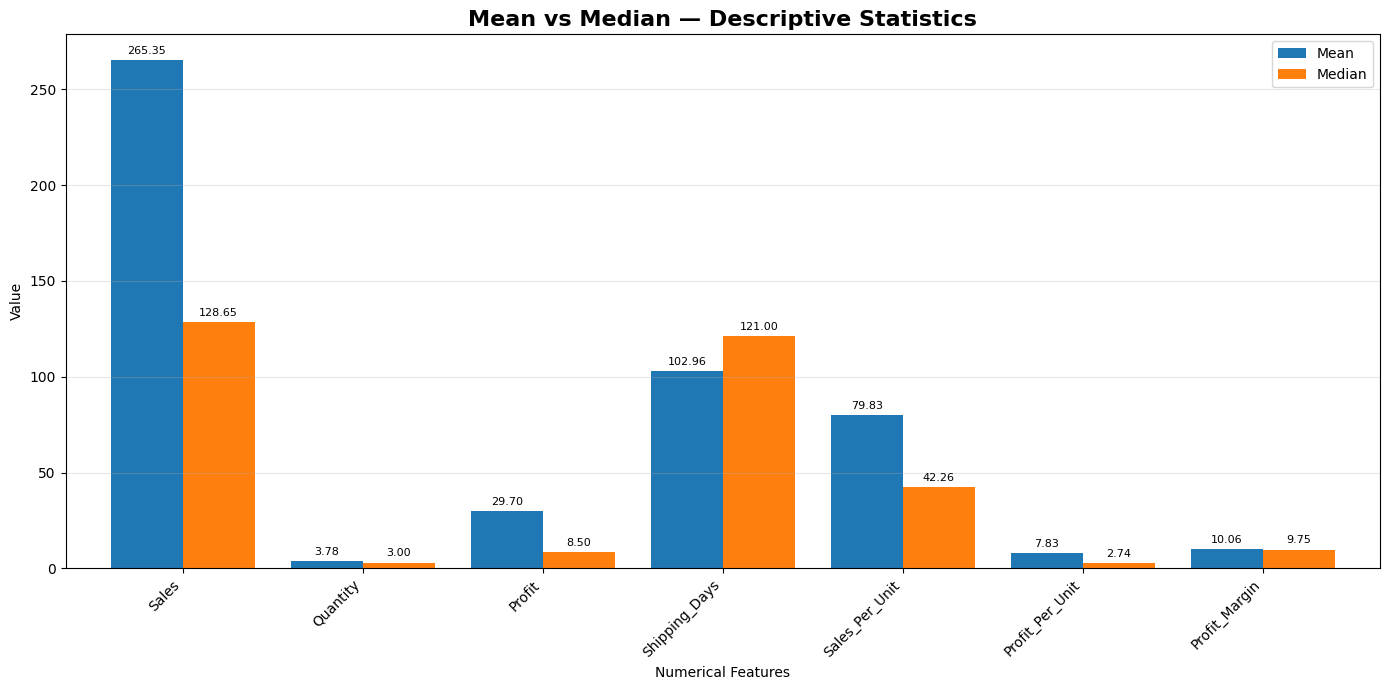

In [101]:
# Mean vs Median comparison
ax = final_descriptive[["Mean", "Median"]].plot(
    kind="bar",
    figsize=(14, 7),
    width=0.8
)

plt.title("Mean vs Median — Descriptive Statistics", fontsize=16, fontweight="bold")
plt.xlabel("Numerical Features")
plt.ylabel("Value")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3,
        fontsize=8
    )

plt.tight_layout()
plt.show()

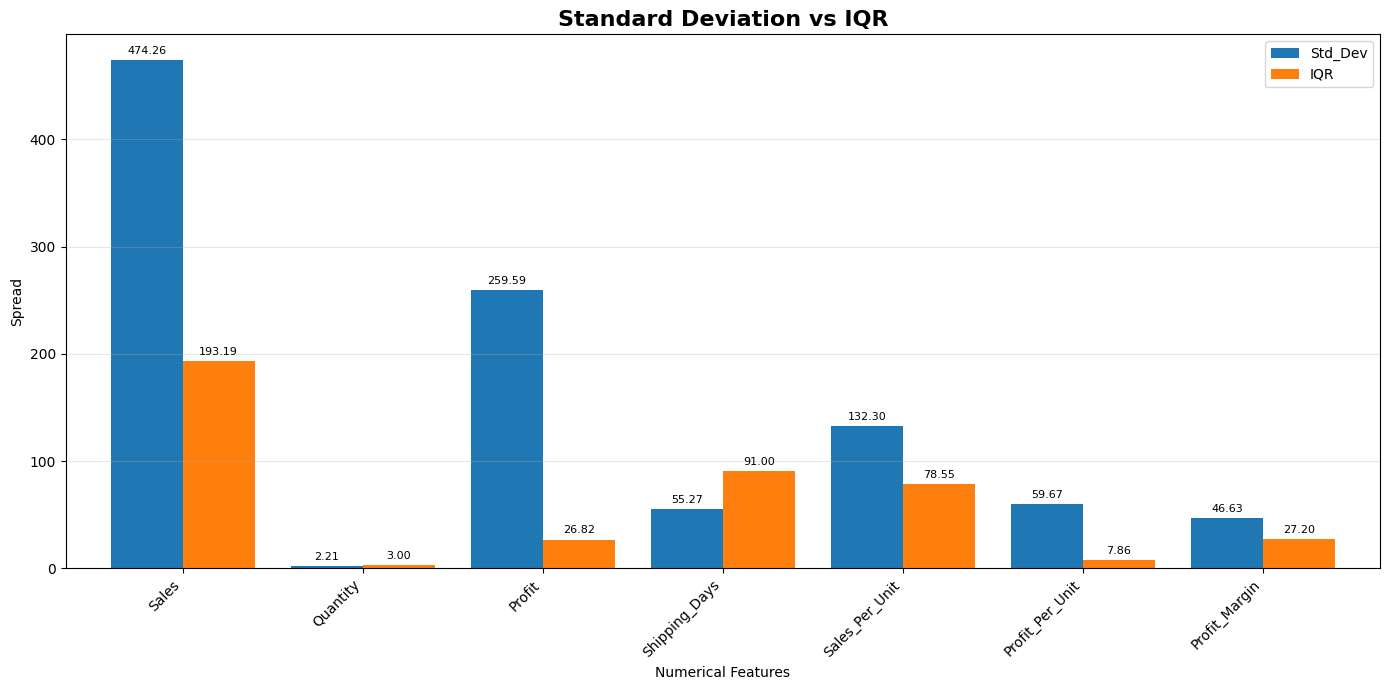

In [102]:
# Standard deviation vs IQR
plot_data = final_descriptive[["Std_Dev", "IQR"]]

ax = plot_data.plot(
    kind="bar",
    figsize=(14, 7),
    width=0.8
)

plt.title("Standard Deviation vs IQR", fontsize=16, fontweight="bold")
plt.xlabel("Numerical Features")
plt.ylabel("Spread")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3,
        fontsize=8
    )

plt.tight_layout()
plt.show()

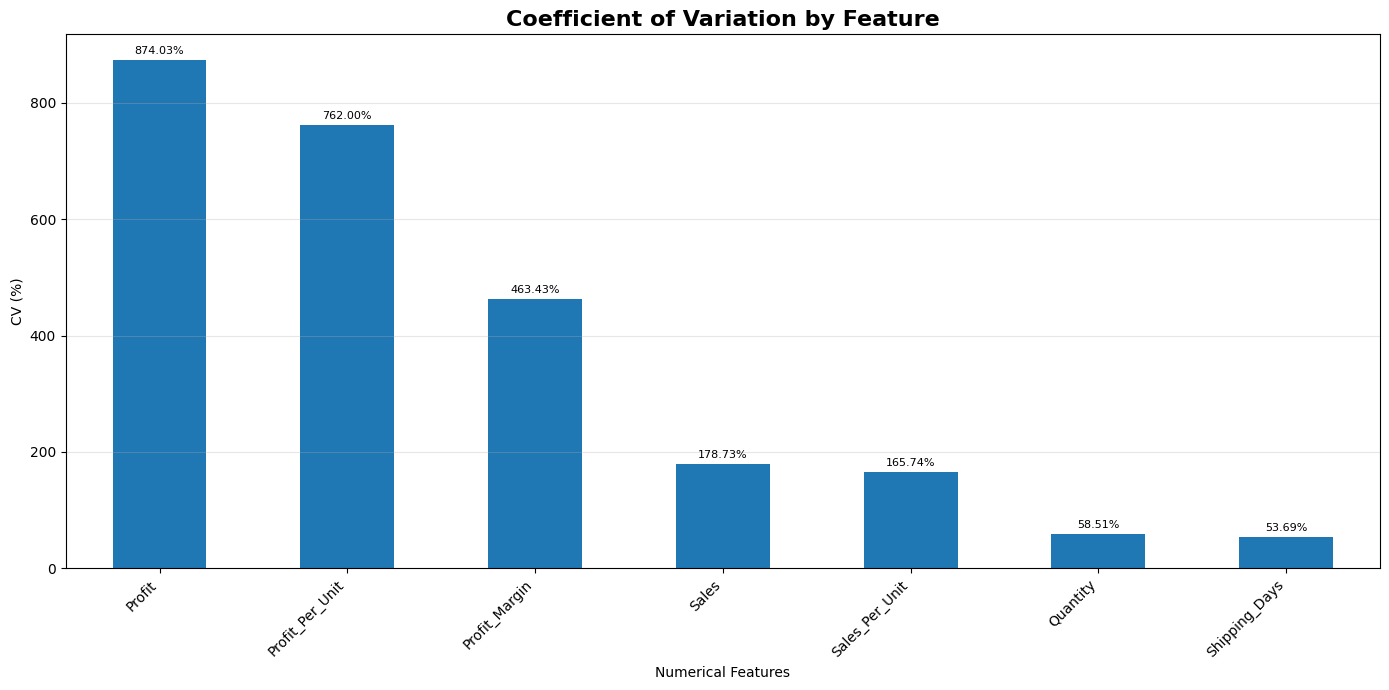

In [103]:
# Relative variability across numerical features
cv_data = final_descriptive["CV_%"].sort_values(ascending=False)

ax = cv_data.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title("Coefficient of Variation by Feature", fontsize=16, fontweight="bold")
plt.xlabel("Numerical Features")
plt.ylabel("CV (%)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=3,
        fontsize=8
    )

plt.tight_layout()
plt.show()

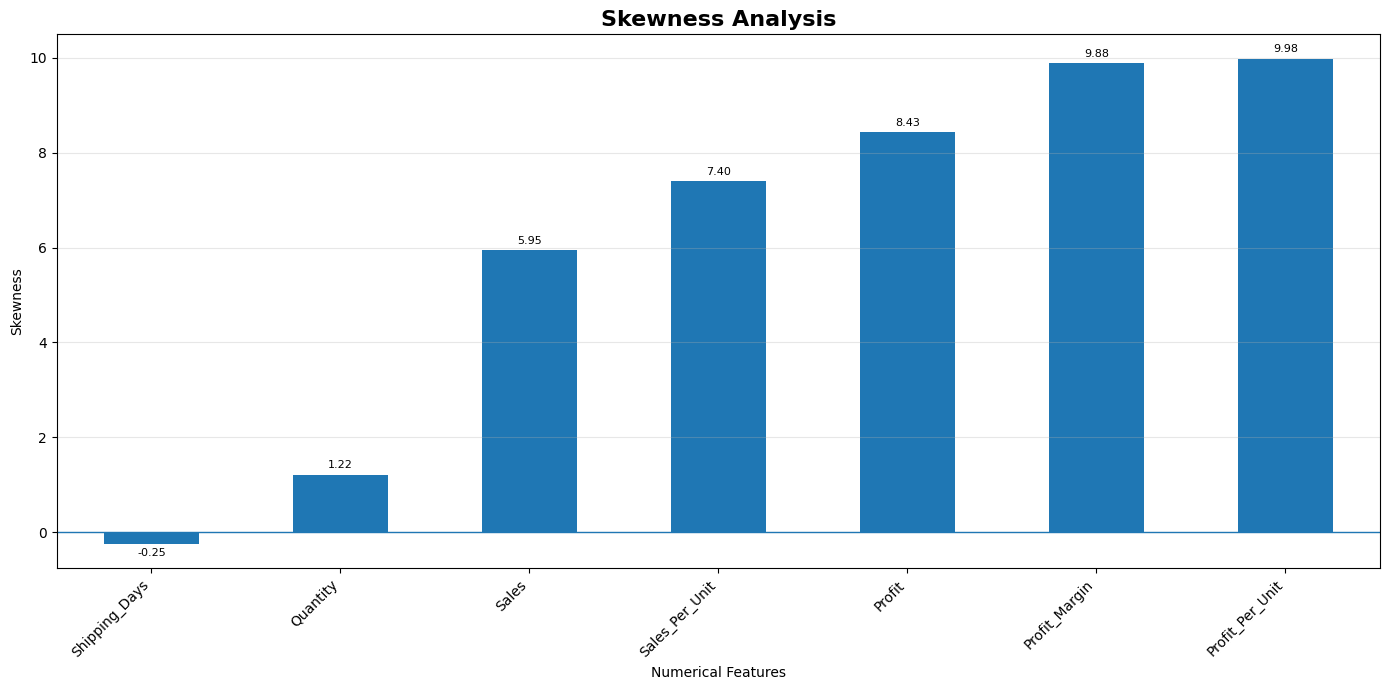

In [104]:
# Distribution asymmetry
skew_data = final_descriptive["Skewness"].sort_values()

ax = skew_data.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.axhline(0, linewidth=1)

plt.title("Skewness Analysis", fontsize=16, fontweight="bold")
plt.xlabel("Numerical Features")
plt.ylabel("Skewness")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3,
        fontsize=8
    )

plt.tight_layout()
plt.show()

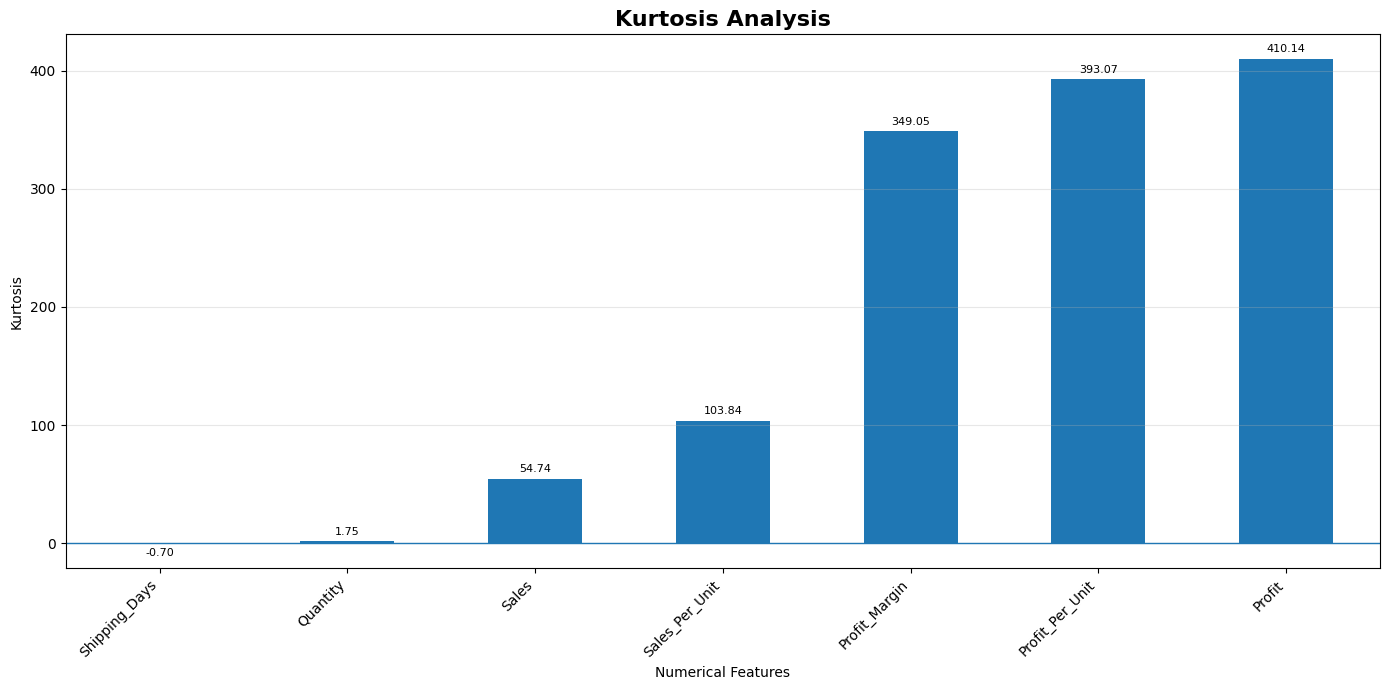

In [105]:
# Tail behaviour of numerical distributions
kurtosis_data = final_descriptive["Kurtosis"].sort_values()

ax = kurtosis_data.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.axhline(0, linewidth=1)

plt.title("Kurtosis Analysis", fontsize=16, fontweight="bold")
plt.xlabel("Numerical Features")
plt.ylabel("Kurtosis")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3,
        fontsize=8
    )

plt.tight_layout()
plt.show()

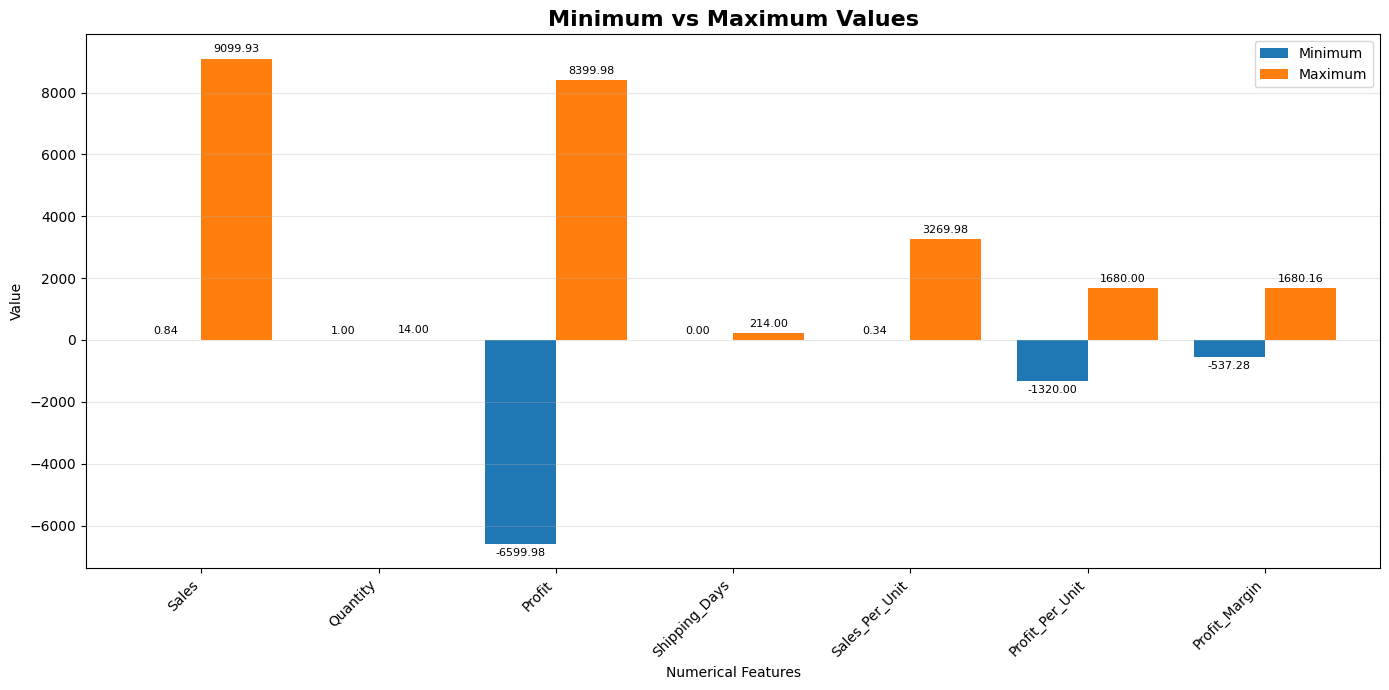

In [106]:
# Minimum and maximum business values
min_max_data = final_descriptive[["Minimum", "Maximum"]]

ax = min_max_data.plot(
    kind="bar",
    figsize=(14, 7),
    width=0.8
)

plt.title("Minimum vs Maximum Values", fontsize=16, fontweight="bold")
plt.xlabel("Numerical Features")
plt.ylabel("Value")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3,
        fontsize=8
    )

plt.tight_layout()
plt.show()

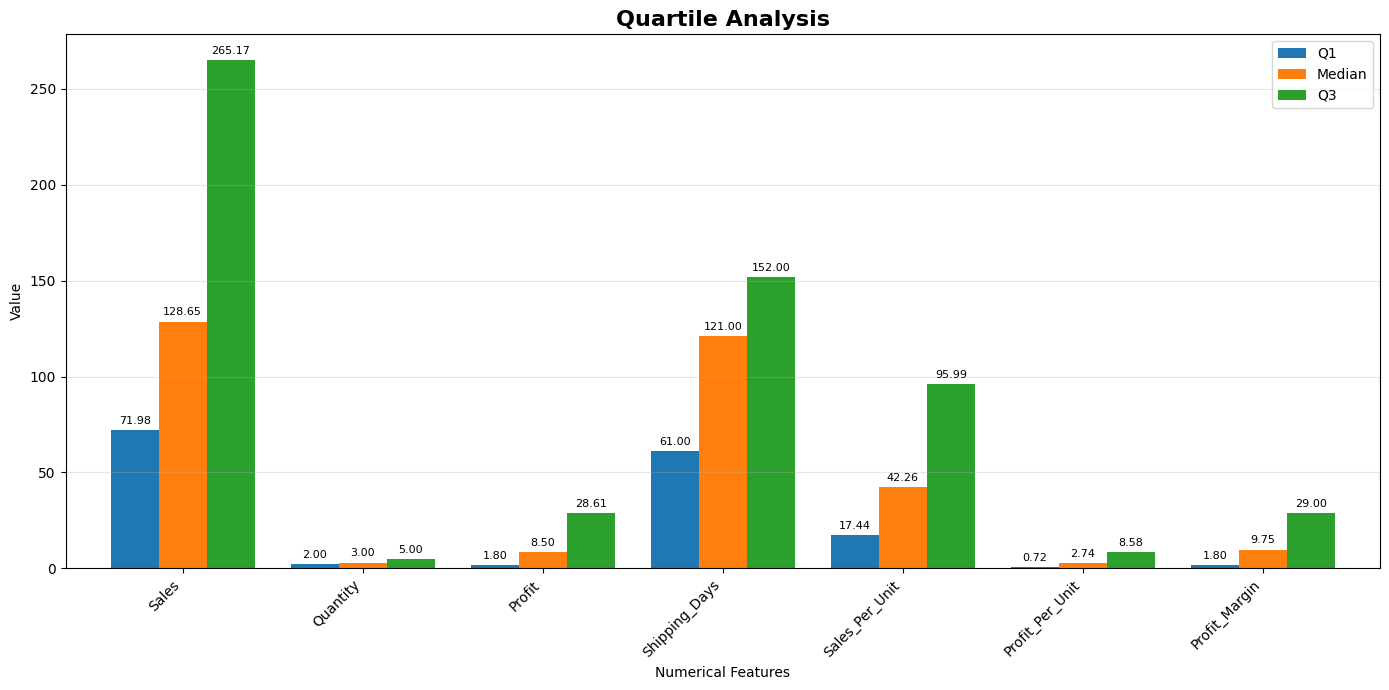

In [107]:
# Compare Q1, Median and Q3
quartile_data = final_descriptive[["Q1", "Median", "Q3"]]

ax = quartile_data.plot(
    kind="bar",
    figsize=(14, 7),
    width=0.8
)

plt.title("Quartile Analysis", fontsize=16, fontweight="bold")
plt.xlabel("Numerical Features")
plt.ylabel("Value")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3,
        fontsize=8
    )

plt.tight_layout()
plt.show()

# 📊 Stage 2 — Distribution & Outlier Statistics

This stage analyzes the shape, spread, and extreme observations
of the core numerical business variables.

## Business Objectives

- Understand how Sales, Profit, and Quantity are distributed.
- Identify skewed business metrics.
- Detect potential extreme observations.
- Measure the percentage of observations affected by outliers.
- Compare different outlier detection methods.

## Core Columns

```text
Sales
Quantity
Profit
Shipping_Days
Sales_Per_Unit
Profit_Per_Unit
Profit_Margin
````

## Analysis Covered

* Distribution Statistics
* Percentiles
* IQR Outlier Detection
* Z-Score
* Outlier Percentage
* Lower and Upper Bounds
* Normality Assessment

In [108]:

## 1. Distribution Summary

# Create a distribution summary for the core numerical columns
distribution_summary = pd.DataFrame({
    "Mean": desc_df.mean(),
    "Median": desc_df.median(),
    "Std_Dev": desc_df.std(),
    "Skewness": desc_df.skew(),
    "Kurtosis": desc_df.kurtosis()
})

display(distribution_summary.round(3))
display(distribution_summary.describe().T)

,Mean,Median,Std_Dev,Skewness,Kurtosis
Sales,265.346,128.648,474.261,5.949,54.745
Quantity,3.782,3.000,2.213,1.217,1.755
Profit,29.700,8.502,259.589,8.434,410.138
Shipping_Days,102.955,121.000,55.272,-0.249,-0.698
Sales_Per_Unit,79.828,42.259,132.304,7.398,103.838
Profit_Per_Unit,7.831,2.745,59.672,9.983,393.072
Profit_Margin,10.061,9.747,46.626,9.884,349.051


,count,mean,std,min,25%,50%,75%,max
Mean,7.0,71.357600,93.804948,3.781901,8.946000,29.700408,91.391652,265.345589
Median,7.0,45.128642,56.131934,2.744800,5.751250,9.746524,81.629333,128.648000
Std_Dev,7.0,147.133864,166.868235,2.212917,50.949043,59.672462,195.946468,474.260645
Skewness,7.0,6.088035,4.096970,-0.249169,3.582958,7.398263,9.159085,9.983067
Kurtosis,7.0,187.414182,188.179531,-0.698369,28.249732,103.837843,371.061201,410.137936


In [109]:
# Calculate detailed percentiles for distribution analysis
percentiles = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]

percentile_analysis = (
    desc_df.quantile(percentiles)
    .T
)

percentile_analysis.columns = [
    "P01", "P05", "P10", "P25",
    "P50", "P75", "P90", "P95", "P99"
]

display(percentile_analysis)
display(percentile_analysis.describe().T)

,P01,P05,P10,P25,P50,P75,P90,P95,P99
Sales,3.2820,9.2480,15.9920,71.976000,128.648000,265.170,577.91600,956.6648,2396.4000
Quantity,1.0000,1.0000,2.0000,2.000000,3.000000,5.000,7.00000,8.0000,10.0000
Profit,-299.8116,-51.8272,-15.5826,1.795500,8.502500,28.615,87.89000,168.4384,592.7896
Shipping_Days,0.0000,0.0000,29.4000,61.000000,121.000000,152.000,181.00000,183.0000,214.0000
Sales_Per_Unit,1.4560,3.1600,5.1840,17.436571,42.258667,95.990,180.24000,275.3700,559.9920
Profit_Per_Unit,-80.9375,-15.4666,-4.7182,0.722800,2.744800,8.579,25.24500,44.9985,137.2455
Profit_Margin,-155.0000,-45.0000,-16.2500,1.802112,9.746524,29.000,42.88709,47.0000,50.0000


,count,mean,std,min,25%,50%,75%,max
P01,7.0,-75.715871,115.719858,-299.8116,-117.968750,0.000000,1.228000,3.2820
P05,7.0,-14.126543,24.663978,-51.8272,-30.233300,0.000000,2.080000,9.2480
P10,7.0,2.289314,16.550088,-16.2500,-10.150400,2.000000,10.588000,29.4000
P25,7.0,22.390426,30.841677,0.7228,1.798806,2.000000,39.218286,71.9760
P50,7.0,45.128642,56.131934,2.7448,5.751250,9.746524,81.629333,128.6480
P75,7.0,83.479143,96.272405,5.0000,18.597000,29.000000,123.995000,265.1700
P90,7.0,157.454013,198.302068,7.0000,34.066045,87.890000,180.620000,577.9160
P95,7.0,240.495957,329.728777,8.0000,45.999250,168.438400,229.185000,956.6648
P99,7.0,565.775300,840.063887,10.0000,93.622750,214.000000,576.390800,2396.4000


In [110]:
# Calculate IQR-based outlier boundaries
outlier_summary = pd.DataFrame({
    "Q1": desc_df.quantile(0.25),
    "Q3": desc_df.quantile(0.75)
})

outlier_summary["IQR"] = (
    outlier_summary["Q3"]
    - outlier_summary["Q1"]
)

outlier_summary["Lower_Bound"] = (
    outlier_summary["Q1"]
    - 1.5 * outlier_summary["IQR"]
)

outlier_summary["Upper_Bound"] = (
    outlier_summary["Q3"]
    + 1.5 * outlier_summary["IQR"]
)

display(outlier_summary.round(3))
display(outlier_summary.describe().T)

,Q1,Q3,IQR,Lower_Bound,Upper_Bound
Sales,71.976,265.170,193.194,-217.815,554.961
Quantity,2.000,5.000,3.000,-2.500,9.500
Profit,1.796,28.615,26.819,-38.434,68.844
Shipping_Days,61.000,152.000,91.000,-75.500,288.500
Sales_Per_Unit,17.437,95.990,78.553,-100.394,213.820
Profit_Per_Unit,0.723,8.579,7.856,-11.061,20.363
Profit_Margin,1.802,29.000,27.198,-38.995,69.797


,count,mean,std,min,25%,50%,75%,max
Q1,7.0,22.390426,30.841677,0.7228,1.798806,2.000000,39.218286,71.976
Q3,7.0,83.479143,96.272405,5.0000,18.597000,29.000000,123.995000,265.170
IQR,7.0,61.088717,67.308338,3.0000,17.337850,27.197888,84.776714,193.194
Lower_Bound,7.0,-69.242649,73.922291,-217.8150,-87.946786,-38.994720,-24.747625,-2.500
Upper_Bound,7.0,175.112218,196.807451,9.5000,44.603775,69.796832,251.160071,554.961


In [111]:
# Count observations outside the IQR boundaries
outlier_counts = {}

for column in desc_df.columns:
    q1 = desc_df[column].quantile(0.25)
    q3 = desc_df[column].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outlier_counts[column] = (
        (desc_df[column] < lower) |
        (desc_df[column] > upper)
    ).sum()

outlier_counts = pd.Series(outlier_counts)

display(
    outlier_counts
    .to_frame("Outlier_Count")
)

display(outlier_counts.describe())

,Outlier_Count
Sales,631
Quantity,87
Profit,1122
Shipping_Days,0
Sales_Per_Unit,466
Profit_Per_Unit,1115
Profit_Margin,340


count       7.000000
mean      537.285714
std       450.899735
min         0.000000
25%       213.500000
50%       466.000000
75%       873.000000
max      1122.000000
dtype: float64

In [112]:
# Calculate the percentage of observations identified as outliers
outlier_percentage = (
    outlier_counts
    / desc_df.notna().sum()
    * 100
)

display(
    outlier_percentage
    .to_frame("Outlier_Percentage_%")
)

display(outlier_percentage.describe())

,Outlier_Percentage_%
Sales,10.693103
Quantity,1.474326
Profit,19.013726
Shipping_Days,0.000000
Sales_Per_Unit,7.896967
Profit_Per_Unit,18.895103
Profit_Margin,5.761735


count     7.000000
mean      9.104994
std       7.641073
min       0.000000
25%       3.618031
50%       7.896967
75%      14.794103
max      19.013726
dtype: float64

In [113]:
# Calculate absolute Z-scores for numerical observations
zscore_summary = {}

for column in desc_df.columns:
    mean = desc_df[column].mean()
    std = desc_df[column].std()

    z_scores = (
        (desc_df[column] - mean) / std
    )

    zscore_summary[column] = (
        z_scores.abs() > 3
    ).sum()

zscore_summary = pd.Series(zscore_summary)

display(
    zscore_summary
    .to_frame("ZScore_Outlier_Count")
)

display(zscore_summary.describe())

,ZScore_Outlier_Count
Sales,106
Quantity,58
Profit,53
Shipping_Days,0
Sales_Per_Unit,93
Profit_Per_Unit,49
Profit_Margin,103


count      7.000000
mean      66.000000
std       37.806525
min        0.000000
25%       51.000000
50%       58.000000
75%       98.000000
max      106.000000
dtype: float64

In [114]:
# Compare two common statistical outlier detection methods
outlier_comparison = pd.DataFrame({
    "IQR_Outliers": outlier_counts,
    "ZScore_Outliers": zscore_summary
})

outlier_comparison["IQR_Outlier_%"] = (
    outlier_comparison["IQR_Outliers"]
    / desc_df.notna().sum()
    * 100
)

outlier_comparison["ZScore_Outlier_%"] = (
    outlier_comparison["ZScore_Outliers"]
    / desc_df.notna().sum()
    * 100
)

display(outlier_comparison.round(3))
display(outlier_comparison.describe().T)

,IQR_Outliers,ZScore_Outliers,IQR_Outlier_%,ZScore_Outlier_%
Sales,631,106,10.693,1.796
Quantity,87,58,1.474,0.983
Profit,1122,53,19.014,0.898
Shipping_Days,0,0,0.000,0.000
Sales_Per_Unit,466,93,7.897,1.576
Profit_Per_Unit,1115,49,18.895,0.830
Profit_Margin,340,103,5.762,1.745


,count,mean,std,min,25%,50%,75%,max
IQR_Outliers,7.0,537.285714,450.899735,0.0,213.500000,466.000000,873.000000,1122.000000
ZScore_Outliers,7.0,66.000000,37.806525,0.0,51.000000,58.000000,98.000000,106.000000
IQR_Outlier_%,7.0,9.104994,7.641073,0.0,3.618031,7.896967,14.794103,19.013726
ZScore_Outlier_%,7.0,1.118454,0.640680,0.0,0.864260,0.982884,1.660735,1.796306


In [115]:
# Identify observations with extreme Sales and Profit values
extreme_values = df[
    df["Sales"].isin(df["Sales"].nlargest(10))
    |
    df["Profit"].isin(df["Profit"].nlargest(10))
]

display(
    extreme_values[
        [
            "Order_ID",
            "Customer_Name",
            "Category",
            "Product_Name",
            "Sales",
            "Profit",
            "Quantity"
        ]
    ]
)

,Order_ID,Customer_Name,Category,Product_Name,Sales,Profit,Quantity
93,CA-2019-158841,Sanjit Engle,Technology,HP Designjet T520 Inkjet Large Format Printer ...,4749.950,2799.9840,5
176,US-2019-143819,Karen Daniels,Technology,Ativa V4110MDD Micro-Cut Shredder,4899.930,2400.9657,7
254,CA-2019-136301,Edward Hooks,Office Supplies,High Speed Automatic Electric Letter Opener,4912.590,196.5036,3
430,US-2019-107440,Bill Shonely,Technology,"3D Systems Cube Printer, 2nd Generation, Magenta",9099.930,2365.9818,7
1681,CA-2019-118689,Tamara Chand,Technology,Canon imageCLASS 2200 Advanced Copier,499.950,8399.9760,5
1694,US-2019-140158,Daniel Raglin,Technology,Hewlett Packard LaserJet 3310 Copier,5399.910,2591.9568,9
2447,CA-2019-117121,Adrian Barton,Office Supplies,GBC Ibimaster 500 Manual ProClick Binding System,2892.740,4946.3700,13
2654,CA-2020-138289,Andy Reiter,Office Supplies,GBC DocuBind P400 Electric Binding System,5455.960,2504.2216,4
3011,CA-2020-140151,Raymond Buch,Technology,Canon imageCLASS 2200 Advanced Copier,3445.960,6719.9808,4
3093,CA-2020-149881,Nick Crebassa,Technology,Cubify CubeX 3D Printer Double Head Print,4823.984,359.9988,2


In [116]:
# Analyze transactions where Profit is negative
loss_analysis = df.loc[
    df["Profit"] < 0,
    ["Sales", "Quantity", "Profit", "Profit_Margin"]
]

display(loss_analysis.head(10))
display(loss_analysis.describe().T)

,Sales,Quantity,Profit,Profit_Margin
4,30.080,2,-5.2640,-17.500000
5,165.600,3,-6.2100,-3.750000
11,104.580,6,-80.1780,-76.666667
16,23.076,3,-10.9611,-47.500000
20,30.828,7,-24.6624,-80.000000
31,15.588,2,-9.8724,-63.333333
38,181.797,1,-15.5826,-8.571429
49,153.568,2,-5.7588,-3.750000
53,451.136,4,-67.6704,-15.000000
59,110.376,4,-20.2356,-18.333333


,count,mean,std,min,25%,50%,75%,max
Sales,1098.0,271.777127,420.579106,0.836000,86.138500,135.948000,318.163500,4692.736000
Quantity,1098.0,3.729508,2.121785,1.000000,2.000000,3.000000,5.000000,14.000000
Profit,1098.0,-83.524342,310.144323,-6599.978000,-56.310800,-18.349450,-6.396000,-0.209800
Profit_Margin,1098.0,-38.223673,52.013016,-537.284079,-50.045006,-17.995029,-6.340303,-0.020326


In [117]:
# Combine the main outlier statistics into one final table
final_outlier_summary = pd.DataFrame({
    "Q1": desc_df.quantile(0.25),
    "Median": desc_df.quantile(0.50),
    "Q3": desc_df.quantile(0.75),
    "IQR": desc_df.quantile(0.75) - desc_df.quantile(0.25),
    "IQR_Outliers": outlier_counts,
    "IQR_Outlier_%": (
        outlier_counts /
        desc_df.notna().sum() *
        100
    ),
    "ZScore_Outliers": zscore_summary
})

display(final_outlier_summary.round(3))
display(final_outlier_summary.describe().T)

,Q1,Median,Q3,IQR,IQR_Outliers,IQR_Outlier_%,ZScore_Outliers
Sales,71.976,128.648,265.170,193.194,631,10.693,106
Quantity,2.000,3.000,5.000,3.000,87,1.474,58
Profit,1.796,8.502,28.615,26.819,1122,19.014,53
Shipping_Days,61.000,121.000,152.000,91.000,0,0.000,0
Sales_Per_Unit,17.437,42.259,95.990,78.553,466,7.897,93
Profit_Per_Unit,0.723,2.745,8.579,7.856,1115,18.895,49
Profit_Margin,1.802,9.747,29.000,27.198,340,5.762,103


,count,mean,std,min,25%,50%,75%,max
Q1,7.0,22.390426,30.841677,0.7228,1.798806,2.000000,39.218286,71.976000
Median,7.0,45.128642,56.131934,2.7448,5.751250,9.746524,81.629333,128.648000
Q3,7.0,83.479143,96.272405,5.0000,18.597000,29.000000,123.995000,265.170000
IQR,7.0,61.088717,67.308338,3.0000,17.337850,27.197888,84.776714,193.194000
IQR_Outliers,7.0,537.285714,450.899735,0.0000,213.500000,466.000000,873.000000,1122.000000
IQR_Outlier_%,7.0,9.104994,7.641073,0.0000,3.618031,7.896967,14.794103,19.013726
ZScore_Outliers,7.0,66.000000,37.806525,0.0000,51.000000,58.000000,98.000000,106.000000


# 📊 Stage 3 — Normality Analysis

Normality analysis determines whether the numerical business
variables approximately follow a normal distribution.

## Business Objectives

- Check the distributional shape of important metrics.
- Identify variables that significantly deviate from normality.
- Compare visual and statistical normality evidence.
- Select appropriate parametric or non-parametric tests for
  later inferential analysis.

## Core Variables

```text
Sales
Quantity
Profit
Shipping_Days
Sales_Per_Unit
Profit_Per_Unit
Profit_Margin
````

## Methods

### Visual Analysis

* Histogram
* Q-Q Plot

### Statistical Tests

* Shapiro-Wilk Test
* D'Agostino K² Test
* Anderson-Darling Test

## Hypotheses

### H₀

The data follows a normal distribution.

### H₁

The data does not follow a normal distribution.

## Decision Rule

```text
p-value < 0.05
→ Reject H₀
→ Evidence of non-normality

p-value >= 0.05
→ Fail to Reject H₀
→ Insufficient evidence against normality
```

Statistical tests will be interpreted together with visual
diagnostics because large datasets can make normality tests
extremely sensitive to small deviations.

### 📌 Stage 3 Covered

```text
Histogram
Q-Q Plot
Shapiro-Wilk
D'Agostino K²
Anderson-Darling
P-Values
Critical Values
H₀ / H₁
Decision Rules
Combined Normality Assessment
```

In [118]:
## 1. Import Statistical Libraries

# Statistical testing and visualization libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats

In [119]:
# Select the core numerical variables
normality_cols = [
    "Sales",
    "Quantity",
    "Profit",
    "Shipping_Days",
    "Sales_Per_Unit",
    "Profit_Per_Unit",
    "Profit_Margin"
]

normality_df = df[normality_cols].copy()

display(normality_df.head())
display(normality_df.describe().T)

,Sales,Quantity,Profit,Shipping_Days,Sales_Per_Unit,Profit_Per_Unit,Profit_Margin
0,73.94,1,28.2668,181.0,73.94,28.2668,38.229375
1,173.94,3,38.2668,150.0,57.98,12.7556,22.000000
2,231.98,2,67.2742,150.0,115.99,33.6371,29.000000
3,114.46,2,28.6150,61.0,57.23,14.3075,25.000000
4,30.08,2,-5.2640,153.0,15.04,-2.6320,-17.500000


,count,mean,std,min,25%,50%,75%,max
Sales,5901.0,265.345589,474.260645,0.836000,71.976000,128.648000,265.170,9099.930000
Quantity,5901.0,3.781901,2.212917,1.000000,2.000000,3.000000,5.000,14.000000
Profit,5901.0,29.700408,259.589138,-6599.978000,1.795500,8.502500,28.615,8399.976000
Shipping_Days,1685.0,102.955490,55.272160,0.000000,61.000000,121.000000,152.000,214.000000
Sales_Per_Unit,5901.0,79.827814,132.303798,0.336000,17.436571,42.258667,95.990,3269.984000
Profit_Per_Unit,5901.0,7.831002,59.672462,-1319.995600,0.722800,2.744800,8.579,1679.995200
Profit_Margin,5901.0,10.060998,46.625926,-537.284079,1.802112,9.746524,29.000,1680.163216


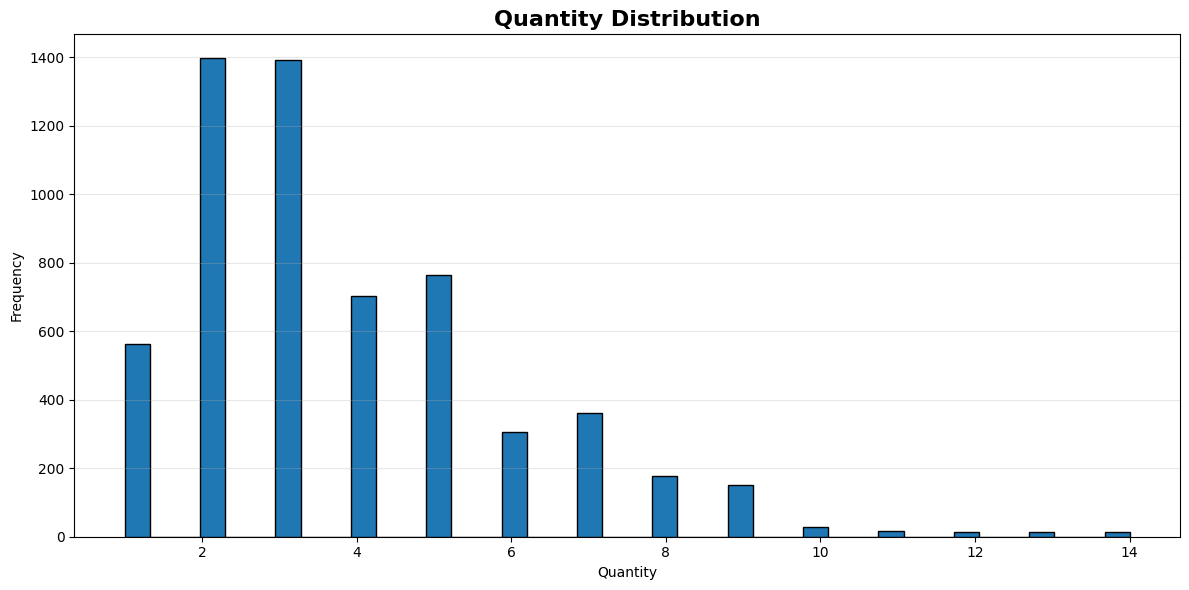

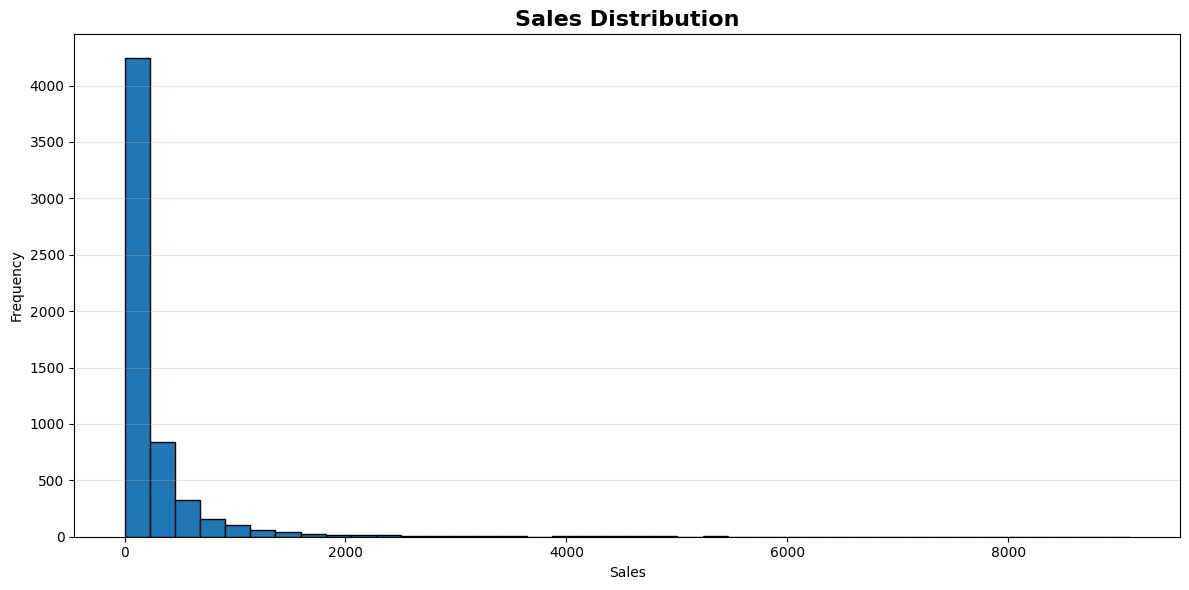

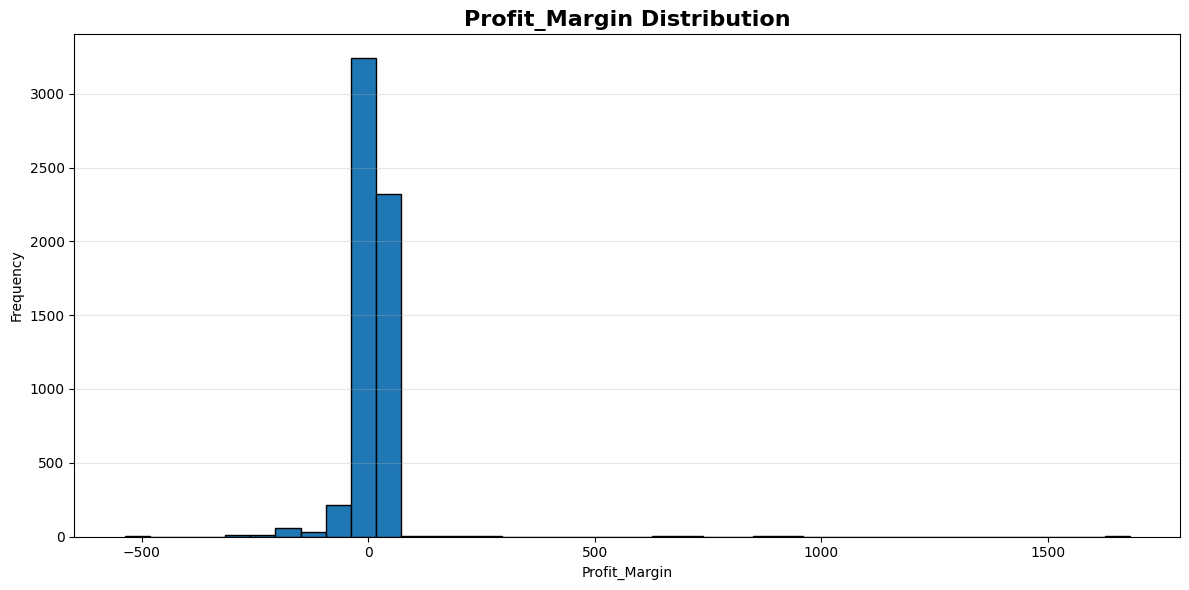

In [120]:
# Analyze the distribution of one selected business metric
column = "Quantity"

data = normality_df[column].dropna()

plt.figure(figsize=(12, 6))

plt.hist(
    data,
    bins=40,
    edgecolor="black"
)

plt.title(
    f"{column} Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(column)
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Analyze the distribution of one selected business metric
column = "Sales"

data = normality_df[column].dropna()

plt.figure(figsize=(12, 6))

plt.hist(
    data,
    bins=40,
    edgecolor="black"
)

plt.title(
    f"{column} Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(column)
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Analyze the distribution of one selected business metric
column = "Profit_Margin"

data = normality_df[column].dropna()

plt.figure(figsize=(12, 6))

plt.hist(
    data,
    bins=40,
    edgecolor="black"
)

plt.title(
    f"{column} Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(column)
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

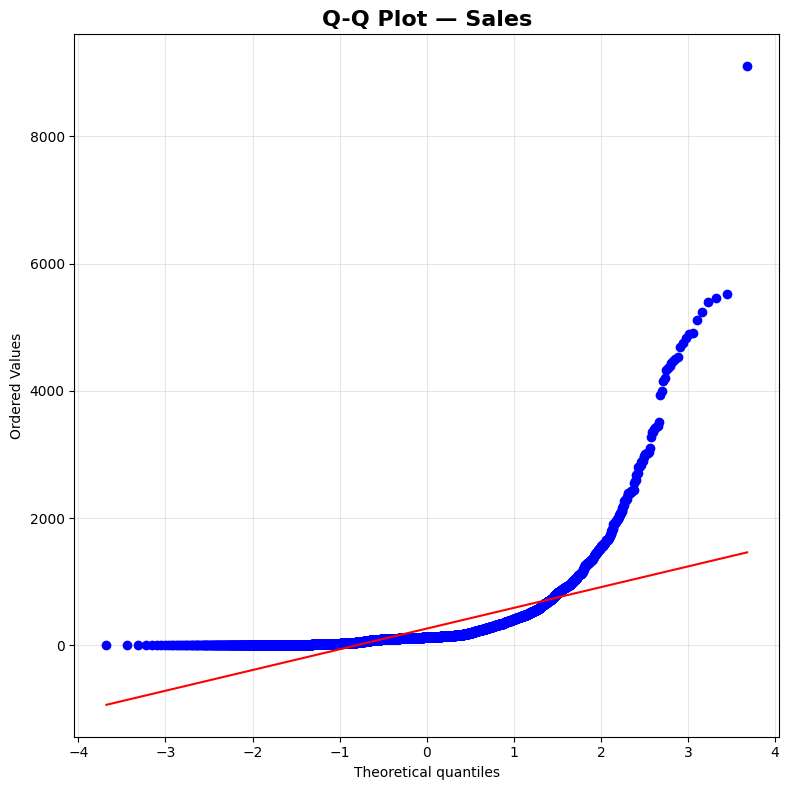

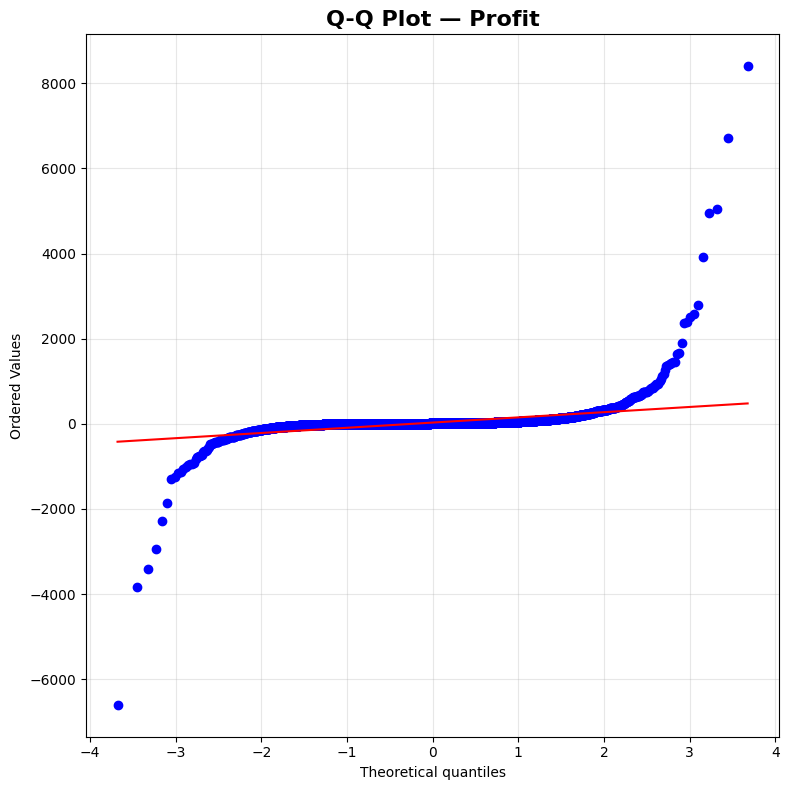

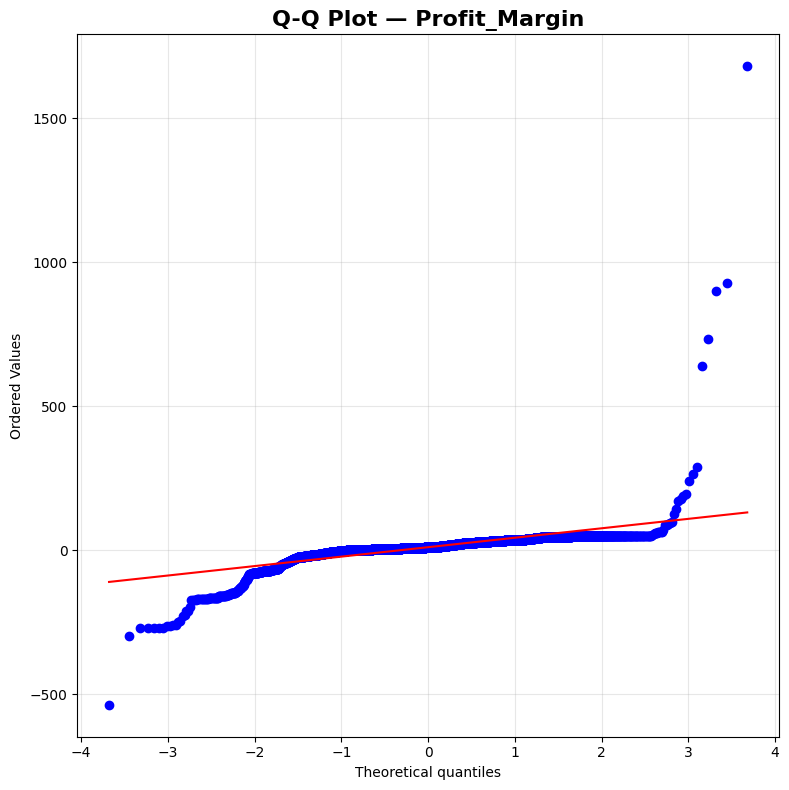

In [121]:
# Compare observed quantiles with theoretical normal quantiles
column = "Sales"

data = normality_df[column].dropna()

plt.figure(figsize=(8, 8))

stats.probplot(
    data,
    dist="norm",
    plot=plt
)

plt.title(
    f"Q-Q Plot — {column}",
    fontsize=16,
    fontweight="bold"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Compare observed quantiles with theoretical normal quantiles
column = "Profit"

data = normality_df[column].dropna()

plt.figure(figsize=(8, 8))

stats.probplot(
    data,
    dist="norm",
    plot=plt
)

plt.title(
    f"Q-Q Plot — {column}",
    fontsize=16,
    fontweight="bold"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Compare observed quantiles with theoretical normal quantiles
column = "Profit_Margin"

data = normality_df[column].dropna()

plt.figure(figsize=(8, 8))

stats.probplot(
    data,
    dist="norm",
    plot=plt
)

plt.title(
    f"Q-Q Plot — {column}",
    fontsize=16,
    fontweight="bold"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [122]:
# Apply Shapiro-Wilk normality test
shapiro_results = []

for column in normality_df.columns:

    data = normality_df[column].dropna()

    sample = data

    if len(sample) > 5000:
        sample = sample.sample(
            5000,
            random_state=42
        )

    statistic, p_value = stats.shapiro(sample)

    shapiro_results.append({
        "Variable": column,
        "Statistic": statistic,
        "P_Value": p_value
    })

shapiro_results = pd.DataFrame(shapiro_results)

display(shapiro_results)
display(shapiro_results.describe().T)

,Variable,Statistic,P_Value
0,Sales,0.470591,2.171310e-81
1,Quantity,0.890529,9.583560e-51
2,Profit,0.218464,4.192543e-90
3,Shipping_Days,0.947068,3.785414e-24
4,Sales_Per_Unit,0.497823,3.043621e-80
5,Profit_Per_Unit,0.264283,1.008770e-88
6,Profit_Margin,0.476402,3.776158e-81


,count,mean,std,min,25%,50%,75%,max
Statistic,7.0,5.378801e-01,2.824270e-01,2.184644e-01,3.674369e-01,4.764016e-01,6.941763e-01,9.470680e-01
P_Value,7.0,5.407734e-25,1.430752e-24,4.192543e-90,1.085655e-81,3.776158e-81,4.791780e-51,3.785414e-24


In [123]:
# Interpret Shapiro-Wilk results
shapiro_results["Decision"] = np.where(
    shapiro_results["P_Value"] < 0.05,
    "Reject H0 - Non-Normal",
    "Fail to Reject H0 - No Strong Evidence"
)

display(shapiro_results)

,Variable,Statistic,P_Value,Decision
0,Sales,0.470591,2.171310e-81,Reject H0 - Non-Normal
1,Quantity,0.890529,9.583560e-51,Reject H0 - Non-Normal
2,Profit,0.218464,4.192543e-90,Reject H0 - Non-Normal
3,Shipping_Days,0.947068,3.785414e-24,Reject H0 - Non-Normal
4,Sales_Per_Unit,0.497823,3.043621e-80,Reject H0 - Non-Normal
5,Profit_Per_Unit,0.264283,1.008770e-88,Reject H0 - Non-Normal
6,Profit_Margin,0.476402,3.776158e-81,Reject H0 - Non-Normal


In [124]:
# Apply D'Agostino K-squared normality test
dagostino_results = []

for column in normality_df.columns:

    data = normality_df[column].dropna()

    statistic, p_value = stats.normaltest(data)

    dagostino_results.append({
        "Variable": column,
        "Statistic": statistic,
        "P_Value": p_value
    })

dagostino_results = pd.DataFrame(dagostino_results)

display(dagostino_results)
display(dagostino_results.describe().T)

,Variable,Statistic,P_Value
0,Sales,6767.507402,0.000000e+00
1,Quantity,1167.872913,2.509685e-254
2,Profit,8944.752201,0.000000e+00
3,Shipping_Days,103.793438,2.894286e-23
4,Sales_Per_Unit,7884.965177,0.000000e+00
5,Profit_Per_Unit,9620.414354,0.000000e+00
6,Profit_Margin,9537.940180,0.000000e+00


,count,mean,std,min,25%,50%,75%,max
Statistic,7.0,6.289607e+03,3.999286e+03,103.793438,3967.690158,7884.965177,9.241346e+03,9.620414e+03
P_Value,7.0,4.134694e-24,1.093937e-23,0.000000,0.000000,0.000000,1.254842e-254,2.894286e-23


In [125]:
# Interpret D'Agostino K-squared results
dagostino_results["Decision"] = np.where(
    dagostino_results["P_Value"] < 0.05,
    "Reject H0 - Non-Normal",
    "Fail to Reject H0 - No Strong Evidence"
)

display(dagostino_results)

,Variable,Statistic,P_Value,Decision
0,Sales,6767.507402,0.000000e+00,Reject H0 - Non-Normal
1,Quantity,1167.872913,2.509685e-254,Reject H0 - Non-Normal
2,Profit,8944.752201,0.000000e+00,Reject H0 - Non-Normal
3,Shipping_Days,103.793438,2.894286e-23,Reject H0 - Non-Normal
4,Sales_Per_Unit,7884.965177,0.000000e+00,Reject H0 - Non-Normal
5,Profit_Per_Unit,9620.414354,0.000000e+00,Reject H0 - Non-Normal
6,Profit_Margin,9537.940180,0.000000e+00,Reject H0 - Non-Normal


In [126]:
# Apply Anderson-Darling normality test
anderson_results = []

for column in normality_df.columns:

    data = normality_df[column].dropna()

    result = stats.anderson(
        data,
        dist="norm"
    )

    critical_5 = result.critical_values[
        np.where(result.significance_level == 5)[0][0]
    ]

    decision = (
        "Reject H0 - Non-Normal"
        if result.statistic > critical_5
        else
        "Fail to Reject H0 - No Strong Evidence"
    )

    anderson_results.append({
        "Variable": column,
        "Statistic": result.statistic,
        "Critical_Value_5%": critical_5,
        "Decision": decision
    })

anderson_results = pd.DataFrame(anderson_results)

display(anderson_results)
display(anderson_results.describe().T)

C:\Users\Admin\AppData\Local\Temp\ipykernel_7964\2121954569.py:8: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  result = stats.anderson(


,Variable,Statistic,Critical_Value_5%,Decision
0,Sales,870.456199,0.752,Reject H0 - Non-Normal
1,Quantity,200.740407,0.752,Reject H0 - Non-Normal
2,Profit,1351.584001,0.752,Reject H0 - Non-Normal
3,Shipping_Days,32.845889,0.752,Reject H0 - Non-Normal
4,Sales_Per_Unit,691.489347,0.752,Reject H0 - Non-Normal
5,Profit_Per_Unit,1231.705061,0.752,Reject H0 - Non-Normal
6,Profit_Margin,536.301092,0.752,Reject H0 - Non-Normal


,count,mean,std,min,25%,50%,75%,max
Statistic,7.0,702.160285,4.928690e+02,32.845889,368.520749,691.489347,1051.08063,1351.584001
Critical_Value_5%,7.0,0.752000,1.199178e-16,0.752000,0.752000,0.752000,0.75200,0.752000


In [127]:
# Combine the results from all normality tests
normality_summary = (
    shapiro_results[
        ["Variable", "Statistic", "P_Value"]
    ]
    .rename(columns={
        "Statistic": "Shapiro_Statistic",
        "P_Value": "Shapiro_P_Value"
    })
)

normality_summary = normality_summary.merge(
    dagostino_results[
        ["Variable", "Statistic", "P_Value"]
    ].rename(columns={
        "Statistic": "Dagostino_Statistic",
        "P_Value": "Dagostino_P_Value"
    }),
    on="Variable"
)

normality_summary = normality_summary.merge(
    anderson_results[
        ["Variable", "Statistic", "Critical_Value_5%", "Decision"]
    ].rename(columns={
        "Statistic": "Anderson_Statistic",
        "Decision": "Anderson_Decision"
    }),
    on="Variable"
)

display(normality_summary.round(5))
display(normality_summary.describe().T)

,Variable,Shapiro_Statistic,Shapiro_P_Value,Dagostino_Statistic,Dagostino_P_Value,Anderson_Statistic,Critical_Value_5%,Anderson_Decision
0,Sales,0.47059,0.0,6767.50740,0.0,870.45620,0.752,Reject H0 - Non-Normal
1,Quantity,0.89053,0.0,1167.87291,0.0,200.74041,0.752,Reject H0 - Non-Normal
2,Profit,0.21846,0.0,8944.75220,0.0,1351.58400,0.752,Reject H0 - Non-Normal
3,Shipping_Days,0.94707,0.0,103.79344,0.0,32.84589,0.752,Reject H0 - Non-Normal
4,Sales_Per_Unit,0.49782,0.0,7884.96518,0.0,691.48935,0.752,Reject H0 - Non-Normal
5,Profit_Per_Unit,0.26428,0.0,9620.41435,0.0,1231.70506,0.752,Reject H0 - Non-Normal
6,Profit_Margin,0.47640,0.0,9537.94018,0.0,536.30109,0.752,Reject H0 - Non-Normal


,count,mean,std,min,25%,50%,75%,max
Shapiro_Statistic,7.0,5.378801e-01,2.824270e-01,2.184644e-01,3.674369e-01,4.764016e-01,6.941763e-01,9.470680e-01
Shapiro_P_Value,7.0,5.407734e-25,1.430752e-24,4.192543e-90,1.085655e-81,3.776158e-81,4.791780e-51,3.785414e-24
Dagostino_Statistic,7.0,6.289607e+03,3.999286e+03,1.037934e+02,3.967690e+03,7.884965e+03,9.241346e+03,9.620414e+03
Dagostino_P_Value,7.0,4.134694e-24,1.093937e-23,0.000000e+00,0.000000e+00,0.000000e+00,1.254842e-254,2.894286e-23
Anderson_Statistic,7.0,7.021603e+02,4.928690e+02,3.284589e+01,3.685207e+02,6.914893e+02,1.051081e+03,1.351584e+03
Critical_Value_5%,7.0,7.520000e-01,1.199178e-16,7.520000e-01,7.520000e-01,7.520000e-01,7.520000e-01,7.520000e-01


In [128]:
# Create a combined normality decision using all three tests
normality_summary["Shapiro_Result"] = np.where(
    normality_summary["Shapiro_P_Value"] < 0.05,
    "Non-Normal",
    "No Strong Evidence"
)

normality_summary["Dagostino_Result"] = np.where(
    normality_summary["Dagostino_P_Value"] < 0.05,
    "Non-Normal",
    "No Strong Evidence"
)

normality_summary["Normality_Test_Count"] = (
    (normality_summary["Shapiro_Result"] == "Non-Normal").astype(int)
    +
    (normality_summary["Dagostino_Result"] == "Non-Normal").astype(int)
    +
    (
        normality_summary["Anderson_Decision"]
        == "Reject H0 - Non-Normal"
    ).astype(int)
)

normality_summary["Overall_Assessment"] = np.select(
    [
        normality_summary["Normality_Test_Count"] >= 2,
        normality_summary["Normality_Test_Count"] == 1
    ],
    [
        "Strong Evidence of Non-Normality",
        "Mixed Evidence"
    ],
    default="No Strong Evidence of Non-Normality"
)

display(normality_summary)

,Variable,Shapiro_Statistic,Shapiro_P_Value,Dagostino_Statistic,Dagostino_P_Value,Anderson_Statistic,Critical_Value_5%,Anderson_Decision,Shapiro_Result,Dagostino_Result,Normality_Test_Count,Overall_Assessment
0,Sales,0.470591,2.171310e-81,6767.507402,0.000000e+00,870.456199,0.752,Reject H0 - Non-Normal,Non-Normal,Non-Normal,3,Strong Evidence of Non-Normality
1,Quantity,0.890529,9.583560e-51,1167.872913,2.509685e-254,200.740407,0.752,Reject H0 - Non-Normal,Non-Normal,Non-Normal,3,Strong Evidence of Non-Normality
2,Profit,0.218464,4.192543e-90,8944.752201,0.000000e+00,1351.584001,0.752,Reject H0 - Non-Normal,Non-Normal,Non-Normal,3,Strong Evidence of Non-Normality
3,Shipping_Days,0.947068,3.785414e-24,103.793438,2.894286e-23,32.845889,0.752,Reject H0 - Non-Normal,Non-Normal,Non-Normal,3,Strong Evidence of Non-Normality
4,Sales_Per_Unit,0.497823,3.043621e-80,7884.965177,0.000000e+00,691.489347,0.752,Reject H0 - Non-Normal,Non-Normal,Non-Normal,3,Strong Evidence of Non-Normality
5,Profit_Per_Unit,0.264283,1.008770e-88,9620.414354,0.000000e+00,1231.705061,0.752,Reject H0 - Non-Normal,Non-Normal,Non-Normal,3,Strong Evidence of Non-Normality
6,Profit_Margin,0.476402,3.776158e-81,9537.940180,0.000000e+00,536.301092,0.752,Reject H0 - Non-Normal,Non-Normal,Non-Normal,3,Strong Evidence of Non-Normality


In [129]:
# Display the final normality assessment
final_normality = normality_summary[
    [
        "Variable",
        "Shapiro_P_Value",
        "Dagostino_P_Value",
        "Anderson_Statistic",
        "Normality_Test_Count",
        "Overall_Assessment"
    ]
]

display(final_normality)

,Variable,Shapiro_P_Value,Dagostino_P_Value,Anderson_Statistic,Normality_Test_Count,Overall_Assessment
0,Sales,2.171310e-81,0.000000e+00,870.456199,3,Strong Evidence of Non-Normality
1,Quantity,9.583560e-51,2.509685e-254,200.740407,3,Strong Evidence of Non-Normality
2,Profit,4.192543e-90,0.000000e+00,1351.584001,3,Strong Evidence of Non-Normality
3,Shipping_Days,3.785414e-24,2.894286e-23,32.845889,3,Strong Evidence of Non-Normality
4,Sales_Per_Unit,3.043621e-80,0.000000e+00,691.489347,3,Strong Evidence of Non-Normality
5,Profit_Per_Unit,1.008770e-88,0.000000e+00,1231.705061,3,Strong Evidence of Non-Normality
6,Profit_Margin,3.776158e-81,0.000000e+00,536.301092,3,Strong Evidence of Non-Normality


## 🧠 How to Interpret Your Results

For example, if `Sales` shows:

```text
Shapiro p-value       < 0.05
D'Agostino p-value    < 0.05
Anderson statistic    > critical value
```

then:

```text
Sales
 ↓
Reject H₀
 ↓
Strong evidence of non-normality
```

But **don't conclude that the data is "bad."** Sales data commonly has skewness, heavy tails, and extreme transactions.

For your project, the important outcome is:

```text
Normality Analysis
        ↓
Understand Distribution
        ↓
Check Test Assumptions
        ↓
Choose Appropriate Statistical Test
```

# 📊 Stage 4 — Categorical Descriptive Statistics

This stage analyzes categorical variables using frequency,
proportion, percentage, uniqueness, and dominance measures.

## Objectives

- Understand categorical distributions.
- Identify dominant categories.
- Measure category frequencies.
- Calculate category percentages.
- Identify rare categories.
- Analyze business distributions.

## Categorical Columns

Ship_Mode
Segment
Country
City
State
Region
Category
Sub-Category
Returns
Payment_Mode
Order_Year
Order_Quarter
Order_Month
Order_Month_Name
Order_Day_Name
Return_Flag

## Methods

- Frequency Count
- Relative Frequency
- Percentage Distribution
- Cumulative Percentage
- Unique Count
- Mode
- Dominant Category
- Rare Category Analysis

In [130]:
# Select categorical variables for descriptive analysis
categorical_cols = [
    "Ship_Mode",
    "Segment",
    "Country",
    "City",
    "State",
    "Region",
    "Category",
    "Sub-Category",
    "Returns",
    "Payment_Mode",
    "Order_Year",
    "Order_Quarter",
    "Order_Month",
    "Order_Month_Name",
    "Order_Day_Name",
    "Return_Flag"
]

categorical_df = df[categorical_cols]

display(categorical_df.head())

,Ship_Mode,Segment,Country,City,State,Region,Category,Sub-Category,Returns,Payment_Mode,Order_Year,Order_Quarter,Order_Month,Order_Month_Name,Order_Day_Name,Return_Flag
0,Standard Class,Corporate,United States,Gaithersburg,Maryland,East,Furniture,Bookcases,No,Online,2019.0,1.0,1.0,January,Tuesday,0
1,Standard Class,Corporate,United States,Gaithersburg,Maryland,East,Furniture,Bookcases,No,Online,2019.0,1.0,2.0,February,Friday,0
2,Standard Class,Corporate,United States,Gaithersburg,Maryland,East,Technology,Phones,No,Cards,2019.0,1.0,2.0,February,Friday,0
3,First Class,Consumer,United States,Los Angeles,California,West,Office Supplies,Storage,No,Online,2019.0,1.0,3.0,March,Friday,0
4,Standard Class,Corporate,United States,San Antonio,Texas,Central,Technology,Accessories,No,Online,2019.0,1.0,3.0,March,Friday,0


In [131]:
# Count unique categories in each categorical variable
unique_summary = pd.DataFrame({
    "Unique_Count": categorical_df.nunique(),
    "Missing_Count": categorical_df.isna().sum()
})

display(unique_summary)
display(unique_summary.describe().T)

,Unique_Count,Missing_Count
Ship_Mode,4,0
Segment,3,0
Country,1,0
City,452,0
State,49,0
Region,4,0
Category,3,0
Sub-Category,17,0
Returns,2,0
Payment_Mode,3,0


,count,mean,std,min,25%,50%,75%,max
Unique_Count,16.0,36.0625,111.538017,1.0,2.75,4.0,12.0,452.0
Missing_Count,16.0,1090.9375,1671.189017,0.0,0.00,0.0,3491.0,3491.0


In [132]:
# Analyze frequency distribution for each categorical column
for column in categorical_cols:
    print(f"\n{'=' * 60}")
    print(f"{column}")
    print(f"{'=' * 60}")
    
    frequency = df[column].value_counts(dropna=False)
    
    display(frequency.to_frame("Frequency"))


Ship_Mode


,Frequency
Ship_Mode,
Standard Class,3451
Second Class,1147
First Class,959
Same Day,344



Segment


,Frequency
Segment,
Consumer,2997
Corporate,1774
Home Office,1130



Country


...

,Frequency
Order_Month_Name,
NaN,3491
February,248
March,240
May,206
August,205
January,203
November,203
December,202
April,196



Order_Day_Name


,Frequency
Order_Day_Name,
NaN,3491
Thursday,427
Wednesday,367
Sunday,363
Saturday,336
Friday,330
Monday,311
Tuesday,276



Return_Flag


,Frequency
Return_Flag,
0,5614
1,287


In [133]:
# Calculate percentage distribution for each categorical variable
for column in categorical_cols:
    print(f"\n{'=' * 60}")
    print(f"{column} — Percentage Distribution")
    print(f"{'=' * 60}")
    
    percentage = (
        df[column]
        .value_counts(normalize=True, dropna=False)
        .mul(100)
        .round(2)
    )
    
    display(percentage.to_frame("Percentage_%"))


Ship_Mode — Percentage Distribution


,Percentage_%
Ship_Mode,
Standard Class,58.48
Second Class,19.44
First Class,16.25
Same Day,5.83



Segment — Percentage Distribution


,Percentage_%
Segment,
Consumer,50.79
Corporate,30.06
Home Office,19.15



Country — Percentage Distribution


...

,Percentage_%
Order_Month_Name,
NaN,59.16
February,4.20
March,4.07
May,3.49
August,3.47
January,3.44
November,3.44
December,3.42
April,3.32



Order_Day_Name — Percentage Distribution


,Percentage_%
Order_Day_Name,
NaN,59.16
Thursday,7.24
Wednesday,6.22
Sunday,6.15
Saturday,5.69
Friday,5.59
Monday,5.27
Tuesday,4.68



Return_Flag — Percentage Distribution


,Percentage_%
Return_Flag,
0,95.14
1,4.86


In [134]:
# Create a combined frequency and percentage table
def categorical_summary(column):
    
    summary = (
        df[column]
        .value_counts(dropna=False)
        .to_frame("Frequency")
    )
    
    summary["Percentage_%"] = (
        summary["Frequency"]
        / summary["Frequency"].sum()
        * 100
    )
    
    summary["Cumulative_%"] = (
        summary["Percentage_%"]
        .cumsum()
    )
    
    return summary.round(2)


display(categorical_summary("Category"))
display(categorical_summary("Region"))
display(categorical_summary("Segment"))

,Frequency,Percentage_%,Cumulative_%
Category,,,
Office Supplies,3569,60.48,60.48
Furniture,1249,21.17,81.65
Technology,1083,18.35,100.00


,Frequency,Percentage_%,Cumulative_%
Region,,,
West,1901,32.21,32.21
East,1688,28.61,60.82
Central,1381,23.40,84.22
South,931,15.78,100.00


,Frequency,Percentage_%,Cumulative_%
Segment,,,
Consumer,2997,50.79,50.79
Corporate,1774,30.06,80.85
Home Office,1130,19.15,100.00


In [135]:
# Identify the most frequent category for each categorical variable
mode_summary = {}

for column in categorical_cols:
    mode_values = df[column].mode(dropna=True)
    
    mode_summary[column] = (
        mode_values.iloc[0]
        if not mode_values.empty
        else np.nan
    )

mode_summary = pd.Series(mode_summary)

display(
    mode_summary
    .to_frame("Mode")
)

,Mode
Ship_Mode,Standard Class
Segment,Consumer
Country,United States
City,New York City
State,California
Region,West
Category,Office Supplies
Sub-Category,Binders
Returns,No
Payment_Mode,COD


In [136]:
# Identify the dominant category and its percentage
dominant_summary = []

for column in categorical_cols:
    
    frequency = df[column].value_counts(dropna=True)
    
    if len(frequency) > 0:
        dominant_value = frequency.index[0]
        dominant_count = frequency.iloc[0]
        dominant_percentage = (
            dominant_count / frequency.sum()
        ) * 100
    else:
        dominant_value = np.nan
        dominant_count = 0
        dominant_percentage = np.nan
    
    dominant_summary.append({
        "Column": column,
        "Dominant_Category": dominant_value,
        "Frequency": dominant_count,
        "Percentage_%": dominant_percentage
    })

dominant_summary = pd.DataFrame(dominant_summary)

display(dominant_summary.round(2))
display(dominant_summary.describe().T)

,Column,Dominant_Category,Frequency,Percentage_%
0,Ship_Mode,Standard Class,3451,58.48
1,Segment,Consumer,2997,50.79
2,Country,United States,5901,100.00
3,City,New York City,563,9.54
4,State,California,1189,20.15
5,Region,West,1901,32.21
6,Category,Office Supplies,3569,60.48
7,Sub-Category,Binders,915,15.51
8,Returns,No,5614,95.14
9,Payment_Mode,COD,2453,41.57


,count,mean,std,min,25%,50%,75%,max
Frequency,16.0,2318.93750,2002.912096,248.000000,659.000000,1611.500000,3480.500000,5901.0
Percentage_%,16.0,43.80183,31.540312,9.540756,17.164843,36.892052,58.981529,100.0


In [137]:
# Identify categories representing less than 1% of observations
rare_category_results = []

for column in categorical_cols:
    
    frequency = df[column].value_counts(normalize=True)
    
    rare_values = frequency[
        frequency < 0.01
    ]
    
    rare_category_results.append({
        "Column": column,
        "Rare_Category_Count": len(rare_values),
        "Rare_Category_Percentage": rare_values.sum() * 100
    })

rare_category_summary = pd.DataFrame(
    rare_category_results
)

display(rare_category_summary.round(2))
display(rare_category_summary.describe().T)

,Column,Rare_Category_Count,Rare_Category_Percentage
0,Ship_Mode,0,0.00
1,Segment,0,0.00
2,Country,0,0.00
3,City,439,51.69
4,State,27,10.39
5,Region,0,0.00
6,Category,0,0.00
7,Sub-Category,1,0.64
8,Returns,0,0.00
9,Payment_Mode,0,0.00


,count,mean,std,min,25%,50%,75%,max
Rare_Category_Count,16.0,29.187500,109.489859,0.0,0.0,0.0,0.0,439.000000
Rare_Category_Percentage,16.0,3.919886,12.997274,0.0,0.0,0.0,0.0,51.686155


In [138]:
# Analyze the main product category distribution
category_distribution = categorical_summary(
    "Category"
)

display(category_distribution)
display(category_distribution.describe().T)

,Frequency,Percentage_%,Cumulative_%
Category,,,
Office Supplies,3569,60.48,60.48
Furniture,1249,21.17,81.65
Technology,1083,18.35,100.00


,count,mean,std,min,25%,50%,75%,max
Frequency,3.0,1967.000000,1389.853230,1083.00,1166.000,1249.00,2409.000,3569.00
Percentage_%,3.0,33.333333,23.551948,18.35,19.760,21.17,40.825,60.48
Cumulative_%,3.0,80.710000,19.776762,60.48,71.065,81.65,90.825,100.00


In [139]:
# Analyze geographical distribution by region
region_distribution = categorical_summary(
    "Region"
)

display(region_distribution)
display(region_distribution.describe().T)

,Frequency,Percentage_%,Cumulative_%
Region,,,
West,1901,32.21,32.21
East,1688,28.61,60.82
Central,1381,23.40,84.22
South,931,15.78,100.00


,count,mean,std,min,25%,50%,75%,max
Frequency,4.0,1475.2500,420.957935,931.00,1268.5000,1534.500,1741.250,1901.00
Percentage_%,4.0,25.0000,7.131727,15.78,21.4950,26.005,29.510,32.21
Cumulative_%,4.0,69.3125,29.510870,32.21,53.6675,72.520,88.165,100.00


In [140]:
# Analyze customer segment distribution
segment_distribution = categorical_summary(
    "Segment"
)

display(segment_distribution)
display(segment_distribution.describe().T)

,Frequency,Percentage_%,Cumulative_%
Segment,,,
Consumer,2997,50.79,50.79
Corporate,1774,30.06,80.85
Home Office,1130,19.15,100.00


,count,mean,std,min,25%,50%,75%,max
Frequency,3.0,1967.000000,948.345401,1130.00,1452.000,1774.00,2385.500,2997.00
Percentage_%,3.0,33.333333,16.071977,19.15,24.605,30.06,40.425,50.79
Cumulative_%,3.0,77.213333,24.805746,50.79,65.820,80.85,90.425,100.00


In [141]:
# Analyze shipping mode frequency
shipping_distribution = categorical_summary(
    "Ship_Mode"
)

display(shipping_distribution)
display(shipping_distribution.describe().T)

,Frequency,Percentage_%,Cumulative_%
Ship_Mode,,,
Standard Class,3451,58.48,58.48
Second Class,1147,19.44,77.92
First Class,959,16.25,94.17
Same Day,344,5.83,100.00


,count,mean,std,min,25%,50%,75%,max
Frequency,4.0,1475.2500,1361.075157,344.00,805.250,1053.000,1723.0000,3451.00
Percentage_%,4.0,25.0000,23.064225,5.83,13.645,17.845,29.2000,58.48
Cumulative_%,4.0,82.6425,18.621623,58.48,73.060,86.045,95.6275,100.00


In [142]:
# Analyze payment mode frequency
payment_distribution = categorical_summary(
    "Payment_Mode"
)

display(payment_distribution)
display(payment_distribution.describe().T)

,Frequency,Percentage_%,Cumulative_%
Payment_Mode,,,
COD,2453,41.57,41.57
Online,2164,36.67,78.24
Cards,1284,21.76,100.00


,count,mean,std,min,25%,50%,75%,max
Frequency,3.0,1967.000000,608.889974,1284.00,1724.000,2164.00,2308.50,2453.00
Percentage_%,3.0,33.333333,10.317899,21.76,29.215,36.67,39.12,41.57
Cumulative_%,3.0,73.270000,29.530356,41.57,59.905,78.24,89.12,100.00


In [143]:
# Analyze returned versus non-returned observations
return_distribution = categorical_summary(
    "Returns"
)

display(return_distribution)
display(return_distribution.describe().T)

,Frequency,Percentage_%,Cumulative_%
Returns,,,
No,5614,95.14,95.14
Yes,287,4.86,100.00


,count,mean,std,min,25%,50%,75%,max
Frequency,2.0,2950.50,3766.757823,287.00,1618.750,2950.50,4282.250,5614.00
Percentage_%,2.0,50.00,63.837600,4.86,27.430,50.00,72.570,95.14
Cumulative_%,2.0,97.57,3.436539,95.14,96.355,97.57,98.785,100.00


In [144]:
# Create a compact overview of all categorical variables
categorical_overview = pd.DataFrame({
    "Unique_Count": df[categorical_cols].nunique(),
    "Missing_Count": df[categorical_cols].isna().sum(),
    "Mode": [
        df[column].mode().iloc[0]
        if not df[column].mode().empty
        else np.nan
        for column in categorical_cols
    ]
})

display(categorical_overview)

,Unique_Count,Missing_Count,Mode
Ship_Mode,4,0,Standard Class
Segment,3,0,Consumer
Country,1,0,United States
City,452,0,New York City
State,49,0,California
Region,4,0,West
Category,3,0,Office Supplies
Sub-Category,17,0,Binders
Returns,2,0,No
Payment_Mode,3,0,COD


# 📊 Stage 5 — Time-Based Descriptive Analysis

This stage analyzes business performance over time using the
existing date-engineered features.

## Objectives

- Analyze yearly business performance.
- Understand quarterly patterns.
- Identify strong and weak months.
- Analyze day-of-week behavior.
- Measure Sales and Profit growth.
- Identify seasonal business patterns.
- Measure monthly volatility.
- Analyze Sales and Profit concentration over time.

## Time Columns

```text
Order_Year
Order_Quarter
Order_Month
Order_Month_Name
Order_Day
Order_Day_Name
Order_Date

In [145]:
## 1. Yearly Business Performance

yearly_analysis = (
    df.groupby("Order_Year")
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Total_Quantity=("Quantity", "sum"),
          Total_Orders=("Order_ID", "nunique"),
          Total_Customers=("Customer_ID", "nunique")
      )
)

display(yearly_analysis)
display(yearly_analysis.describe().T)

,Total_Sales,Total_Profit,Total_Quantity,Total_Orders,Total_Customers
Order_Year,,,,,
2019.0,245863.7929,44553.3635,4106,531,372
2020.0,375388.2843,25571.2181,5013,681,465


,count,mean,std,min,25%,50%,75%,max
Total_Sales,2.0,310626.0386,91587.646199,245863.7929,278244.91575,310626.0386,343007.16145,375388.2843
Total_Profit,2.0,35062.2908,13422.403734,25571.2181,30316.75445,35062.2908,39807.82715,44553.3635
Total_Quantity,2.0,4559.5000,641.345851,4106.0000,4332.75000,4559.5000,4786.25000,5013.0000
Total_Orders,2.0,606.0000,106.066017,531.0000,568.50000,606.0000,643.50000,681.0000
Total_Customers,2.0,418.5000,65.760931,372.0000,395.25000,418.5000,441.75000,465.0000


In [146]:
# Calculate yearly Sales and Profit growth
yearly_analysis["Sales_Growth_%"] = (
    yearly_analysis["Total_Sales"]
    .pct_change()
    * 100
)

yearly_analysis["Profit_Growth_%"] = (
    yearly_analysis["Total_Profit"]
    .pct_change()
    * 100
)

display(yearly_analysis.round(2))

,Total_Sales,Total_Profit,Total_Quantity,Total_Orders,Total_Customers,Sales_Growth_%,Profit_Growth_%
Order_Year,,,,,,,
2019.0,245863.79,44553.36,4106,531,372,NaN,NaN
2020.0,375388.28,25571.22,5013,681,465,52.68,-42.61


In [147]:
# Quarter-wise business performance
quarterly_analysis = (
    df.groupby(["Order_Year", "Order_Quarter"])
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Total_Quantity=("Quantity", "sum"),
          Total_Orders=("Order_ID", "nunique")
      )
      .reset_index()
)

display(quarterly_analysis)
display(quarterly_analysis.describe().T)

,Order_Year,Order_Quarter,Total_Sales,Total_Profit,Total_Quantity,Total_Orders
0,2019.0,1.0,72068.5910,22496.2031,1067,130
1,2019.0,2.0,59691.2578,9689.5177,1057,135
2,2019.0,3.0,49517.2636,4978.7374,860,129
3,2019.0,4.0,64586.6805,7388.9053,1122,137
4,2020.0,1.0,127947.8410,12018.6351,1659,204
5,2020.0,2.0,66421.8798,1358.1518,991,144
6,2020.0,3.0,96046.0395,8753.0471,1222,162
7,2020.0,4.0,84972.5240,3441.3841,1141,171


,count,mean,std,min,25%,50%,75%,max
Order_Year,8.0,2019.50000,0.534522,2019.0000,2019.000000,2019.5000,2020.000000,2020.0000
Order_Quarter,8.0,2.50000,1.195229,1.0000,1.750000,2.5000,3.250000,4.0000
Total_Sales,8.0,77656.50965,24967.826446,49517.2636,63362.824825,69245.2354,87740.902875,127947.8410
Total_Profit,8.0,8765.57270,6540.190700,1358.1518,4594.399075,8070.9762,10271.797050,22496.2031
Total_Quantity,8.0,1139.87500,235.805269,860.0000,1040.500000,1094.5000,1161.250000,1659.0000
Total_Orders,8.0,151.50000,26.060369,129.0000,133.750000,140.5000,164.250000,204.0000


In [148]:
# Month-wise business performance
monthly_analysis = (
    df.groupby(["Order_Year", "Order_Month"])
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Total_Quantity=("Quantity", "sum"),
          Total_Orders=("Order_ID", "nunique")
      )
      .reset_index()
      .sort_values(["Order_Year", "Order_Month"])
)

display(monthly_analysis)
display(monthly_analysis.describe().T)

,Order_Year,Order_Month,Total_Sales,Total_Profit,Total_Quantity,Total_Orders
0,2019.0,1.0,26416.4810,7085.7244,336,47
1,2019.0,2.0,19598.7350,13891.1744,324,37
2,2019.0,3.0,26053.3750,1519.3043,407,47
3,2019.0,4.0,22296.3940,5031.8337,324,46
4,2019.0,5.0,21777.4588,3226.0823,446,57
5,2019.0,6.0,15617.4050,1431.6017,287,32
6,2019.0,7.0,16571.2790,3784.6564,227,38
7,2019.0,8.0,23156.3226,-328.3426,402,53
8,2019.0,9.0,9789.6620,1522.4236,231,38
9,2019.0,10.0,22636.6540,2422.3224,367,51


,count,mean,std,min,25%,50%,75%,max
Order_Year,24.0,2019.500000,0.510754,2019.0000,2019.000000,2019.5000,2020.000000,2020.0000
Order_Month,24.0,6.500000,3.526299,1.0000,3.750000,6.5000,9.250000,12.0000
Total_Sales,24.0,25885.503217,8603.074522,9789.6620,21223.615875,23839.8845,31497.387375,47970.4560
Total_Profit,24.0,2921.857567,3162.215215,-3331.9578,1497.378650,2429.4954,3630.524425,13891.1744
Total_Quantity,24.0,379.958333,92.803429,227.0000,326.250000,370.5000,410.500000,667.0000
Total_Orders,24.0,50.541667,11.131542,32.0000,44.000000,49.5000,56.250000,77.0000


In [149]:
# Calculate monthly Sales and Profit growth
monthly_analysis["Sales_MoM_Growth_%"] = (
    monthly_analysis["Total_Sales"]
    .pct_change()
    * 100
)

monthly_analysis["Profit_MoM_Growth_%"] = (
    monthly_analysis["Total_Profit"]
    .pct_change()
    * 100
)

display(monthly_analysis.round(2))

,Order_Year,Order_Month,Total_Sales,Total_Profit,Total_Quantity,Total_Orders,Sales_MoM_Growth_%,Profit_MoM_Growth_%
0,2019.0,1.0,26416.48,7085.72,336,47,NaN,NaN
1,2019.0,2.0,19598.74,13891.17,324,37,-25.81,96.04
2,2019.0,3.0,26053.38,1519.30,407,47,32.93,-89.06
3,2019.0,4.0,22296.39,5031.83,324,46,-14.42,231.19
4,2019.0,5.0,21777.46,3226.08,446,57,-2.33,-35.89
5,2019.0,6.0,15617.40,1431.60,287,32,-28.29,-55.62
6,2019.0,7.0,16571.28,3784.66,227,38,6.11,164.37
7,2019.0,8.0,23156.32,-328.34,402,53,39.74,-108.68
8,2019.0,9.0,9789.66,1522.42,231,38,-57.72,-563.67
9,2019.0,10.0,22636.65,2422.32,367,51,131.23,59.11


In [150]:
# Aggregate performance by month across all years
seasonal_analysis = (
    df.groupby(["Order_Month", "Order_Month_Name"])
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Total_Quantity=("Quantity", "sum"),
          Total_Orders=("Order_ID", "nunique")
      )
      .reset_index()
      .sort_values("Order_Month")
)

display(seasonal_analysis)
display(seasonal_analysis.describe().T)

,Order_Month,Order_Month_Name,Total_Sales,Total_Profit,Total_Quantity,Total_Orders
0,1.0,January,65903.3930,10664.8715,814,98
1,2.0,February,67569.1910,16941.4700,991,113
2,3.0,March,66543.8480,6908.4967,921,124
3,4.0,April,46084.1610,1699.8759,651,102
4,5.0,May,45679.6158,5983.1385,793,97
5,6.0,June,34349.3608,3364.6551,604,80
6,7.0,July,48610.7585,4550.6746,607,93
7,8.0,August,54473.0126,5222.0179,776,100
8,9.0,September,42479.5320,3959.0920,699,98
9,10.0,October,51153.9760,2789.8420,711,108


,count,mean,std,min,25%,50%,75%,max
Order_Month,12.0,6.500000,3.605551,1.0000,3.750000,6.50000,9.25000,12.000
Total_Sales,12.0,51771.006433,10388.642658,34349.3608,45600.766975,49882.36725,57330.60770,67569.191
Total_Profit,12.0,5843.715133,4200.198167,1699.8759,3305.107550,4732.32855,6214.47805,16941.470
Total_Quantity,12.0,759.916667,116.705113,604.0000,687.000000,774.50000,798.25000,991.000
Total_Orders,12.0,101.083333,10.799481,80.0000,97.000000,99.00000,104.25000,124.000


In [151]:
# Analyze business performance by day of the week
day_analysis = (
    df.groupby(["Order_Day_Name", "Order_Day"])
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Total_Quantity=("Quantity", "sum"),
          Total_Orders=("Order_ID", "nunique")
      )
      .reset_index()
      .sort_values("Order_Day")
)

display(day_analysis)
display(day_analysis.describe().T)

,Order_Day_Name,Order_Day,Total_Sales,Total_Profit,Total_Quantity,Total_Orders
0,Friday,1.0,2651.194,517.1104,48,6
12,Monday,1.0,1300.536,64.0615,27,5
24,Saturday,1.0,3563.534,-126.6791,28,4
36,Sunday,1.0,3062.318,968.7780,33,4
48,Thursday,1.0,1859.158,449.1403,25,2
...,...,...,...,...,...,...
23,Monday,12.0,11865.654,862.5399,135,20
59,Thursday,12.0,16094.405,1020.4343,252,33
47,Sunday,12.0,20032.334,-521.0265,319,41
71,Tuesday,12.0,16203.818,2931.8951,325,30


,count,mean,std,min,25%,50%,75%,max
Order_Day,84.0,6.500000,3.472786,1.0000,3.750000,6.5000,9.2500,12.0000
Total_Sales,84.0,7395.858062,5270.722606,320.3880,3128.928000,5768.5130,10866.8465,20032.3340
Total_Profit,84.0,834.816448,1568.154908,-3446.6486,134.364725,591.8174,1256.6693,10442.7116
Total_Quantity,84.0,108.559524,84.844628,13.0000,52.750000,83.5000,135.2500,365.0000
Total_Orders,84.0,14.440476,10.335751,2.0000,7.000000,11.5000,19.0000,55.0000


In [152]:
# Calculate each month's contribution to total Sales
monthly_contribution = (
    monthly_analysis[
        ["Order_Year", "Order_Month", "Total_Sales"]
    ].copy()
)

monthly_contribution["Sales_Contribution_%"] = (
    monthly_contribution["Total_Sales"]
    / monthly_contribution["Total_Sales"].sum()
    * 100
)

monthly_contribution["Cumulative_Sales_%"] = (
    monthly_contribution["Sales_Contribution_%"]
    .cumsum()
)

display(monthly_contribution.round(2))

,Order_Year,Order_Month,Total_Sales,Sales_Contribution_%,Cumulative_Sales_%
0,2019.0,1.0,26416.48,4.25,4.25
1,2019.0,2.0,19598.74,3.15,7.41
2,2019.0,3.0,26053.38,4.19,11.60
3,2019.0,4.0,22296.39,3.59,15.19
4,2019.0,5.0,21777.46,3.51,18.69
5,2019.0,6.0,15617.40,2.51,21.21
6,2019.0,7.0,16571.28,2.67,23.88
7,2019.0,8.0,23156.32,3.73,27.60
8,2019.0,9.0,9789.66,1.58,29.18
9,2019.0,10.0,22636.65,3.64,32.82


In [153]:
# Calculate each month's contribution to total Profit
profit_contribution = (
    monthly_analysis[
        ["Order_Year", "Order_Month", "Total_Profit"]
    ].copy()
)

profit_contribution["Profit_Contribution_%"] = (
    profit_contribution["Total_Profit"]
    / profit_contribution["Total_Profit"].sum()
    * 100
)

profit_contribution["Cumulative_Profit_%"] = (
    profit_contribution["Profit_Contribution_%"]
    .cumsum()
)

display(profit_contribution.round(2))

,Order_Year,Order_Month,Total_Profit,Profit_Contribution_%,Cumulative_Profit_%
0,2019.0,1.0,7085.72,10.10,10.10
1,2019.0,2.0,13891.17,19.81,29.91
2,2019.0,3.0,1519.30,2.17,32.08
3,2019.0,4.0,5031.83,7.18,39.26
4,2019.0,5.0,3226.08,4.60,43.86
5,2019.0,6.0,1431.60,2.04,45.90
6,2019.0,7.0,3784.66,5.40,51.29
7,2019.0,8.0,-328.34,-0.47,50.83
8,2019.0,9.0,1522.42,2.17,53.00
9,2019.0,10.0,2422.32,3.45,56.45


In [154]:
# Measure variation in monthly Sales and Profit
monthly_volatility = monthly_analysis[
    ["Total_Sales", "Total_Profit"]
].agg([
    "mean",
    "std",
    "min",
    "max"
]).T

monthly_volatility["CV_%"] = (
    monthly_volatility["std"]
    / monthly_volatility["mean"]
    * 100
)

display(monthly_volatility.round(3))

,mean,std,min,max,CV_%
Total_Sales,25885.503,8603.075,9789.662,47970.456,33.235
Total_Profit,2921.858,3162.215,-3331.958,13891.174,108.226


In [155]:
# Identify strongest and weakest months by Sales
best_months = (
    monthly_analysis
    .nlargest(10, "Total_Sales")
)

worst_months = (
    monthly_analysis
    .nsmallest(10, "Total_Sales")
)

display(best_months)
display(worst_months)

,Order_Year,Order_Month,Total_Sales,Total_Profit,Total_Quantity,Total_Orders,Sales_MoM_Growth_%,Profit_MoM_Growth_%
13,2020.0,2.0,47970.4560,3050.2956,667,76,21.484445,-14.775908
14,2020.0,3.0,40490.4730,5389.1924,514,77,-15.592895,76.677710
12,2020.0,1.0,39486.9120,3579.1471,478,51,83.897682,63.645848
20,2020.0,9.0,32689.8700,2436.6684,468,60,4.384818,-56.098916
22,2020.0,11.0,32563.2000,2134.5294,421,62,14.187440,480.793351
18,2020.0,7.0,32039.4795,766.0182,380,55,71.041827,-60.372631
19,2020.0,8.0,31316.6900,5550.3605,374,47,-2.255934,624.572928
21,2020.0,10.0,28517.3220,367.5196,344,57,-12.764040,-84.917127
0,2019.0,1.0,26416.4810,7085.7244,336,47,NaN,NaN
2,2019.0,3.0,26053.3750,1519.3043,407,47,32.933962,-89.062809


,Order_Year,Order_Month,Total_Sales,Total_Profit,Total_Quantity,Total_Orders,Sales_MoM_Growth_%,Profit_MoM_Growth_%
8,2019.0,9.0,9789.6620,1522.4236,231,38,-57.723589,-563.669228
5,2019.0,6.0,15617.4050,1431.6017,287,32,-28.286376,-55.624142
6,2019.0,7.0,16571.2790,3784.6564,227,38,6.107762,164.365179
17,2020.0,6.0,18731.9558,1933.0534,317,48,-21.630689,-29.887051
1,2019.0,2.0,19598.7350,13891.1744,324,37,-25.808684,96.044520
10,2019.0,11.0,20477.8080,2779.4531,352,41,-9.536948,14.743318
11,2019.0,12.0,21472.2185,2187.1298,403,45,4.856040,-21.310786
4,2019.0,5.0,21777.4588,3226.0823,446,57,-2.327440,-35.886548
3,2019.0,4.0,22296.3940,5031.8337,324,46,-14.420324,231.193277
9,2019.0,10.0,22636.6540,2422.3224,367,51,131.230190,59.109620


In [156]:
# Identify periods with highest and lowest Profit
best_profit_periods = (
    monthly_analysis
    .nlargest(10, "Total_Profit")
)

worst_profit_periods = (
    monthly_analysis
    .nsmallest(10, "Total_Profit")
)

display(best_profit_periods)
display(worst_profit_periods)

,Order_Year,Order_Month,Total_Sales,Total_Profit,Total_Quantity,Total_Orders,Sales_MoM_Growth_%,Profit_MoM_Growth_%
1,2019.0,2.0,19598.7350,13891.1744,324,37,-25.808684,96.044520
0,2019.0,1.0,26416.4810,7085.7244,336,47,NaN,NaN
19,2020.0,8.0,31316.6900,5550.3605,374,47,-2.255934,624.572928
14,2020.0,3.0,40490.4730,5389.1924,514,77,-15.592895,76.677710
3,2019.0,4.0,22296.3940,5031.8337,324,46,-14.420324,231.193277
6,2019.0,7.0,16571.2790,3784.6564,227,38,6.107762,164.365179
12,2020.0,1.0,39486.9120,3579.1471,478,51,83.897682,63.645848
4,2019.0,5.0,21777.4588,3226.0823,446,57,-2.327440,-35.886548
13,2020.0,2.0,47970.4560,3050.2956,667,76,21.484445,-14.775908
10,2019.0,11.0,20477.8080,2779.4531,352,41,-9.536948,14.743318


,Order_Year,Order_Month,Total_Sales,Total_Profit,Total_Quantity,Total_Orders,Sales_MoM_Growth_%,Profit_MoM_Growth_%
15,2020.0,4.0,23787.7670,-3331.9578,327,56,-41.250953,-161.826663
7,2019.0,8.0,23156.3226,-328.3426,402,53,39.737691,-108.675625
21,2020.0,10.0,28517.3220,367.5196,344,57,-12.764040,-84.917127
18,2020.0,7.0,32039.4795,766.0182,380,55,71.041827,-60.372631
23,2020.0,12.0,23892.0020,939.3351,376,52,-26.628826,-55.993340
5,2019.0,6.0,15617.4050,1431.6017,287,32,-28.286376,-55.624142
2,2019.0,3.0,26053.3750,1519.3043,407,47,32.933962,-89.062809
8,2019.0,9.0,9789.6620,1522.4236,231,38,-57.723589,-563.669228
17,2020.0,6.0,18731.9558,1933.0534,317,48,-21.630689,-29.887051
22,2020.0,11.0,32563.2000,2134.5294,421,62,14.187440,480.793351


In [157]:
# Calculate three-period rolling Sales statistics
rolling_analysis = monthly_analysis.copy()

rolling_analysis["Sales_Rolling_3M"] = (
    rolling_analysis["Total_Sales"]
    .rolling(3)
    .mean()
)

rolling_analysis["Profit_Rolling_3M"] = (
    rolling_analysis["Total_Profit"]
    .rolling(3)
    .mean()
)

display(rolling_analysis)
display(
    rolling_analysis[
        ["Sales_Rolling_3M", "Profit_Rolling_3M"]
    ].describe().T
)

,Order_Year,Order_Month,Total_Sales,Total_Profit,Total_Quantity,Total_Orders,Sales_MoM_Growth_%,Profit_MoM_Growth_%,Sales_Rolling_3M,Profit_Rolling_3M
0,2019.0,1.0,26416.4810,7085.7244,336,47,NaN,NaN,NaN,NaN
1,2019.0,2.0,19598.7350,13891.1744,324,37,-25.808684,96.044520,NaN,NaN
2,2019.0,3.0,26053.3750,1519.3043,407,47,32.933962,-89.062809,24022.863667,7498.734367
3,2019.0,4.0,22296.3940,5031.8337,324,46,-14.420324,231.193277,22649.501333,6814.104133
4,2019.0,5.0,21777.4588,3226.0823,446,57,-2.327440,-35.886548,23375.742600,3259.073433
5,2019.0,6.0,15617.4050,1431.6017,287,32,-28.286376,-55.624142,19897.085933,3229.839233
6,2019.0,7.0,16571.2790,3784.6564,227,38,6.107762,164.365179,17988.714267,2814.113467
7,2019.0,8.0,23156.3226,-328.3426,402,53,39.737691,-108.675625,18448.335533,1629.305167
8,2019.0,9.0,9789.6620,1522.4236,231,38,-57.723589,-563.669228,16505.754533,1659.579133
9,2019.0,10.0,22636.6540,2422.3224,367,51,131.230190,59.109620,18527.546200,1205.467800


,count,mean,std,min,25%,50%,75%,max
Sales_Rolling_3M,22.0,25923.898948,7083.128702,16505.754533,20305.037825,24457.030550,30479.336917,42649.280333
Profit_Rolling_3M,22.0,2701.483667,1671.535459,452.717267,1649.574133,2606.389567,2933.563717,7498.734367


In [158]:
# Final time-based descriptive summary
time_summary = pd.DataFrame({
    "Metric": [
        "Best Sales Year",
        "Worst Sales Year",
        "Best Sales Month",
        "Worst Sales Month",
        "Best Profit Month",
        "Worst Profit Month",
        "Best Sales Day",
        "Best Profit Day"
    ],
    "Value": [
        yearly_analysis["Total_Sales"].idxmax(),
        yearly_analysis["Total_Sales"].idxmin(),
        monthly_analysis.loc[
            monthly_analysis["Total_Sales"].idxmax(),
            "Order_Month"
        ],
        monthly_analysis.loc[
            monthly_analysis["Total_Sales"].idxmin(),
            "Order_Month"
        ],
        monthly_analysis.loc[
            monthly_analysis["Total_Profit"].idxmax(),
            "Order_Month"
        ],
        monthly_analysis.loc[
            monthly_analysis["Total_Profit"].idxmin(),
            "Order_Month"
        ],
        day_analysis.loc[
            day_analysis["Total_Sales"].idxmax(),
            "Order_Day_Name"
        ],
        day_analysis.loc[
            day_analysis["Total_Profit"].idxmax(),
            "Order_Day_Name"
        ]
    ]
})

display(time_summary)

,Metric,Value
0,Best Sales Year,2020.0
1,Worst Sales Year,2019.0
2,Best Sales Month,2.0
3,Worst Sales Month,9.0
4,Best Profit Month,2.0
5,Worst Profit Month,4.0
6,Best Sales Day,Sunday
7,Best Profit Day,Sunday


# 🔵 Inferential Statistics — Stage 1

## Sampling & Confidence Intervals

Inferential Statistics uses sample information to make
statistical conclusions about a larger population.

## Objectives

- Understand population vs sample.
- Create representative samples.
- Compare sample statistics with population statistics.
- Understand sampling variability.
- Estimate population parameters.
- Construct confidence intervals.
- Quantify uncertainty around business metrics.

## Core Variables

```text
Sales
Profit
Quantity
Shipping_Days
Sales_Per_Unit
Profit_Per_Unit
Profit_Margin

In [159]:
## 1. Population Statistics

# Define the complete dataset as the population
population = df[
    [
        "Sales",
        "Profit",
        "Quantity",
        "Shipping_Days",
        "Sales_Per_Unit",
        "Profit_Per_Unit",
        "Profit_Margin"
    ]
].dropna()

population_stats = population.agg(
    ["count", "mean", "std"]
).T

display(population_stats)
display(population_stats.describe().T)

,count,mean,std
Sales,1685.0,264.349739,495.439856
Profit,1685.0,35.283910,285.579239
Quantity,1685.0,3.799407,2.250389
Shipping_Days,1685.0,102.955490,55.272160
Sales_Per_Unit,1685.0,78.950810,137.228898
Profit_Per_Unit,1685.0,8.792530,61.606058
Profit_Margin,1685.0,11.643921,62.770123


,count,mean,std,min,25%,50%,75%,max
count,7.0,1685.000000,0.000000,1685.000000,1685.000000,1685.000000,1685.000000,1685.000000
mean,7.0,72.253687,92.773883,3.799407,10.218226,35.283910,90.953150,264.349739
std,7.0,157.163818,174.995302,2.250389,58.439109,62.770123,211.404069,495.439856


In [160]:
# Create a reproducible random sample from the population
sample = population.sample(
    n=500,
    random_state=42
)

display(sample.head())
display(sample.describe().T)

,Sales,Profit,Quantity,Shipping_Days,Sales_Per_Unit,Profit_Per_Unit,Profit_Margin
4286,1511.272,92.3920,8,61.0,188.909,11.5490,6.113526
4254,110.900,2.8340,1,151.0,110.900,2.8340,2.555455
1924,53.248,19.9680,2,92.0,26.624,9.9840,37.500000
119,30.352,10.6232,2,62.0,15.176,5.3116,35.000000
5461,112.152,3.5046,3,121.0,37.384,1.1682,3.124866


,count,mean,std,min,25%,50%,75%,max
Sales,500.0,260.793607,469.692422,2.3040,75.410000,125.36800,218.26750,4749.950000
Profit,500.0,21.308990,241.421409,-3839.9904,2.060450,9.14460,31.70295,2799.984000
Quantity,500.0,3.856000,2.344837,1.0000,2.000000,3.00000,5.00000,14.000000
Shipping_Days,500.0,105.276000,54.673231,0.0000,61.000000,122.00000,153.00000,214.000000
Sales_Per_Unit,500.0,75.842955,114.091643,0.7780,18.612045,40.19000,80.54050,1149.276000
Profit_Per_Unit,500.0,5.723515,56.508318,-959.9976,0.882000,2.81880,10.32340,559.996800
Profit_Margin,500.0,10.329731,54.943204,-270.0000,2.354767,10.01354,28.62462,926.105984


In [161]:
# Compare population and sample means
population_sample_comparison = pd.DataFrame({
    "Population_Mean": population.mean(),
    "Sample_Mean": sample.mean()
})

population_sample_comparison["Difference"] = (
    population_sample_comparison["Sample_Mean"]
    - population_sample_comparison["Population_Mean"]
)

display(population_sample_comparison.round(3))
display(population_sample_comparison.describe().T)

,Population_Mean,Sample_Mean,Difference
Sales,264.350,260.794,-3.556
Profit,35.284,21.309,-13.975
Quantity,3.799,3.856,0.057
Shipping_Days,102.955,105.276,2.321
Sales_Per_Unit,78.951,75.843,-3.108
Profit_Per_Unit,8.793,5.724,-3.069
Profit_Margin,11.644,10.330,-1.314


,count,mean,std,min,25%,50%,75%,max
Population_Mean,7.0,72.253687,92.773883,3.799407,10.218226,35.283910,90.953150,264.349739
Sample_Mean,7.0,69.018685,93.194999,3.856000,8.026623,21.308990,90.559477,260.793607
Difference,7.0,-3.235001,5.178168,-13.974921,-3.331993,-3.069015,-0.628798,2.320510


In [162]:
# Measure the difference between sample and population estimates
sampling_error = (
    sample.mean()
    - population.mean()
)

display(
    sampling_error
    .to_frame("Sampling_Error")
)

display(sampling_error.describe())

,Sampling_Error
Sales,-3.556131
Profit,-13.974921
Quantity,0.056593
Shipping_Days,2.320510
Sales_Per_Unit,-3.107855
Profit_Per_Unit,-3.069015
Profit_Margin,-1.314190


count     7.000000
mean     -3.235001
std       5.178168
min     -13.974921
25%      -3.331993
50%      -3.069015
75%      -0.628798
max       2.320510
dtype: float64

In [163]:
# Calculate the standard error of the sample mean
standard_error = (
    sample.std(ddof=1)
    / np.sqrt(len(sample))
)

display(
    standard_error
    .to_frame("Standard_Error")
)

display(standard_error.describe())

,Standard_Error
Sales,21.005284
Profit,10.796694
Quantity,0.104864
Shipping_Days,2.445061
Sales_Per_Unit,5.102333
Profit_Per_Unit,2.527129
Profit_Margin,2.457135


count     7.000000
mean      6.348357
std       7.304406
min       0.104864
25%       2.451098
50%       2.527129
75%       7.949514
max      21.005284
dtype: float64

In [164]:
# Calculate 95% confidence intervals for population means
confidence_95 = []

for column in population.columns:

    data = sample[column].dropna()

    mean = data.mean()
    se = stats.sem(data)

    ci_low, ci_high = stats.t.interval(
        confidence=0.95,
        df=len(data) - 1,
        loc=mean,
        scale=se
    )

    confidence_95.append({
        "Variable": column,
        "Sample_Mean": mean,
        "CI_Lower_95": ci_low,
        "CI_Upper_95": ci_high,
        "Margin_of_Error": ci_high - mean
    })

confidence_95 = pd.DataFrame(confidence_95)

display(confidence_95.round(3))
display(confidence_95.describe().T)

,Variable,Sample_Mean,CI_Lower_95,CI_Upper_95,Margin_of_Error
0,Sales,260.794,219.524,302.063,41.270
1,Profit,21.309,0.096,42.522,21.213
2,Quantity,3.856,3.650,4.062,0.206
3,Shipping_Days,105.276,100.472,110.080,4.804
4,Sales_Per_Unit,75.843,65.818,85.868,10.025
5,Profit_Per_Unit,5.724,0.758,10.689,4.965
6,Profit_Margin,10.330,5.502,15.157,4.828


,count,mean,std,min,25%,50%,75%,max
Sample_Mean,7.0,69.018685,93.194999,3.856000,8.026623,21.308990,90.559477,260.793607
CI_Lower_95,7.0,56.545882,81.934484,0.096408,2.204180,5.502126,83.145183,219.523909
CI_Upper_95,7.0,81.491489,105.210592,4.062030,12.922988,42.521571,97.973771,302.063305
Margin_of_Error,7.0,12.472804,14.351181,0.206030,4.815744,4.965124,15.618643,41.269698


In [165]:
# Calculate 90% confidence intervals
confidence_90 = []

for column in population.columns:

    data = sample[column].dropna()

    mean = data.mean()
    se = stats.sem(data)

    ci_low, ci_high = stats.t.interval(
        confidence=0.90,
        df=len(data) - 1,
        loc=mean,
        scale=se
    )

    confidence_90.append({
        "Variable": column,
        "Sample_Mean": mean,
        "CI_Lower_90": ci_low,
        "CI_Upper_90": ci_high,
        "Margin_of_Error": ci_high - mean
    })

confidence_90 = pd.DataFrame(confidence_90)

display(confidence_90.round(3))
display(confidence_90.describe().T)

,Variable,Sample_Mean,CI_Lower_90,CI_Upper_90,Margin_of_Error
0,Sales,260.794,226.179,295.408,34.615
1,Profit,21.309,3.517,39.101,17.792
2,Quantity,3.856,3.683,4.029,0.173
3,Shipping_Days,105.276,101.247,109.305,4.029
4,Sales_Per_Unit,75.843,67.435,84.251,8.408
5,Profit_Per_Unit,5.724,1.559,9.888,4.164
6,Profit_Margin,10.330,6.281,14.379,4.049


,count,mean,std,min,25%,50%,75%,max
Sample_Mean,7.0,69.018685,93.194999,3.856000,8.026623,21.308990,90.559477,260.793607
CI_Lower_90,7.0,58.557145,83.686323,1.559027,3.600085,6.280587,84.340753,226.178727
CI_Upper_90,7.0,79.480226,103.232722,4.028807,12.133440,39.101001,96.778202,295.408487
Margin_of_Error,7.0,10.461540,12.037026,0.172807,4.039196,4.164488,13.100107,34.614880


In [166]:
# Calculate 99% confidence intervals
confidence_99 = []

for column in population.columns:

    data = sample[column].dropna()

    mean = data.mean()
    se = stats.sem(data)

    ci_low, ci_high = stats.t.interval(
        confidence=0.99,
        df=len(data) - 1,
        loc=mean,
        scale=se
    )

    confidence_99.append({
        "Variable": column,
        "Sample_Mean": mean,
        "CI_Lower_99": ci_low,
        "CI_Upper_99": ci_high,
        "Margin_of_Error": ci_high - mean
    })

confidence_99 = pd.DataFrame(confidence_99)

display(confidence_99.round(3))
display(confidence_99.describe().T)

,Variable,Sample_Mean,CI_Lower_99,CI_Upper_99,Margin_of_Error
0,Sales,260.794,206.480,315.107,54.314
1,Profit,21.309,-6.608,49.226,27.917
2,Quantity,3.856,3.585,4.127,0.271
3,Shipping_Days,105.276,98.954,111.598,6.322
4,Sales_Per_Unit,75.843,62.650,89.036,13.193
5,Profit_Per_Unit,5.724,-0.811,12.258,6.534
6,Profit_Margin,10.330,3.976,16.683,6.353


,count,mean,std,min,25%,50%,75%,max
Sample_Mean,7.0,69.018685,93.194999,3.856000,8.026623,21.308990,90.559477,260.793607
CI_Lower_99,7.0,52.603626,78.585172,-6.608212,1.386962,3.976274,80.801761,206.479874
CI_Upper_99,7.0,85.433745,109.125771,4.127149,14.470572,49.226191,100.317193,315.107341
Margin_of_Error,7.0,16.415059,18.887132,0.271149,6.337847,6.534442,20.555198,54.313734


In [167]:
# Compare confidence interval widths
confidence_comparison = pd.DataFrame({
    "90%_Width": (
        confidence_90["CI_Upper_90"]
        - confidence_90["CI_Lower_90"]
    ),
    "95%_Width": (
        confidence_95["CI_Upper_95"]
        - confidence_95["CI_Lower_95"]
    ),
    "99%_Width": (
        confidence_99["CI_Upper_99"]
        - confidence_99["CI_Lower_99"]
    )
}, index=confidence_95["Variable"])

display(confidence_comparison.round(3))
display(confidence_comparison.describe().T)

,90%_Width,95%_Width,99%_Width
Variable,,,
Sales,NaN,NaN,NaN
Profit,NaN,NaN,NaN
Quantity,NaN,NaN,NaN
Shipping_Days,NaN,NaN,NaN
Sales_Per_Unit,NaN,NaN,NaN
Profit_Per_Unit,NaN,NaN,NaN
Profit_Margin,NaN,NaN,NaN


,count,mean,std,min,25%,50%,75%,max
90%_Width,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
95%_Width,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
99%_Width,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [168]:
# Estimate the sampling distribution of average Sales
bootstrap_means = []

sales_sample = population["Sales"].dropna()

for _ in range(1000):

    bootstrap_sample = sales_sample.sample(
        n=len(sales_sample),
        replace=True
    )

    bootstrap_means.append(
        bootstrap_sample.mean()
    )

bootstrap_means = pd.Series(
    bootstrap_means,
    name="Bootstrap_Mean_Sales"
)

display(bootstrap_means.describe())

count    1000.000000
mean      264.068458
std        11.809607
min       223.368221
25%       256.279173
50%       264.001613
75%       271.546179
max       300.313652
Name: Bootstrap_Mean_Sales, dtype: float64

In [169]:
# Combine the main sampling and confidence interval metrics
inferential_summary = confidence_95.copy()

inferential_summary["Population_Mean"] = (
    population[inferential_summary["Variable"]]
    .mean()
    .values
)

inferential_summary["Sampling_Error"] = (
    inferential_summary["Sample_Mean"]
    - inferential_summary["Population_Mean"]
)

inferential_summary["CI_Width"] = (
    inferential_summary["CI_Upper_95"]
    - inferential_summary["CI_Lower_95"]
)

display(
    inferential_summary.round(3)
)

display(
    inferential_summary.describe().T
)

,Variable,Sample_Mean,CI_Lower_95,CI_Upper_95,Margin_of_Error,Population_Mean,Sampling_Error,CI_Width
0,Sales,260.794,219.524,302.063,41.270,264.350,-3.556,82.539
1,Profit,21.309,0.096,42.522,21.213,35.284,-13.975,42.425
2,Quantity,3.856,3.650,4.062,0.206,3.799,0.057,0.412
3,Shipping_Days,105.276,100.472,110.080,4.804,102.955,2.321,9.608
4,Sales_Per_Unit,75.843,65.818,85.868,10.025,78.951,-3.108,20.049
5,Profit_Per_Unit,5.724,0.758,10.689,4.965,8.793,-3.069,9.930
6,Profit_Margin,10.330,5.502,15.157,4.828,11.644,-1.314,9.655


,count,mean,std,min,25%,50%,75%,max
Sample_Mean,7.0,69.018685,93.194999,3.856000,8.026623,21.308990,90.559477,260.793607
CI_Lower_95,7.0,56.545882,81.934484,0.096408,2.204180,5.502126,83.145183,219.523909
CI_Upper_95,7.0,81.491489,105.210592,4.062030,12.922988,42.521571,97.973771,302.063305
Margin_of_Error,7.0,12.472804,14.351181,0.206030,4.815744,4.965124,15.618643,41.269698
Population_Mean,7.0,72.253687,92.773883,3.799407,10.218226,35.283910,90.953150,264.349739
Sampling_Error,7.0,-3.235001,5.178168,-13.974921,-3.331993,-3.069015,-0.628798,2.320510
CI_Width,7.0,24.945608,28.702363,0.412060,9.631489,9.930249,31.237286,82.539397


# 🔵 Inferential Statistics — Stage 2

## One-Sample Hypothesis Testing

One-Sample Hypothesis Testing determines whether the observed
sample mean provides sufficient statistical evidence that a
population metric differs from a predefined business benchmark.

## Core Variables

- Sales
- Profit
- Quantity
- Profit_Margin

## Statistical Tests

- One-Sample t-test
- One-Sample Wilcoxon Signed-Rank Test

## Hypothesis Structure

### Null Hypothesis (H₀)

The population metric is equal to the specified benchmark.

### Alternative Hypothesis (H₁)

The population metric is different from the specified benchmark.

## Significance Level

α = 0.05

## Decision Rule

p-value < 0.05
→ Reject H₀

p-value >= 0.05
→ Fail to Reject H₀

## Effect Size

Cohen's d will be calculated to understand the practical
magnitude of the difference.

## Important

The benchmark values below are analytical examples. Replace them
with a genuine business target if your project has one.

In [170]:
# Define analytical benchmark values
benchmarks = {
    "Sales": df["Sales"].median(),
    "Profit": df["Profit"].median(),
    "Quantity": df["Quantity"].median(),
    "Profit_Margin": 0
}

display(
    pd.Series(benchmarks)
    .to_frame("Benchmark")
)

,Benchmark
Sales,128.6480
Profit,8.5025
Quantity,3.0000
Profit_Margin,0.0000


In [171]:
# Perform one-sample t-tests against the defined benchmarks
t_test_results = []

alpha = 0.05

for column, benchmark in benchmarks.items():

    data = df[column].dropna()

    statistic, p_value = stats.ttest_1samp(
        data,
        popmean=benchmark
    )

    t_test_results.append({
        "Variable": column,
        "Sample_Mean": data.mean(),
        "Benchmark": benchmark,
        "Difference": data.mean() - benchmark,
        "T_Statistic": statistic,
        "P_Value": p_value
    })

t_test_results = pd.DataFrame(t_test_results)

display(t_test_results.round(5))
display(t_test_results.describe().T)

,Variable,Sample_Mean,Benchmark,Difference,T_Statistic,P_Value
0,Sales,265.34559,128.6480,136.69759,22.14148,0.0
1,Profit,29.70041,8.5025,21.19791,6.27291,0.0
2,Quantity,3.78190,3.0000,0.78190,27.14249,0.0
3,Profit_Margin,10.06100,0.0000,10.06100,16.57587,0.0


,count,mean,std,min,25%,50%,75%,max
Sample_Mean,4.0,7.722222e+01,1.259005e+02,3.781901e+00,8.491224e+00,1.988070e+01,8.861170e+01,2.653456e+02
Benchmark,4.0,3.503762e+01,6.250616e+01,0.000000e+00,2.250000e+00,5.751250e+00,3.853887e+01,1.286480e+02
Difference,4.0,4.218460e+01,6.355904e+01,7.819014e-01,7.741224e+00,1.562945e+01,5.007283e+01,1.366976e+02
T_Statistic,4.0,1.803319e+01,8.949585e+00,6.272913e+00,1.400013e+01,1.935867e+01,2.339173e+01,2.714249e+01
P_Value,4.0,9.487972e-11,1.897594e-10,5.557441e-153,1.531141e-104,1.185833e-60,9.487972e-11,3.795189e-10


In [172]:
# Interpret the t-test using alpha = 0.05
t_test_results["Decision"] = np.where(
    t_test_results["P_Value"] < alpha,
    "Reject H0",
    "Fail to Reject H0"
)

t_test_results["Statistical_Result"] = np.where(
    t_test_results["P_Value"] < alpha,
    "Statistically Significant",
    "Not Statistically Significant"
)

display(t_test_results)

,Variable,Sample_Mean,Benchmark,Difference,T_Statistic,P_Value,Decision,Statistical_Result
0,Sales,265.345589,128.6480,136.697589,22.141476,2.041522e-104,Reject H0,Statistically Significant
1,Profit,29.700408,8.5025,21.197908,6.272913,3.795189e-10,Reject H0,Statistically Significant
2,Quantity,3.781901,3.0000,0.781901,27.142489,5.557441e-153,Reject H0,Statistically Significant
3,Profit_Margin,10.060998,0.0000,10.060998,16.575872,2.371666e-60,Reject H0,Statistically Significant


In [173]:
# Calculate the 95% confidence interval for each sample mean
ci_results = []

for column in benchmarks:

    data = df[column].dropna()

    mean = data.mean()
    se = stats.sem(data)

    ci_low, ci_high = stats.t.interval(
        confidence=0.95,
        df=len(data) - 1,
        loc=mean,
        scale=se
    )

    ci_results.append({
        "Variable": column,
        "Sample_Mean": mean,
        "CI_Lower_95": ci_low,
        "CI_Upper_95": ci_high,
        "Benchmark": benchmarks[column]
    })

ci_results = pd.DataFrame(ci_results)

display(ci_results.round(4))
display(ci_results.describe().T)

,Variable,Sample_Mean,CI_Lower_95,CI_Upper_95,Benchmark
0,Sales,265.3456,253.2426,277.4485,128.6480
1,Profit,29.7004,23.0758,36.3250,8.5025
2,Quantity,3.7819,3.7254,3.8384,3.0000
3,Profit_Margin,10.0610,8.8711,11.2509,0.0000


,count,mean,std,min,25%,50%,75%,max
Sample_Mean,4.0,77.222224,125.900536,3.781901,8.491224,19.880703,88.611703,265.345589
CI_Lower_95,4.0,72.228743,120.953067,3.725429,7.584698,15.973455,80.617500,253.242633
CI_Upper_95,4.0,82.215705,130.895416,3.838374,9.397749,23.787950,96.605907,277.448546
Benchmark,4.0,35.037625,62.506159,0.000000,2.250000,5.751250,38.538875,128.648000


In [174]:
# Calculate Cohen's d to measure practical effect size
effect_results = []

for column, benchmark in benchmarks.items():

    data = df[column].dropna()

    mean_difference = data.mean() - benchmark
    std = data.std()

    cohens_d = mean_difference / std

    effect_results.append({
        "Variable": column,
        "Cohens_d": cohens_d,
        "Absolute_Cohens_d": abs(cohens_d)
    })

effect_results = pd.DataFrame(effect_results)

display(effect_results.round(4))
display(effect_results.describe().T)

,Variable,Cohens_d,Absolute_Cohens_d
0,Sales,0.2882,0.2882
1,Profit,0.0817,0.0817
2,Quantity,0.3533,0.3533
3,Profit_Margin,0.2158,0.2158


,count,mean,std,min,25%,50%,75%,max
Cohens_d,4.0,0.234752,0.116504,0.081659,0.182251,0.252007,0.304509,0.353335
Absolute_Cohens_d,4.0,0.234752,0.116504,0.081659,0.182251,0.252007,0.304509,0.353335


In [175]:
# Classify the approximate magnitude of Cohen's d
def interpret_cohens_d(value):

    value = abs(value)

    if value < 0.2:
        return "Negligible"
    elif value < 0.5:
        return "Small"
    elif value < 0.8:
        return "Medium"
    else:
        return "Large"


effect_results["Effect_Size"] = (
    effect_results["Cohens_d"]
    .apply(interpret_cohens_d)
)

display(effect_results)

,Variable,Cohens_d,Absolute_Cohens_d,Effect_Size
0,Sales,0.288233,0.288233,Small
1,Profit,0.081659,0.081659,Negligible
2,Quantity,0.353335,0.353335,Small
3,Profit_Margin,0.215781,0.215781,Small


In [176]:
# Non-parametric alternative to the one-sample t-test
wilcoxon_results = []

for column, benchmark in benchmarks.items():

    data = df[column].dropna()

    differences = data - benchmark

    differences = differences[
        differences != 0
    ]

    statistic, p_value = stats.wilcoxon(
        differences,
        alternative="two-sided"
    )

    wilcoxon_results.append({
        "Variable": column,
        "Benchmark": benchmark,
        "Median": data.median(),
        "Wilcoxon_Statistic": statistic,
        "P_Value": p_value
    })

wilcoxon_results = pd.DataFrame(
    wilcoxon_results
)

display(wilcoxon_results.round(5))
display(wilcoxon_results.describe().T)

,Variable,Benchmark,Median,Wilcoxon_Statistic,P_Value
0,Sales,128.6480,128.64800,7097950.5,0.0
1,Profit,8.5025,8.50250,7283417.0,0.0
2,Quantity,3.0000,3.00000,3023680.5,0.0
3,Profit_Margin,0.0000,9.74652,3483752.0,0.0


,count,mean,std,min,25%,50%,75%,max
Benchmark,4.0,3.503762e+01,6.250616e+01,0.0,2.250000e+00,5.751250e+00,3.853887e+01,1.286480e+02
Median,4.0,3.747426e+01,6.085314e+01,3.0,7.126875e+00,9.124512e+00,3.947189e+01,1.286480e+02
Wilcoxon_Statistic,4.0,5.222200e+06,2.282013e+06,3023680.5,3.368734e+06,5.290851e+06,7.144317e+06,7.283417e+06
P_Value,4.0,7.104977e-28,1.420995e-27,0.0,6.626110e-127,6.195342e-35,7.104977e-28,2.841991e-27


In [177]:
# Interpret the Wilcoxon test
wilcoxon_results["Decision"] = np.where(
    wilcoxon_results["P_Value"] < alpha,
    "Reject H0",
    "Fail to Reject H0"
)

wilcoxon_results["Statistical_Result"] = np.where(
    wilcoxon_results["P_Value"] < alpha,
    "Statistically Significant",
    "Not Statistically Significant"
)

display(wilcoxon_results)

,Variable,Benchmark,Median,Wilcoxon_Statistic,P_Value,Decision,Statistical_Result
0,Sales,128.6480,128.648000,7097950.5,1.239068e-34,Reject H0,Statistically Significant
1,Profit,8.5025,8.502500,7283417.0,2.841991e-27,Reject H0,Statistically Significant
2,Quantity,3.0000,3.000000,3023680.5,8.834813e-127,Reject H0,Statistically Significant
3,Profit_Margin,0.0000,9.746524,3483752.0,0.000000e+00,Reject H0,Statistically Significant


In [178]:
# Combine parametric and non-parametric results
final_one_sample = t_test_results[
    [
        "Variable",
        "Sample_Mean",
        "Benchmark",
        "Difference",
        "T_Statistic",
        "P_Value",
        "Decision"
    ]
].rename(
    columns={"P_Value": "TTest_P_Value"}
)

final_one_sample = final_one_sample.merge(
    wilcoxon_results[
        [
            "Variable",
            "Wilcoxon_Statistic",
            "P_Value",
            "Decision"
        ]
    ].rename(
        columns={
            "P_Value": "Wilcoxon_P_Value",
            "Decision": "Wilcoxon_Decision"
        }
    ),
    on="Variable"
)

final_one_sample = final_one_sample.merge(
    effect_results[
        [
            "Variable",
            "Cohens_d",
            "Effect_Size"
        ]
    ],
    on="Variable"
)

display(final_one_sample.round(5))
display(final_one_sample.describe().T)

,Variable,Sample_Mean,Benchmark,Difference,T_Statistic,TTest_P_Value,Decision,Wilcoxon_Statistic,Wilcoxon_P_Value,Wilcoxon_Decision,Cohens_d,Effect_Size
0,Sales,265.34559,128.6480,136.69759,22.14148,0.0,Reject H0,7097950.5,0.0,Reject H0,0.28823,Small
1,Profit,29.70041,8.5025,21.19791,6.27291,0.0,Reject H0,7283417.0,0.0,Reject H0,0.08166,Negligible
2,Quantity,3.78190,3.0000,0.78190,27.14249,0.0,Reject H0,3023680.5,0.0,Reject H0,0.35334,Small
3,Profit_Margin,10.06100,0.0000,10.06100,16.57587,0.0,Reject H0,3483752.0,0.0,Reject H0,0.21578,Small


,count,mean,std,min,25%,50%,75%,max
Sample_Mean,4.0,7.722222e+01,1.259005e+02,3.781901e+00,8.491224e+00,1.988070e+01,8.861170e+01,2.653456e+02
Benchmark,4.0,3.503762e+01,6.250616e+01,0.000000e+00,2.250000e+00,5.751250e+00,3.853887e+01,1.286480e+02
Difference,4.0,4.218460e+01,6.355904e+01,7.819014e-01,7.741224e+00,1.562945e+01,5.007283e+01,1.366976e+02
T_Statistic,4.0,1.803319e+01,8.949585e+00,6.272913e+00,1.400013e+01,1.935867e+01,2.339173e+01,2.714249e+01
TTest_P_Value,4.0,9.487972e-11,1.897594e-10,5.557441e-153,1.531141e-104,1.185833e-60,9.487972e-11,3.795189e-10
Wilcoxon_Statistic,4.0,5.222200e+06,2.282013e+06,3.023680e+06,3.368734e+06,5.290851e+06,7.144317e+06,7.283417e+06
Wilcoxon_P_Value,4.0,7.104977e-28,1.420995e-27,0.000000e+00,6.626110e-127,6.195342e-35,7.104977e-28,2.841991e-27
Cohens_d,4.0,2.347522e-01,1.165038e-01,8.165946e-02,1.822508e-01,2.520071e-01,3.045086e-01,3.533352e-01


In [179]:
# Generate a concise statistical interpretation
def hypothesis_interpretation(row):

    if row["TTest_P_Value"] < 0.05:
        significance = "significant difference"
    else:
        significance = "no statistically significant difference"

    return (
        f"{row['Variable']}: "
        f"sample mean = {row['Sample_Mean']:.2f}, "
        f"benchmark = {row['Benchmark']:.2f}; "
        f"the t-test indicates {significance} "
        f"(p = {row['TTest_P_Value']:.4f}). "
        f"Effect size = {row['Effect_Size']}."
    )


for _, row in final_one_sample.iterrows():
    print(hypothesis_interpretation(row))

Sales: sample mean = 265.35, benchmark = 128.65; the t-test indicates significant difference (p = 0.0000). Effect size = Small.
Profit: sample mean = 29.70, benchmark = 8.50; the t-test indicates significant difference (p = 0.0000). Effect size = Negligible.
Quantity: sample mean = 3.78, benchmark = 3.00; the t-test indicates significant difference (p = 0.0000). Effect size = Small.
Profit_Margin: sample mean = 10.06, benchmark = 0.00; the t-test indicates significant difference (p = 0.0000). Effect size = Small.


# 🔵 Inferential Statistics — Stage 3

## Two-Sample Hypothesis Testing

This stage compares business metrics between two independent
groups to determine whether their observed differences are
statistically significant.

## Business Questions

- Do two customer segments have significantly different Sales?
- Do returned and non-returned transactions have different Profit?
- Do two regions have significantly different Sales?
- Do two categories have significantly different Profit?
- Is the observed difference practically meaningful?

## Tests

### Parametric

- Welch's Independent Samples t-test

### Non-Parametric

- Mann-Whitney U Test

### Effect Size

- Cohen's d

## Hypotheses

H₀:
The two groups have no statistically significant difference.

H₁:
The two groups have a statistically significant difference.

## Significance Level

α = 0.05

In [180]:
# Compare Consumer and Corporate Sales
group_1 = df.loc[
    df["Segment"] == "Consumer",
    "Sales"
].dropna()

group_2 = df.loc[
    df["Segment"] == "Corporate",
    "Sales"
].dropna()

display(group_1.describe().to_frame("Consumer_Sales"))
display(group_2.describe().to_frame("Corporate_Sales"))

,Consumer_Sales
count,2997.000000
mean,251.251962
std,444.649245
min,1.192000
25%,71.960000
50%,129.424000
75%,256.296000
max,5517.970000


,Corporate_Sales
count,1774.000000
mean,287.341108
std,520.320507
min,0.836000
25%,71.007000
50%,129.990000
75%,286.712500
max,9099.930000


In [181]:
# Welch's t-test does not assume equal population variances
t_stat, p_value = stats.ttest_ind(
    group_1,
    group_2,
    equal_var=False
)

two_sample_ttest = pd.DataFrame({
    "Group_1": ["Consumer"],
    "Group_2": ["Corporate"],
    "Group_1_Mean": [group_1.mean()],
    "Group_2_Mean": [group_2.mean()],
    "Mean_Difference": [
        group_1.mean() - group_2.mean()
    ],
    "T_Statistic": [t_stat],
    "P_Value": [p_value]
})

two_sample_ttest["Decision"] = np.where(
    two_sample_ttest["P_Value"] < 0.05,
    "Reject H0",
    "Fail to Reject H0"
)

display(two_sample_ttest.round(5))
display(two_sample_ttest.describe().T)

,Group_1,Group_2,Group_1_Mean,Group_2_Mean,Mean_Difference,T_Statistic,P_Value,Decision
0,Consumer,Corporate,251.25196,287.34111,-36.08915,-2.44101,0.0147,Reject H0


,count,mean,std,min,25%,50%,75%,max
Group_1_Mean,1.0,251.251962,NaN,251.251962,251.251962,251.251962,251.251962,251.251962
Group_2_Mean,1.0,287.341108,NaN,287.341108,287.341108,287.341108,287.341108,287.341108
Mean_Difference,1.0,-36.089147,NaN,-36.089147,-36.089147,-36.089147,-36.089147,-36.089147
T_Statistic,1.0,-2.441008,NaN,-2.441008,-2.441008,-2.441008,-2.441008,-2.441008
P_Value,1.0,0.014699,NaN,0.014699,0.014699,0.014699,0.014699,0.014699


In [182]:
# Non-parametric comparison of the two independent groups
u_stat, p_value = stats.mannwhitneyu(
    group_1,
    group_2,
    alternative="two-sided"
)

mann_whitney_result = pd.DataFrame({
    "Group_1": ["Consumer"],
    "Group_2": ["Corporate"],
    "U_Statistic": [u_stat],
    "P_Value": [p_value]
})

mann_whitney_result["Decision"] = np.where(
    mann_whitney_result["P_Value"] < 0.05,
    "Reject H0",
    "Fail to Reject H0"
)

display(mann_whitney_result.round(5))
display(mann_whitney_result.describe().T)

,Group_1,Group_2,U_Statistic,P_Value,Decision
0,Consumer,Corporate,2607694.5,0.27072,Fail to Reject H0


,count,mean,std,min,25%,50%,75%,max
U_Statistic,1.0,2.607694e+06,NaN,2.607694e+06,2.607694e+06,2.607694e+06,2.607694e+06,2.607694e+06
P_Value,1.0,2.707191e-01,NaN,2.707191e-01,2.707191e-01,2.707191e-01,2.707191e-01,2.707191e-01


In [183]:
# Calculate standardized mean difference
mean_difference = (
    group_1.mean() - group_2.mean()
)

pooled_std = np.sqrt(
    (
        (len(group_1) - 1) * group_1.var()
        +
        (len(group_2) - 1) * group_2.var()
    )
    /
    (
        len(group_1) + len(group_2) - 2
    )
)

cohens_d = mean_difference / pooled_std

effect_result = pd.DataFrame({
    "Metric": ["Sales"],
    "Cohens_d": [cohens_d],
    "Absolute_Cohens_d": [abs(cohens_d)]
})

display(effect_result.round(5))
display(effect_result.describe().T)

,Metric,Cohens_d,Absolute_Cohens_d
0,Sales,-0.07611,0.07611


,count,mean,std,min,25%,50%,75%,max
Cohens_d,1.0,-0.076106,NaN,-0.076106,-0.076106,-0.076106,-0.076106,-0.076106
Absolute_Cohens_d,1.0,0.076106,NaN,0.076106,0.076106,0.076106,0.076106,0.076106


In [184]:
# Classify the magnitude of the effect
def effect_size_label(d):

    d = abs(d)

    if d < 0.2:
        return "Negligible"
    elif d < 0.5:
        return "Small"
    elif d < 0.8:
        return "Medium"
    else:
        return "Large"


effect_result["Effect_Size"] = (
    effect_result["Cohens_d"]
    .apply(effect_size_label)
)

display(effect_result)

,Metric,Cohens_d,Absolute_Cohens_d,Effect_Size
0,Sales,-0.076106,0.076106,Negligible


In [185]:
# Compare Profit between returned and non-returned transactions
returned_profit = df.loc[
    df["Return_Flag"] == 1,
    "Profit"
].dropna()

non_returned_profit = df.loc[
    df["Return_Flag"] == 0,
    "Profit"
].dropna()

display(
    returned_profit.describe()
    .to_frame("Returned_Profit")
)

display(
    non_returned_profit.describe()
    .to_frame("Non_Returned_Profit")
)

,Returned_Profit
count,287.000000
mean,53.794241
std,405.172616
min,-386.391600
25%,3.468600
50%,10.393600
75%,26.985150
max,6719.980800


,Non_Returned_Profit
count,5614.000000
mean,28.468678
std,249.872300
min,-6599.978000
25%,1.731825
50%,8.452800
75%,28.687050
max,8399.976000


In [186]:
# Test whether returned and non-returned Profit means differ
t_stat, p_value = stats.ttest_ind(
    returned_profit,
    non_returned_profit,
    equal_var=False
)

return_ttest = pd.DataFrame({
    "Group_1": ["Returned"],
    "Group_2": ["Non_Returned"],
    "Group_1_Mean": [returned_profit.mean()],
    "Group_2_Mean": [non_returned_profit.mean()],
    "Mean_Difference": [
        returned_profit.mean() -
        non_returned_profit.mean()
    ],
    "T_Statistic": [t_stat],
    "P_Value": [p_value]
})

return_ttest["Decision"] = np.where(
    return_ttest["P_Value"] < 0.05,
    "Reject H0",
    "Fail to Reject H0"
)

display(return_ttest.round(5))
display(return_ttest.describe().T)

,Group_1,Group_2,Group_1_Mean,Group_2_Mean,Mean_Difference,T_Statistic,P_Value,Decision
0,Returned,Non_Returned,53.79424,28.46868,25.32556,1.04877,0.29514,Fail to Reject H0


,count,mean,std,min,25%,50%,75%,max
Group_1_Mean,1.0,53.794241,NaN,53.794241,53.794241,53.794241,53.794241,53.794241
Group_2_Mean,1.0,28.468678,NaN,28.468678,28.468678,28.468678,28.468678,28.468678
Mean_Difference,1.0,25.325563,NaN,25.325563,25.325563,25.325563,25.325563,25.325563
T_Statistic,1.0,1.048766,NaN,1.048766,1.048766,1.048766,1.048766,1.048766
P_Value,1.0,0.295138,NaN,0.295138,0.295138,0.295138,0.295138,0.295138


In [187]:
# Non-parametric test for returned versus non-returned Profit
u_stat, p_value = stats.mannwhitneyu(
    returned_profit,
    non_returned_profit,
    alternative="two-sided"
)

return_mannwhitney = pd.DataFrame({
    "Group_1": ["Returned"],
    "Group_2": ["Non_Returned"],
    "U_Statistic": [u_stat],
    "P_Value": [p_value]
})

return_mannwhitney["Decision"] = np.where(
    return_mannwhitney["P_Value"] < 0.05,
    "Reject H0",
    "Fail to Reject H0"
)

display(return_mannwhitney.round(5))
display(return_mannwhitney.describe().T)

,Group_1,Group_2,U_Statistic,P_Value,Decision
0,Returned,Non_Returned,855236.5,0.07791,Fail to Reject H0


,count,mean,std,min,25%,50%,75%,max
U_Statistic,1.0,855236.500000,NaN,855236.500000,855236.500000,855236.500000,855236.500000,855236.500000
P_Value,1.0,0.077914,NaN,0.077914,0.077914,0.077914,0.077914,0.077914


In [188]:
# Create a reusable function for two independent groups
def two_group_test(
    data,
    group_column,
    metric_column,
    group_a,
    group_b
):

    a = data.loc[
        data[group_column] == group_a,
        metric_column
    ].dropna()

    b = data.loc[
        data[group_column] == group_b,
        metric_column
    ].dropna()

    t_stat, t_p = stats.ttest_ind(
        a,
        b,
        equal_var=False
    )

    u_stat, u_p = stats.mannwhitneyu(
        a,
        b,
        alternative="two-sided"
    )

    pooled_std = np.sqrt(
        (
            (len(a) - 1) * a.var()
            +
            (len(b) - 1) * b.var()
        )
        /
        (len(a) + len(b) - 2)
    )

    d = (a.mean() - b.mean()) / pooled_std

    return pd.DataFrame({
        "Group_A": [group_a],
        "Group_B": [group_b],
        "Metric": [metric_column],
        "Group_A_Mean": [a.mean()],
        "Group_B_Mean": [b.mean()],
        "Mean_Difference": [
            a.mean() - b.mean()
        ],
        "Welch_T": [t_stat],
        "Welch_P": [t_p],
        "MannWhitney_U": [u_stat],
        "MannWhitney_P": [u_p],
        "Cohens_d": [d],
        "Effect_Size": [effect_size_label(d)]
    })

In [189]:
# Run multiple two-group business comparisons
comparison_1 = two_group_test(
    df,
    "Segment",
    "Sales",
    "Consumer",
    "Corporate"
)

comparison_2 = two_group_test(
    df,
    "Return_Flag",
    "Profit",
    1,
    0
)

comparison_3 = two_group_test(
    df,
    "Category",
    "Profit",
    "Furniture",
    "Technology"
)

comparison_results = pd.concat(
    [
        comparison_1,
        comparison_2,
        comparison_3
    ],
    ignore_index=True
)

display(comparison_results.round(5))
display(comparison_results.describe().T)

,Group_A,Group_B,Metric,Group_A_Mean,Group_B_Mean,Mean_Difference,Welch_T,Welch_P,MannWhitney_U,MannWhitney_P,Cohens_d,Effect_Size
0,Consumer,Corporate,Sales,251.25196,287.34111,-36.08915,-2.44101,0.01470,2607694.5,0.27072,-0.07611,Negligible
1,1,0,Profit,53.79424,28.46868,25.32556,1.04877,0.29514,855236.5,0.07791,0.09757,Negligible
2,Furniture,Technology,Profit,8.01170,83.52562,-75.51392,-4.72770,0.00000,481630.5,0.00000,-0.20918,Small


,count,mean,std,min,25%,50%,75%,max
Group_A_Mean,3.0,1.043526e+02,1.292616e+02,8.011698e+00,30.902970,53.794241,1.525231e+02,2.512520e+02
Group_B_Mean,3.0,1.331118e+02,1.363738e+02,2.846868e+01,55.997150,83.525622,1.854334e+02,2.873411e+02
Mean_Difference,3.0,-2.875917e+01,5.081778e+01,-7.551392e+01,-55.801535,-36.089147,-5.381792e+00,2.532556e+01
Welch_T,3.0,-2.039981e+00,2.909038e+00,-4.727699e+00,-3.584354,-2.441008,-6.961214e-01,1.048766e+00
Welch_P,3.0,1.032798e-01,1.663165e-01,2.542024e-06,0.007351,0.014699,1.549185e-01,2.951380e-01
MannWhitney_U,3.0,1.314854e+06,1.135109e+06,4.816305e+05,668433.500000,855236.500000,1.731466e+06,2.607694e+06
MannWhitney_P,3.0,1.162112e-01,1.393635e-01,3.292062e-33,0.038957,0.077914,1.743167e-01,2.707191e-01
Cohens_d,3.0,-6.257259e-02,1.538263e-01,-2.091849e-01,-0.142646,-0.076106,1.073358e-02,9.757340e-02


# 🔵 Inferential Statistics — Stage 4

## ANOVA & Multi-Group Hypothesis Testing

This stage determines whether a numerical business metric
differs significantly across three or more independent groups.

## Business Questions

- Does Sales differ significantly across Regions?
- Does Profit differ significantly across Categories?
- Does Sales differ significantly across Customer Segments?
- Does Profit differ significantly across Ship Modes?
- Which groups are responsible for the significant difference?

## Tests

### Parametric
- One-Way ANOVA
- Welch ANOVA

### Non-Parametric
- Kruskal-Wallis H Test

### Post-Hoc Analysis
- Tukey HSD
- Pairwise comparisons

### Effect Size
- Eta Squared

## Hypotheses

### H₀
All group means are equal.

### H₁
At least one group mean is different.

## Significance Level

α = 0.05

## Decision Rule

p-value < 0.05
→ Reject H₀

p-value >= 0.05
→ Fail to Reject H₀

In [190]:
# Create independent Sales groups by Region
region_groups = [
    group["Sales"].dropna()
    for _, group in df.groupby("Region")
]

region_names = [
    name
    for name, _ in df.groupby("Region")
]

display(
    pd.DataFrame({
        "Region": region_names,
        "Sample_Size": [
            len(group)
            for group in region_groups
        ]
    })
)

,Region,Sample_Size
0,Central,1381
1,East,1688
2,South,931
3,West,1901


In [191]:
# Test whether average Sales differs across Regions
anova_stat, anova_p = stats.f_oneway(
    *region_groups
)

anova_result = pd.DataFrame({
    "Test": ["One-Way ANOVA"],
    "Metric": ["Sales"],
    "Dimension": ["Region"],
    "F_Statistic": [anova_stat],
    "P_Value": [anova_p]
})

anova_result["Decision"] = np.where(
    anova_result["P_Value"] < 0.05,
    "Reject H0",
    "Fail to Reject H0"
)

display(anova_result.round(6))
display(anova_result.describe().T)

,Test,Metric,Dimension,F_Statistic,P_Value,Decision
0,One-Way ANOVA,Sales,Region,0.993272,0.394825,Fail to Reject H0


,count,mean,std,min,25%,50%,75%,max
F_Statistic,1.0,0.993272,NaN,0.993272,0.993272,0.993272,0.993272,0.993272
P_Value,1.0,0.394825,NaN,0.394825,0.394825,0.394825,0.394825,0.394825


In [192]:
# Non-parametric alternative to One-Way ANOVA
kruskal_stat, kruskal_p = stats.kruskal(
    *region_groups
)

kruskal_result = pd.DataFrame({
    "Test": ["Kruskal-Wallis"],
    "Metric": ["Sales"],
    "Dimension": ["Region"],
    "H_Statistic": [kruskal_stat],
    "P_Value": [kruskal_p]
})

kruskal_result["Decision"] = np.where(
    kruskal_result["P_Value"] < 0.05,
    "Reject H0",
    "Fail to Reject H0"
)

display(kruskal_result.round(6))
display(kruskal_result.describe().T)

,Test,Metric,Dimension,H_Statistic,P_Value,Decision
0,Kruskal-Wallis,Sales,Region,5.946977,0.114219,Fail to Reject H0


,count,mean,std,min,25%,50%,75%,max
H_Statistic,1.0,5.946977,NaN,5.946977,5.946977,5.946977,5.946977,5.946977
P_Value,1.0,0.114219,NaN,0.114219,0.114219,0.114219,0.114219,0.114219


In [193]:
# Calculate eta squared to measure the magnitude of group differences
grand_mean = df["Sales"].mean()

between_group_ss = sum(
    len(group) *
    (group.mean() - grand_mean) ** 2
    for group in region_groups
)

total_ss = (
    (df["Sales"].dropna() - grand_mean) ** 2
).sum()

eta_squared = (
    between_group_ss /
    total_ss
)

eta_result = pd.DataFrame({
    "Metric": ["Sales"],
    "Dimension": ["Region"],
    "Eta_Squared": [eta_squared]
})

display(eta_result.round(5))
display(eta_result.describe().T)

,Metric,Dimension,Eta_Squared
0,Sales,Region,0.00051


,count,mean,std,min,25%,50%,75%,max
Eta_Squared,1.0,0.000505,NaN,0.000505,0.000505,0.000505,0.000505,0.000505


In [194]:
# Interpret the magnitude of eta squared
def eta_squared_label(value):

    if value < 0.01:
        return "Very Small"
    elif value < 0.06:
        return "Small"
    elif value < 0.14:
        return "Medium"
    else:
        return "Large"


eta_result["Effect_Size"] = (
    eta_result["Eta_Squared"]
    .apply(eta_squared_label)
)

display(eta_result)

,Metric,Dimension,Eta_Squared,Effect_Size
0,Sales,Region,0.000505,Very Small


In [195]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Identify which Region pairs differ after significant ANOVA
tukey_region = pairwise_tukeyhsd(
    endog=df["Sales"].dropna(),
    groups=df.loc[
        df["Sales"].notna(),
        "Region"
    ],
    alpha=0.05
)

print(tukey_region)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1 group2 meandiff p-adj   lower    upper  reject
------------------------------------------------------
Central   East  19.7987 0.6581 -24.4221 64.0195  False
Central  South  23.8788 0.6349 -27.8025 75.5601  False
Central   West  27.8964 0.3432 -15.1952  70.988  False
   East  South     4.08 0.9967 -45.6728 53.8329  False
   East   West   8.0976 0.9566 -32.6611 48.8564  False
  South   West   4.0176 0.9966 -44.7344 52.7695  False
------------------------------------------------------


In [196]:
# Convert Tukey output into a reusable DataFrame
tukey_region_df = pd.DataFrame(
    data=tukey_region._results_table.data[1:],
    columns=tukey_region._results_table.data[0]
)

display(tukey_region_df)

,group1,group2,meandiff,p-adj,lower,upper,reject
0,Central,East,19.7987,0.6581,-24.4221,64.0195,False
1,Central,South,23.8788,0.6349,-27.8025,75.5601,False
2,Central,West,27.8964,0.3432,-15.1952,70.9880,False
3,East,South,4.0800,0.9967,-45.6728,53.8329,False
4,East,West,8.0976,0.9566,-32.6611,48.8564,False
5,South,West,4.0176,0.9966,-44.7344,52.7695,False


In [197]:
# Compare Profit across product categories
category_groups = [
    group["Profit"].dropna()
    for _, group in df.groupby("Category")
]

category_names = [
    name
    for name, _ in df.groupby("Category")
]

category_anova_stat, category_anova_p = stats.f_oneway(
    *category_groups
)

category_anova = pd.DataFrame({
    "Test": ["One-Way ANOVA"],
    "Metric": ["Profit"],
    "Dimension": ["Category"],
    "F_Statistic": [category_anova_stat],
    "P_Value": [category_anova_p]
})

category_anova["Decision"] = np.where(
    category_anova["P_Value"] < 0.05,
    "Reject H0",
    "Fail to Reject H0"
)

display(category_anova.round(6))
display(category_anova.describe().T)

,Test,Metric,Dimension,F_Statistic,P_Value,Decision
0,One-Way ANOVA,Profit,Category,29.955538,0.0,Reject H0


,count,mean,std,min,25%,50%,75%,max
F_Statistic,1.0,2.995554e+01,NaN,2.995554e+01,2.995554e+01,2.995554e+01,2.995554e+01,2.995554e+01
P_Value,1.0,1.137904e-13,NaN,1.137904e-13,1.137904e-13,1.137904e-13,1.137904e-13,1.137904e-13


In [198]:
# Compare Sales across Customer Segments
segment_groups = [
    group["Sales"].dropna()
    for _, group in df.groupby("Segment")
]

segment_anova_stat, segment_anova_p = stats.f_oneway(
    *segment_groups
)

segment_anova = pd.DataFrame({
    "Test": ["One-Way ANOVA"],
    "Metric": ["Sales"],
    "Dimension": ["Segment"],
    "F_Statistic": [segment_anova_stat],
    "P_Value": [segment_anova_p]
})

segment_anova["Decision"] = np.where(
    segment_anova["P_Value"] < 0.05,
    "Reject H0",
    "Fail to Reject H0"
)

display(segment_anova.round(6))
display(segment_anova.describe().T)

,Test,Metric,Dimension,F_Statistic,P_Value,Decision
0,One-Way ANOVA,Sales,Segment,3.254103,0.038685,Reject H0


,count,mean,std,min,25%,50%,75%,max
F_Statistic,1.0,3.254103,NaN,3.254103,3.254103,3.254103,3.254103,3.254103
P_Value,1.0,0.038685,NaN,0.038685,0.038685,0.038685,0.038685,0.038685


In [199]:
# Compare Profit across Shipping Modes
ship_groups = [
    group["Profit"].dropna()
    for _, group in df.groupby("Ship_Mode")
]

ship_anova_stat, ship_anova_p = stats.f_oneway(
    *ship_groups
)

ship_anova = pd.DataFrame({
    "Test": ["One-Way ANOVA"],
    "Metric": ["Profit"],
    "Dimension": ["Ship_Mode"],
    "F_Statistic": [ship_anova_stat],
    "P_Value": [ship_anova_p]
})

ship_anova["Decision"] = np.where(
    ship_anova["P_Value"] < 0.05,
    "Reject H0",
    "Fail to Reject H0"
)

display(ship_anova.round(6))
display(ship_anova.describe().T)

,Test,Metric,Dimension,F_Statistic,P_Value,Decision
0,One-Way ANOVA,Profit,Ship_Mode,0.082943,0.969344,Fail to Reject H0


,count,mean,std,min,25%,50%,75%,max
F_Statistic,1.0,0.082943,NaN,0.082943,0.082943,0.082943,0.082943,0.082943
P_Value,1.0,0.969344,NaN,0.969344,0.969344,0.969344,0.969344,0.969344


In [200]:
# Create a reusable one-way ANOVA function
def run_anova(data, group_column, metric_column):

    groups = [
        group[metric_column].dropna()
        for _, group in data.groupby(group_column)
    ]

    statistic, p_value = stats.f_oneway(*groups)

    return pd.DataFrame({
        "Dimension": [group_column],
        "Metric": [metric_column],
        "Groups": [len(groups)],
        "F_Statistic": [statistic],
        "P_Value": [p_value],
        "Decision": [
            "Reject H0"
            if p_value < 0.05
            else
            "Fail to Reject H0"
        ]
    })

In [201]:
# Run ANOVA across major business dimensions
anova_1 = run_anova(
    df,
    "Region",
    "Sales"
)

anova_2 = run_anova(
    df,
    "Category",
    "Profit"
)

anova_3 = run_anova(
    df,
    "Segment",
    "Sales"
)

anova_4 = run_anova(
    df,
    "Ship_Mode",
    "Profit"
)

anova_summary = pd.concat(
    [
        anova_1,
        anova_2,
        anova_3,
        anova_4
    ],
    ignore_index=True
)

display(anova_summary.round(6))
display(anova_summary.describe().T)

,Dimension,Metric,Groups,F_Statistic,P_Value,Decision
0,Region,Sales,4,0.993272,0.394825,Fail to Reject H0
1,Category,Profit,3,29.955538,0.000000,Reject H0
2,Segment,Sales,3,3.254103,0.038685,Reject H0
3,Ship_Mode,Profit,4,0.082943,0.969344,Fail to Reject H0


,count,mean,std,min,25%,50%,75%,max
Groups,4.0,3.500000,0.577350,3.000000e+00,3.000000,3.500000,4.000000,4.000000
F_Statistic,4.0,8.571464,14.318251,8.294262e-02,0.765689,2.123688,9.929462,29.955538
P_Value,4.0,0.350713,0.449077,1.137904e-13,0.029014,0.216755,0.538455,0.969344


In [202]:
# Calculate group-level Sales statistics to support ANOVA interpretation
region_sales_summary = (
    df.groupby("Region")["Sales"]
      .agg(
          Count="count",
          Total_Sales="sum",
          Mean_Sales="mean",
          Median_Sales="median",
          Std_Sales="std"
      )
      .sort_values(
          "Mean_Sales",
          ascending=False
      )
)

display(region_sales_summary.round(3))
display(region_sales_summary.describe().T)

,Count,Total_Sales,Mean_Sales,Median_Sales,Std_Sales
Region,,,,,
West,1901,522441.052,274.824,131.280,476.328
South,931,252121.081,270.807,127.608,448.058
East,1688,450234.666,266.727,129.810,530.558
Central,1381,341007.524,246.928,123.880,411.526


,count,mean,std,min,25%,50%,75%,max
Count,4.0,1475.250000,420.957935,931.000000,1268.500000,1534.500000,1741.250000,1901.000000
Total_Sales,4.0,391451.080800,119123.582455,252121.081000,318785.913400,395621.095100,468286.262500,522441.052000
Mean_Sales,4.0,264.821436,12.378584,246.927968,261.777015,268.766722,271.811142,274.824330
Median_Sales,4.0,128.144500,3.218646,123.880000,126.676000,128.709000,130.177500,131.280000
Std_Sales,4.0,466.617549,50.207208,411.525855,438.924706,462.192989,489.885831,530.558363


In [203]:
# Combine the main multi-group inferential results
final_anova_summary = anova_summary.copy()

final_anova_summary["Significance_Level"] = 0.05

final_anova_summary["Statistically_Significant"] = (
    final_anova_summary["P_Value"] < 0.05
)

display(final_anova_summary.round(6))
display(final_anova_summary.describe().T)

,Dimension,Metric,Groups,F_Statistic,P_Value,Decision,Significance_Level,Statistically_Significant
0,Region,Sales,4,0.993272,0.394825,Fail to Reject H0,0.05,False
1,Category,Profit,3,29.955538,0.000000,Reject H0,0.05,True
2,Segment,Sales,3,3.254103,0.038685,Reject H0,0.05,True
3,Ship_Mode,Profit,4,0.082943,0.969344,Fail to Reject H0,0.05,False


,count,mean,std,min,25%,50%,75%,max
Groups,4.0,3.500000,0.577350,3.000000e+00,3.000000,3.500000,4.000000,4.000000
F_Statistic,4.0,8.571464,14.318251,8.294262e-02,0.765689,2.123688,9.929462,29.955538
P_Value,4.0,0.350713,0.449077,1.137904e-13,0.029014,0.216755,0.538455,0.969344
Significance_Level,4.0,0.050000,0.000000,5.000000e-02,0.050000,0.050000,0.050000,0.050000


# 🔵 Inferential Statistics — Stage 5

## Chi-Square Test of Independence

This stage tests whether two categorical business variables are
statistically associated with each other.

## Business Questions

- Is Category associated with Returns?
- Is Region associated with Returns?
- Is Segment associated with Returns?
- Is Ship Mode associated with Returns?
- Is Payment Mode associated with Returns?

## Test

Chi-Square Test of Independence

## Hypotheses

### H₀

The two categorical variables are independent.

### H₁

The two categorical variables are associated.

## Significance Level

α = 0.05

## Decision Rule

p-value < 0.05
→ Reject H₀
→ Evidence of association

p-value >= 0.05
→ Fail to Reject H₀
→ Insufficient evidence of association

## Effect Size

Cramér's V will measure the strength of association.

## Analysis

- Contingency Table
- Row Percentages
- Column Percentages
- Expected Frequencies
- Chi-Square Statistic
- p-value
- Degrees of Freedom
- Cramér's V
- Business Interpretation

In [204]:
# Import chi-square test
from scipy.stats import chi2_contingency

In [205]:
# Create the observed contingency table
category_returns = pd.crosstab(
    df["Category"],
    df["Return_Flag"]
)

display(category_returns)
display(category_returns.describe().T)

Return_Flag,0,1
Category,,
Furniture,1179,70
Office Supplies,3404,165
Technology,1031,52


,count,mean,std,min,25%,50%,75%,max
Return_Flag,,,,,,,,
0,3.0,1871.333333,1329.389459,1031.0,1105.0,1179.0,2291.5,3404.0
1,3.0,95.666667,60.715182,52.0,61.0,70.0,117.5,165.0


In [206]:
# Calculate return distribution within each category
category_returns_row_pct = pd.crosstab(
    df["Category"],
    df["Return_Flag"],
    normalize="index"
) * 100

display(category_returns_row_pct.round(2))
display(category_returns_row_pct.describe().T)

Return_Flag,0,1
Category,,
Furniture,94.40,5.60
Office Supplies,95.38,4.62
Technology,95.20,4.80


,count,mean,std,min,25%,50%,75%,max
Return_Flag,,,,,,,,
0,3.0,94.990298,0.522757,94.395516,94.797020,95.198523,95.287689,95.376856
1,3.0,5.009702,0.522757,4.623144,4.712311,4.801477,5.202980,5.604484


In [207]:
# Test whether Category and Return_Flag are independent
chi2, p_value, dof, expected = chi2_contingency(
    category_returns
)

category_return_test = pd.DataFrame({
    "Chi2_Statistic": [chi2],
    "Degrees_of_Freedom": [dof],
    "P_Value": [p_value]
})

category_return_test["Decision"] = np.where(
    category_return_test["P_Value"] < 0.05,
    "Reject H0",
    "Fail to Reject H0"
)

display(category_return_test.round(6))
display(category_return_test.describe().T)

,Chi2_Statistic,Degrees_of_Freedom,P_Value,Decision
0,1.93671,2,0.379707,Fail to Reject H0


,count,mean,std,min,25%,50%,75%,max
Chi2_Statistic,1.0,1.936710,NaN,1.936710,1.936710,1.936710,1.936710,1.936710
Degrees_of_Freedom,1.0,2.000000,NaN,2.000000,2.000000,2.000000,2.000000,2.000000
P_Value,1.0,0.379707,NaN,0.379707,0.379707,0.379707,0.379707,0.379707


In [208]:
# Convert expected frequencies into a readable DataFrame
expected_category_returns = pd.DataFrame(
    expected,
    index=category_returns.index,
    columns=category_returns.columns
)

display(expected_category_returns.round(2))
display(expected_category_returns.describe().T)

Return_Flag,0,1
Category,,
Furniture,1188.25,60.75
Office Supplies,3395.42,173.58
Technology,1030.33,52.67


,count,mean,std,min,25%,50%,75%,max
Return_Flag,,,,,,,,
0,3.0,1871.333333,1322.256572,1030.327402,1109.290629,1188.253855,2291.836299,3395.418743
1,3.0,95.666667,67.596658,52.672598,56.709371,60.746145,117.163701,173.581257


In [209]:
# Calculate Cramér's V effect size
n = category_returns.to_numpy().sum()

rows, columns = category_returns.shape

cramers_v = np.sqrt(
    chi2 /
    (
        n *
        min(rows - 1, columns - 1)
    )
)

category_return_effect = pd.DataFrame({
    "Cramers_V": [cramers_v]
})

display(category_return_effect.round(5))
display(category_return_effect.describe().T)

,Cramers_V
0,0.01812


,count,mean,std,min,25%,50%,75%,max
Cramers_V,1.0,0.018116,NaN,0.018116,0.018116,0.018116,0.018116,0.018116


In [210]:
# Interpret the strength of categorical association
def cramers_v_label(value):

    if value < 0.10:
        return "Negligible"
    elif value < 0.20:
        return "Weak"
    elif value < 0.40:
        return "Moderate"
    elif value < 0.60:
        return "Strong"
    else:
        return "Very Strong"


category_return_effect["Association_Strength"] = (
    category_return_effect["Cramers_V"]
    .apply(cramers_v_label)
)

display(category_return_effect)

,Cramers_V,Association_Strength
0,0.018116,Negligible


In [211]:
# Create Region and Return contingency table
region_returns = pd.crosstab(
    df["Region"],
    df["Return_Flag"]
)

display(region_returns)
display(region_returns.describe().T)

Return_Flag,0,1
Region,,
Central,1350,31
East,1640,48
South,911,20
West,1713,188


,count,mean,std,min,25%,50%,75%,max
Return_Flag,,,,,,,,
0,4.0,1403.50,363.841083,911.0,1240.25,1495.0,1658.25,1713.0
1,4.0,71.75,78.351239,20.0,28.25,39.5,83.00,188.0


In [212]:
# Test association between Region and Return_Flag
chi2, p_value, dof, expected = chi2_contingency(
    region_returns
)

region_return_test = pd.DataFrame({
    "Chi2_Statistic": [chi2],
    "Degrees_of_Freedom": [dof],
    "P_Value": [p_value]
})

region_return_test["Decision"] = np.where(
    region_return_test["P_Value"] < 0.05,
    "Reject H0",
    "Fail to Reject H0"
)

display(region_return_test.round(6))
display(region_return_test.describe().T)

,Chi2_Statistic,Degrees_of_Freedom,P_Value,Decision
0,153.970749,3,0.0,Reject H0


,count,mean,std,min,25%,50%,75%,max
Chi2_Statistic,1.0,1.539707e+02,NaN,1.539707e+02,1.539707e+02,1.539707e+02,1.539707e+02,1.539707e+02
Degrees_of_Freedom,1.0,3.000000e+00,NaN,3.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00
P_Value,1.0,3.665468e-33,NaN,3.665468e-33,3.665468e-33,3.665468e-33,3.665468e-33,3.665468e-33


In [213]:
# Create Segment and Return contingency table
segment_returns = pd.crosstab(
    df["Segment"],
    df["Return_Flag"]
)

display(segment_returns)
display(segment_returns.describe().T)

Return_Flag,0,1
Segment,,
Consumer,2857,140
Corporate,1675,99
Home Office,1082,48


,count,mean,std,min,25%,50%,75%,max
Return_Flag,,,,,,,,
0,3.0,1871.333333,903.640600,1082.0,1378.5,1675.0,2266.0,2857.0
1,3.0,95.666667,46.090491,48.0,73.5,99.0,119.5,140.0


In [214]:
# Test association between Segment and Return_Flag
chi2, p_value, dof, expected = chi2_contingency(
    segment_returns
)

segment_return_test = pd.DataFrame({
    "Chi2_Statistic": [chi2],
    "Degrees_of_Freedom": [dof],
    "P_Value": [p_value]
})

segment_return_test["Decision"] = np.where(
    segment_return_test["P_Value"] < 0.05,
    "Reject H0",
    "Fail to Reject H0"
)

display(segment_return_test.round(6))
display(segment_return_test.describe().T)

,Chi2_Statistic,Degrees_of_Freedom,P_Value,Decision
0,3.136615,2,0.208398,Fail to Reject H0


,count,mean,std,min,25%,50%,75%,max
Chi2_Statistic,1.0,3.136615,NaN,3.136615,3.136615,3.136615,3.136615,3.136615
Degrees_of_Freedom,1.0,2.000000,NaN,2.000000,2.000000,2.000000,2.000000,2.000000
P_Value,1.0,0.208398,NaN,0.208398,0.208398,0.208398,0.208398,0.208398


In [215]:
# Create Ship Mode and Return contingency table
ship_returns = pd.crosstab(
    df["Ship_Mode"],
    df["Return_Flag"]
)

display(ship_returns)
display(ship_returns.describe().T)

Return_Flag,0,1
Ship_Mode,,
First Class,893,66
Same Day,334,10
Second Class,1090,57
Standard Class,3297,154


,count,mean,std,min,25%,50%,75%,max
Return_Flag,,,,,,,,
0,4.0,1403.50,1302.313966,334.0,753.25,991.5,1641.75,3297.0
1,4.0,71.75,60.079808,10.0,45.25,61.5,88.00,154.0


In [216]:
# Test association between Ship Mode and Return_Flag
chi2, p_value, dof, expected = chi2_contingency(
    ship_returns
)

ship_return_test = pd.DataFrame({
    "Chi2_Statistic": [chi2],
    "Degrees_of_Freedom": [dof],
    "P_Value": [p_value]
})

ship_return_test["Decision"] = np.where(
    ship_return_test["P_Value"] < 0.05,
    "Reject H0",
    "Fail to Reject H0"
)

display(ship_return_test.round(6))
display(ship_return_test.describe().T)

,Chi2_Statistic,Degrees_of_Freedom,P_Value,Decision
0,12.519138,3,0.005801,Reject H0


,count,mean,std,min,25%,50%,75%,max
Chi2_Statistic,1.0,12.519138,NaN,12.519138,12.519138,12.519138,12.519138,12.519138
Degrees_of_Freedom,1.0,3.000000,NaN,3.000000,3.000000,3.000000,3.000000,3.000000
P_Value,1.0,0.005801,NaN,0.005801,0.005801,0.005801,0.005801,0.005801


In [217]:
# Create Payment Mode and Return contingency table
payment_returns = pd.crosstab(
    df["Payment_Mode"],
    df["Return_Flag"]
)

display(payment_returns)
display(payment_returns.describe().T)

Return_Flag,0,1
Payment_Mode,,
COD,2338,115
Cards,1232,52
Online,2044,120


,count,mean,std,min,25%,50%,75%,max
Return_Flag,,,,,,,,
0,3.0,1871.333333,572.860658,1232.0,1638.0,2044.0,2191.0,2338.0
1,3.0,95.666667,37.898989,52.0,83.5,115.0,117.5,120.0


In [218]:
# Test association between Payment Mode and Return_Flag
chi2, p_value, dof, expected = chi2_contingency(
    payment_returns
)

payment_return_test = pd.DataFrame({
    "Chi2_Statistic": [chi2],
    "Degrees_of_Freedom": [dof],
    "P_Value": [p_value]
})

payment_return_test["Decision"] = np.where(
    payment_return_test["P_Value"] < 0.05,
    "Reject H0",
    "Fail to Reject H0"
)

display(payment_return_test.round(6))
display(payment_return_test.describe().T)

,Chi2_Statistic,Degrees_of_Freedom,P_Value,Decision
0,4.174133,2,0.124051,Fail to Reject H0


,count,mean,std,min,25%,50%,75%,max
Chi2_Statistic,1.0,4.174133,NaN,4.174133,4.174133,4.174133,4.174133,4.174133
Degrees_of_Freedom,1.0,2.000000,NaN,2.000000,2.000000,2.000000,2.000000,2.000000
P_Value,1.0,0.124051,NaN,0.124051,0.124051,0.124051,0.124051,0.124051


In [219]:
# Create a reusable chi-square testing function
def chi_square_test(
    data,
    column_1,
    column_2
):

    contingency = pd.crosstab(
        data[column_1],
        data[column_2]
    )

    chi2, p_value, dof, expected = (
        chi2_contingency(contingency)
    )

    n = contingency.to_numpy().sum()

    rows, columns = contingency.shape

    cramers_v = np.sqrt(
        chi2 /
        (
            n *
            min(rows - 1, columns - 1)
        )
    )

    return pd.DataFrame({
        "Variable_1": [column_1],
        "Variable_2": [column_2],
        "Chi2_Statistic": [chi2],
        "Degrees_of_Freedom": [dof],
        "P_Value": [p_value],
        "Cramers_V": [cramers_v],
        "Association_Strength": [
            cramers_v_label(cramers_v)
        ],
        "Decision": [
            "Reject H0"
            if p_value < 0.05
            else
            "Fail to Reject H0"
        ]
    })

In [220]:
# Run chi-square tests across major business dimensions
chi_category = chi_square_test(
    df,
    "Category",
    "Return_Flag"
)

chi_region = chi_square_test(
    df,
    "Region",
    "Return_Flag"
)

chi_segment = chi_square_test(
    df,
    "Segment",
    "Return_Flag"
)

chi_ship = chi_square_test(
    df,
    "Ship_Mode",
    "Return_Flag"
)

chi_payment = chi_square_test(
    df,
    "Payment_Mode",
    "Return_Flag"
)

chi_square_summary = pd.concat(
    [
        chi_category,
        chi_region,
        chi_segment,
        chi_ship,
        chi_payment
    ],
    ignore_index=True
)

display(chi_square_summary.round(5))
display(chi_square_summary.describe().T)

,Variable_1,Variable_2,Chi2_Statistic,Degrees_of_Freedom,P_Value,Cramers_V,Association_Strength,Decision
0,Category,Return_Flag,1.93671,2,0.37971,0.01812,Negligible,Fail to Reject H0
1,Region,Return_Flag,153.97075,3,0.00000,0.16153,Weak,Reject H0
2,Segment,Return_Flag,3.13661,2,0.20840,0.02306,Negligible,Fail to Reject H0
3,Ship_Mode,Return_Flag,12.51914,3,0.00580,0.04606,Negligible,Reject H0
4,Payment_Mode,Return_Flag,4.17413,2,0.12405,0.02660,Negligible,Fail to Reject H0


,count,mean,std,min,25%,50%,75%,max
Chi2_Statistic,5.0,35.147469,66.554508,1.936710e+00,3.136615,4.174133,12.519138,153.970749
Degrees_of_Freedom,5.0,2.400000,0.547723,2.000000e+00,2.000000,2.000000,3.000000,3.000000
P_Value,5.0,0.143591,0.158064,3.665468e-33,0.005801,0.124051,0.208398,0.379707
Cramers_V,5.0,0.055072,0.060449,1.811630e-02,0.023055,0.026596,0.046060,0.161531


In [221]:
# Calculate actual return rates for business interpretation
return_rate_summary = pd.DataFrame({
    "Category_Return_Rate_%":
        df.groupby("Category")["Return_Flag"].mean() * 100,

    "Region_Return_Rate_%":
        df.groupby("Region")["Return_Flag"].mean() * 100
})

display(return_rate_summary.round(2))
display(return_rate_summary.describe().T)

,Category_Return_Rate_%,Region_Return_Rate_%
Central,NaN,2.24
East,NaN,2.84
Furniture,5.60,NaN
Office Supplies,4.62,NaN
South,NaN,2.15
Technology,4.80,NaN
West,NaN,9.89


,count,mean,std,min,25%,50%,75%,max
Category_Return_Rate_%,3.0,5.009702,0.522757,4.623144,4.712311,4.801477,5.202980,5.604484
Region_Return_Rate_%,4.0,4.281528,3.751301,2.148228,2.220620,2.544176,4.605084,9.889532


In [222]:
# Final inferential summary for categorical relationships
final_chi_square = chi_square_summary.copy()

final_chi_square["Significance_Level"] = 0.05

final_chi_square["Statistically_Significant"] = (
    final_chi_square["P_Value"] < 0.05
)

display(final_chi_square.round(5))
display(final_chi_square.describe().T)

,Variable_1,Variable_2,Chi2_Statistic,Degrees_of_Freedom,P_Value,Cramers_V,Association_Strength,Decision,Significance_Level,Statistically_Significant
0,Category,Return_Flag,1.93671,2,0.37971,0.01812,Negligible,Fail to Reject H0,0.05,False
1,Region,Return_Flag,153.97075,3,0.00000,0.16153,Weak,Reject H0,0.05,True
2,Segment,Return_Flag,3.13661,2,0.20840,0.02306,Negligible,Fail to Reject H0,0.05,False
3,Ship_Mode,Return_Flag,12.51914,3,0.00580,0.04606,Negligible,Reject H0,0.05,True
4,Payment_Mode,Return_Flag,4.17413,2,0.12405,0.02660,Negligible,Fail to Reject H0,0.05,False


,count,mean,std,min,25%,50%,75%,max
Chi2_Statistic,5.0,35.147469,66.554508,1.936710e+00,3.136615,4.174133,12.519138,153.970749
Degrees_of_Freedom,5.0,2.400000,0.547723,2.000000e+00,2.000000,2.000000,3.000000,3.000000
P_Value,5.0,0.143591,0.158064,3.665468e-33,0.005801,0.124051,0.208398,0.379707
Cramers_V,5.0,0.055072,0.060449,1.811630e-02,0.023055,0.026596,0.046060,0.161531
Significance_Level,5.0,0.050000,0.000000,5.000000e-02,0.050000,0.050000,0.050000,0.050000


# 🔵 Inferential Statistics — Stage 6

## Correlation & Association Analysis

This stage measures the strength and direction of relationships
between numerical business variables.

## Business Questions

- Is Sales related to Profit?
- Is Sales related to Quantity?
- Is Quantity related to Profit?
- Is Shipping_Days related to Profit?
- Is Sales_Per_Unit related to Profit_Per_Unit?
- Is Profit_Margin related to Profit?
- Which business variables have the strongest relationships?

## Numerical Variables

```text
Sales
Quantity
Profit
Shipping_Days
Sales_Per_Unit
Profit_Per_Unit
Profit_Margin

In [223]:
## 1. Prepare Correlation Data

# Select numerical variables for correlation analysis
correlation_cols = [
    "Sales",
    "Quantity",
    "Profit",
    "Shipping_Days",
    "Sales_Per_Unit",
    "Profit_Per_Unit",
    "Profit_Margin"
]

correlation_df = df[correlation_cols].copy()

display(correlation_df.head())
display(correlation_df.describe().T)

,Sales,Quantity,Profit,Shipping_Days,Sales_Per_Unit,Profit_Per_Unit,Profit_Margin
0,73.94,1,28.2668,181.0,73.94,28.2668,38.229375
1,173.94,3,38.2668,150.0,57.98,12.7556,22.000000
2,231.98,2,67.2742,150.0,115.99,33.6371,29.000000
3,114.46,2,28.6150,61.0,57.23,14.3075,25.000000
4,30.08,2,-5.2640,153.0,15.04,-2.6320,-17.500000


,count,mean,std,min,25%,50%,75%,max
Sales,5901.0,265.345589,474.260645,0.836000,71.976000,128.648000,265.170,9099.930000
Quantity,5901.0,3.781901,2.212917,1.000000,2.000000,3.000000,5.000,14.000000
Profit,5901.0,29.700408,259.589138,-6599.978000,1.795500,8.502500,28.615,8399.976000
Shipping_Days,1685.0,102.955490,55.272160,0.000000,61.000000,121.000000,152.000,214.000000
Sales_Per_Unit,5901.0,79.827814,132.303798,0.336000,17.436571,42.258667,95.990,3269.984000
Profit_Per_Unit,5901.0,7.831002,59.672462,-1319.995600,0.722800,2.744800,8.579,1679.995200
Profit_Margin,5901.0,10.060998,46.625926,-537.284079,1.802112,9.746524,29.000,1680.163216


In [224]:
# Calculate Pearson correlation coefficients
pearson_matrix = correlation_df.corr(
    method="pearson"
)

display(pearson_matrix.round(4))
display(pearson_matrix.describe().T)

,Sales,Quantity,Profit,Shipping_Days,Sales_Per_Unit,Profit_Per_Unit,Profit_Margin
Sales,1.0000,0.2024,0.3259,-0.0322,0.7946,0.3088,0.0136
Quantity,0.2024,1.0000,0.0748,0.0248,-0.1249,0.0006,0.0311
Profit,0.3259,0.0748,1.0000,0.0371,0.2459,0.9341,0.4658
Shipping_Days,-0.0322,0.0248,0.0371,1.0000,-0.0240,0.0362,0.0109
Sales_Per_Unit,0.7946,-0.1249,0.2459,-0.0240,1.0000,0.3255,-0.0033
Profit_Per_Unit,0.3088,0.0006,0.9341,0.0362,0.3255,1.0000,0.4484
Profit_Margin,0.0136,0.0311,0.4658,0.0109,-0.0033,0.4484,1.0000


,count,mean,std,min,25%,50%,75%,max
Sales,7.0,0.373305,0.387234,-0.032219,0.108004,0.308816,0.560266,1.0
Quantity,7.0,0.172688,0.377489,-0.124878,0.012725,0.031066,0.138591,1.0
Profit,7.0,0.440521,0.388337,0.037118,0.160348,0.325915,0.699959,1.0
Shipping_Days,7.0,0.150402,0.375654,-0.032219,-0.006572,0.024811,0.036684,1.0
Sales_Per_Unit,7.0,0.316270,0.430857,-0.124878,-0.013626,0.245934,0.560044,1.0
Profit_Per_Unit,7.0,0.436247,0.396681,0.000639,0.172532,0.325471,0.691278,1.0
Profit_Margin,7.0,0.280919,0.380105,-0.003250,0.012223,0.031066,0.457087,1.0


In [225]:
# Calculate Spearman rank correlations
spearman_matrix = correlation_df.corr(
    method="spearman"
)

display(spearman_matrix.round(4))
display(spearman_matrix.describe().T)

,Sales,Quantity,Profit,Shipping_Days,Sales_Per_Unit,Profit_Per_Unit,Profit_Margin
Sales,1.0000,0.2236,0.3651,0.0071,0.8500,0.3349,-0.1922
Quantity,0.2236,1.0000,0.2373,0.0129,-0.2439,-0.0075,0.1033
Profit,0.3651,0.2373,1.0000,-0.0172,0.2366,0.9493,0.7136
Shipping_Days,0.0071,0.0129,-0.0172,1.0000,0.0026,-0.0255,-0.0448
Sales_Per_Unit,0.8500,-0.2439,0.2366,0.0026,1.0000,0.3275,-0.2660
Profit_Per_Unit,0.3349,-0.0075,0.9493,-0.0255,0.3275,1.0000,0.6913
Profit_Margin,-0.1922,0.1033,0.7136,-0.0448,-0.2660,0.6913,1.0000


,count,mean,std,min,25%,50%,75%,max
Sales,7.0,0.369796,0.427745,-0.192199,0.115337,0.334935,0.607582,1.0
Quantity,7.0,0.189392,0.392779,-0.243945,0.002708,0.103325,0.230475,1.0
Profit,7.0,0.497825,0.391897,-0.017156,0.236945,0.365143,0.831450,1.0
Shipping_Days,7.0,0.133577,0.382596,-0.044845,-0.021346,0.002647,0.009964,1.0
Sales_Per_Unit,7.0,0.272403,0.499432,-0.265974,-0.120649,0.236555,0.588769,1.0
Profit_Per_Unit,7.0,0.467157,0.422617,-0.025536,0.160031,0.334935,0.820320,1.0
Profit_Margin,7.0,0.286463,0.505488,-0.265974,-0.118522,0.103325,0.702467,1.0


In [226]:
# Calculate Kendall rank correlations
kendall_matrix = correlation_df.corr(
    method="kendall"
)

display(kendall_matrix.round(4))
display(kendall_matrix.describe().T)

,Sales,Quantity,Profit,Shipping_Days,Sales_Per_Unit,Profit_Per_Unit,Profit_Margin
Sales,1.0000,0.1613,0.2793,0.0048,0.6788,0.2457,-0.1215
Quantity,0.1613,1.0000,0.1728,0.0093,-0.1892,-0.0053,0.0750
Profit,0.2793,0.1728,1.0000,-0.0121,0.1729,0.8208,0.5571
Shipping_Days,0.0048,0.0093,-0.0121,1.0000,0.0018,-0.0178,-0.0310
Sales_Per_Unit,0.6788,-0.1892,0.1729,0.0018,1.0000,0.2479,-0.1845
Profit_Per_Unit,0.2457,-0.0053,0.8208,-0.0178,0.2479,1.0000,0.5220
Profit_Margin,-0.1215,0.0750,0.5571,-0.0310,-0.1845,0.5220,1.0000


,count,mean,std,min,25%,50%,75%,max
Sales,7.0,0.321211,0.391095,-0.121494,0.083057,0.245728,0.479064,1.0
Quantity,7.0,0.174848,0.383712,-0.189194,0.002010,0.075015,0.167048,1.0
Profit,7.0,0.427259,0.375074,-0.012076,0.172849,0.279342,0.688923,1.0
Shipping_Days,7.0,0.136438,0.381057,-0.030964,-0.014947,0.001769,0.007078,1.0
Sales_Per_Unit,7.0,0.246807,0.446385,-0.189194,-0.091378,0.172902,0.463349,1.0
Profit_Per_Unit,7.0,0.401898,0.395327,-0.017818,0.120203,0.247912,0.671391,1.0
Profit_Margin,7.0,0.259587,0.440930,-0.184524,-0.076229,0.075015,0.539538,1.0


In [227]:
# Test Pearson correlation for every unique variable pair
pearson_results = []

for i, column_1 in enumerate(correlation_cols):

    for column_2 in correlation_cols[i + 1:]:

        pair = correlation_df[
            [column_1, column_2]
        ].dropna()

        r, p_value = stats.pearsonr(
            pair[column_1],
            pair[column_2]
        )

        pearson_results.append({
            "Variable_1": column_1,
            "Variable_2": column_2,
            "N": len(pair),
            "Pearson_r": r,
            "P_Value": p_value
        })

pearson_results = pd.DataFrame(
    pearson_results
)

display(pearson_results.round(5))
display(pearson_results.describe().T)

,Variable_1,Variable_2,N,Pearson_r,P_Value
0,Sales,Quantity,5901,0.20242,0.00000
1,Sales,Profit,5901,0.32591,0.00000
2,Sales,Shipping_Days,1685,-0.03222,0.18620
3,Sales,Sales_Per_Unit,5901,0.79462,0.00000
4,Sales,Profit_Per_Unit,5901,0.30882,0.00000
5,Sales,Profit_Margin,5901,0.01359,0.29669
6,Quantity,Profit,5901,0.07476,0.00000
7,Quantity,Shipping_Days,1685,0.02481,0.30875
8,Quantity,Sales_Per_Unit,5901,-0.12488,0.00000
9,Quantity,Profit_Per_Unit,5901,0.00064,0.96087


,count,mean,std,min,25%,50%,75%,max
N,21.0,4696.428571,1951.628770,1685.000000,1.685000e+03,5.901000e+03,5901.000000,5901.000000
Pearson_r,21.0,0.195059,0.279232,-0.124878,1.085800e-02,3.711822e-02,0.325471,0.934149
P_Value,21.0,0.181804,0.288359,0.000000,1.179631e-145,8.932838e-09,0.296687,0.960875


In [228]:
# Test Spearman correlation for every unique variable pair
spearman_results = []

for i, column_1 in enumerate(correlation_cols):

    for column_2 in correlation_cols[i + 1:]:

        pair = correlation_df[
            [column_1, column_2]
        ].dropna()

        rho, p_value = stats.spearmanr(
            pair[column_1],
            pair[column_2]
        )

        spearman_results.append({
            "Variable_1": column_1,
            "Variable_2": column_2,
            "N": len(pair),
            "Spearman_Rho": rho,
            "P_Value": p_value
        })

spearman_results = pd.DataFrame(
    spearman_results
)

display(spearman_results.round(5))
display(spearman_results.describe().T)

,Variable_1,Variable_2,N,Spearman_Rho,P_Value
0,Sales,Quantity,5901,0.22362,0.00000
1,Sales,Profit,5901,0.36514,0.00000
2,Sales,Shipping_Days,1685,0.00706,0.77222
3,Sales,Sales_Per_Unit,5901,0.85002,0.00000
4,Sales,Profit_Per_Unit,5901,0.33493,0.00000
5,Sales,Profit_Margin,5901,-0.19220,0.00000
6,Quantity,Profit,5901,0.23733,0.00000
7,Quantity,Shipping_Days,1685,0.01287,0.59750
8,Quantity,Sales_Per_Unit,5901,-0.24395,0.00000
9,Quantity,Profit_Per_Unit,5901,-0.00746,0.56691


,count,mean,std,min,25%,50%,75%,max
N,21.0,4696.428571,1951.628770,1685.000000,1.685000e+03,5.901000e+03,5901.000000,5901.000000
Spearman_Rho,21.0,0.202769,0.349545,-0.265974,-1.715598e-02,1.033250e-01,0.334935,0.949303
P_Value,21.0,0.175823,0.298601,0.000000,1.184467e-154,7.552058e-76,0.294825,0.913543


In [229]:
# Test Kendall Tau for every unique variable pair
kendall_results = []

for i, column_1 in enumerate(correlation_cols):

    for column_2 in correlation_cols[i + 1:]:

        pair = correlation_df[
            [column_1, column_2]
        ].dropna()

        tau, p_value = stats.kendalltau(
            pair[column_1],
            pair[column_2]
        )

        kendall_results.append({
            "Variable_1": column_1,
            "Variable_2": column_2,
            "N": len(pair),
            "Kendall_Tau": tau,
            "P_Value": p_value
        })

kendall_results = pd.DataFrame(
    kendall_results
)

display(kendall_results.round(5))
display(kendall_results.describe().T)

,Variable_1,Variable_2,N,Kendall_Tau,P_Value
0,Sales,Quantity,5901,0.16130,0.00000
1,Sales,Profit,5901,0.27934,0.00000
2,Sales,Shipping_Days,1685,0.00481,0.77485
3,Sales,Sales_Per_Unit,5901,0.67879,0.00000
4,Sales,Profit_Per_Unit,5901,0.24573,0.00000
5,Sales,Profit_Margin,5901,-0.12149,0.00000
6,Quantity,Profit,5901,0.17280,0.00000
7,Quantity,Shipping_Days,1685,0.00934,0.60513
8,Quantity,Sales_Per_Unit,5901,-0.18919,0.00000
9,Quantity,Profit_Per_Unit,5901,-0.00532,0.56812


,count,mean,std,min,25%,50%,75%,max
N,21.0,4696.428571,1951.628770,1685.000000,1.685000e+03,5.901000e+03,5901.000000,5901.000000
Kendall_Tau,21.0,0.161341,0.278211,-0.189194,-1.207577e-02,7.501474e-02,0.247912,0.820776
P_Value,21.0,0.175877,0.299292,0.000000,3.344835e-179,9.787721e-77,0.289858,0.916291


In [230]:
# Classify correlation magnitude
def correlation_strength(value):

    value = abs(value)

    if value < 0.10:
        return "Negligible"

    elif value < 0.30:
        return "Weak"

    elif value < 0.50:
        return "Moderate"

    elif value < 0.70:
        return "Strong"

    else:
        return "Very Strong"


pearson_results["Strength"] = (
    pearson_results["Pearson_r"]
    .apply(correlation_strength)
)

pearson_results["Direction"] = np.where(
    pearson_results["Pearson_r"] > 0,
    "Positive",
    "Negative"
)

display(pearson_results.round(5))

,Variable_1,Variable_2,N,Pearson_r,P_Value,Strength,Direction
0,Sales,Quantity,5901,0.20242,0.00000,Weak,Positive
1,Sales,Profit,5901,0.32591,0.00000,Moderate,Positive
2,Sales,Shipping_Days,1685,-0.03222,0.18620,Negligible,Negative
3,Sales,Sales_Per_Unit,5901,0.79462,0.00000,Very Strong,Positive
4,Sales,Profit_Per_Unit,5901,0.30882,0.00000,Moderate,Positive
5,Sales,Profit_Margin,5901,0.01359,0.29669,Negligible,Positive
6,Quantity,Profit,5901,0.07476,0.00000,Negligible,Positive
7,Quantity,Shipping_Days,1685,0.02481,0.30875,Negligible,Positive
8,Quantity,Sales_Per_Unit,5901,-0.12488,0.00000,Weak,Negative
9,Quantity,Profit_Per_Unit,5901,0.00064,0.96087,Negligible,Positive


In [231]:
# Determine statistically significant Pearson relationships
pearson_results["Decision"] = np.where(
    pearson_results["P_Value"] < 0.05,
    "Reject H0",
    "Fail to Reject H0"
)

pearson_results["Statistically_Significant"] = (
    pearson_results["P_Value"] < 0.05
)

display(pearson_results.round(5))

,Variable_1,Variable_2,N,Pearson_r,P_Value,Strength,Direction,Decision,Statistically_Significant
0,Sales,Quantity,5901,0.20242,0.00000,Weak,Positive,Reject H0,True
1,Sales,Profit,5901,0.32591,0.00000,Moderate,Positive,Reject H0,True
2,Sales,Shipping_Days,1685,-0.03222,0.18620,Negligible,Negative,Fail to Reject H0,False
3,Sales,Sales_Per_Unit,5901,0.79462,0.00000,Very Strong,Positive,Reject H0,True
4,Sales,Profit_Per_Unit,5901,0.30882,0.00000,Moderate,Positive,Reject H0,True
5,Sales,Profit_Margin,5901,0.01359,0.29669,Negligible,Positive,Fail to Reject H0,False
6,Quantity,Profit,5901,0.07476,0.00000,Negligible,Positive,Reject H0,True
7,Quantity,Shipping_Days,1685,0.02481,0.30875,Negligible,Positive,Fail to Reject H0,False
8,Quantity,Sales_Per_Unit,5901,-0.12488,0.00000,Weak,Negative,Reject H0,True
9,Quantity,Profit_Per_Unit,5901,0.00064,0.96087,Negligible,Positive,Fail to Reject H0,False


In [232]:
from statsmodels.stats.multitest import multipletests

# Correct p-values because multiple correlations are being tested
pearson_results["Adjusted_P_Value"] = (
    multipletests(
        pearson_results["P_Value"],
        method="fdr_bh"
    )[1]
)

pearson_results["Adjusted_Significant"] = (
    pearson_results["Adjusted_P_Value"] < 0.05
)

display(pearson_results.round(6))

,Variable_1,Variable_2,N,Pearson_r,P_Value,Strength,Direction,Decision,Statistically_Significant,Adjusted_P_Value,Adjusted_Significant
0,Sales,Quantity,5901,0.202420,0.000000,Weak,Positive,Reject H0,True,0.000000,True
1,Sales,Profit,5901,0.325915,0.000000,Moderate,Positive,Reject H0,True,0.000000,True
2,Sales,Shipping_Days,1685,-0.032219,0.186200,Negligible,Negative,Fail to Reject H0,False,0.260681,False
3,Sales,Sales_Per_Unit,5901,0.794617,0.000000,Very Strong,Positive,Reject H0,True,0.000000,True
4,Sales,Profit_Per_Unit,5901,0.308816,0.000000,Moderate,Positive,Reject H0,True,0.000000,True
5,Sales,Profit_Margin,5901,0.013587,0.296687,Negligible,Positive,Fail to Reject H0,False,0.378917,False
6,Quantity,Profit,5901,0.074761,0.000000,Negligible,Positive,Reject H0,True,0.000000,True
7,Quantity,Shipping_Days,1685,0.024811,0.308745,Negligible,Positive,Fail to Reject H0,False,0.378917,False
8,Quantity,Sales_Per_Unit,5901,-0.124878,0.000000,Weak,Negative,Reject H0,True,0.000000,True
9,Quantity,Profit_Per_Unit,5901,0.000639,0.960875,Negligible,Positive,Fail to Reject H0,False,0.960875,False


In [233]:
# Identify the strongest positive Pearson relationships
strongest_positive = (
    pearson_results
    .sort_values(
        "Pearson_r",
        ascending=False
    )
    .head(10)
)

display(strongest_positive)
display(
    strongest_positive[
        ["Pearson_r", "P_Value"]
    ].describe().T
)

,Variable_1,Variable_2,N,Pearson_r,P_Value,Strength,Direction,Decision,Statistically_Significant,Adjusted_P_Value,Adjusted_Significant
13,Profit,Profit_Per_Unit,5901,0.934149,0.000000e+00,Very Strong,Positive,Reject H0,True,0.000000e+00,True
3,Sales,Sales_Per_Unit,5901,0.794617,0.000000e+00,Very Strong,Positive,Reject H0,True,0.000000e+00,True
14,Profit,Profit_Margin,5901,0.465768,1.248190e-315,Moderate,Positive,Reject H0,True,8.737327e-315,True
20,Profit_Per_Unit,Profit_Margin,5901,0.448406,6.558046e-290,Moderate,Positive,Reject H0,True,3.442974e-289,True
1,Sales,Profit,5901,0.325915,4.537164e-146,Moderate,Positive,Reject H0,True,1.905609e-145,True
18,Sales_Per_Unit,Profit_Per_Unit,5901,0.325471,1.179631e-145,Moderate,Positive,Reject H0,True,4.128707e-145,True
4,Sales,Profit_Per_Unit,5901,0.308816,1.385105e-130,Moderate,Positive,Reject H0,True,4.155316e-130,True
12,Profit,Sales_Per_Unit,5901,0.245934,5.079339e-82,Weak,Positive,Reject H0,True,1.333326e-81,True
0,Sales,Quantity,5901,0.202420,1.309830e-55,Weak,Positive,Reject H0,True,3.056269e-55,True
6,Quantity,Profit,5901,0.074761,8.932838e-09,Negligible,Positive,Reject H0,True,1.705360e-08,True


,count,mean,std,min,25%,50%,75%,max
Pearson_r,10.0,4.126259e-01,2.654188e-01,0.074761,2.616547e-01,3.256930e-01,4.614279e-01,9.341491e-01
P_Value,10.0,8.932838e-10,2.824811e-09,0.000000,1.639512e-290,8.166735e-146,3.809504e-82,8.932838e-09


In [234]:
# Identify the strongest negative Pearson relationships
strongest_negative = (
    pearson_results
    .sort_values(
        "Pearson_r",
        ascending=True
    )
    .head(10)
)

display(strongest_negative)
display(
    strongest_negative[
        ["Pearson_r", "P_Value"]
    ].describe().T
)

,Variable_1,Variable_2,N,Pearson_r,P_Value,Strength,Direction,Decision,Statistically_Significant,Adjusted_P_Value,Adjusted_Significant
8,Quantity,Sales_Per_Unit,5901,-0.124878,6.056378e-22,Weak,Negative,Reject H0,True,1.271839e-21,True
2,Sales,Shipping_Days,1685,-0.032219,1.862004e-01,Negligible,Negative,Fail to Reject H0,False,2.606806e-01,False
15,Shipping_Days,Sales_Per_Unit,1685,-0.024002,3.247859e-01,Negligible,Negative,Fail to Reject H0,False,3.789169e-01,False
19,Sales_Per_Unit,Profit_Margin,5901,-0.003250,8.028718e-01,Negligible,Negative,Fail to Reject H0,False,8.430154e-01,False
9,Quantity,Profit_Per_Unit,5901,0.000639,9.608748e-01,Negligible,Positive,Fail to Reject H0,False,9.608748e-01,False
17,Shipping_Days,Profit_Margin,1685,0.010858,6.560382e-01,Negligible,Positive,Fail to Reject H0,False,7.250949e-01,False
5,Sales,Profit_Margin,5901,0.013587,2.966873e-01,Negligible,Positive,Fail to Reject H0,False,3.789169e-01,False
7,Quantity,Shipping_Days,1685,0.024811,3.087454e-01,Negligible,Positive,Fail to Reject H0,False,3.789169e-01,False
10,Quantity,Profit_Margin,5901,0.031066,1.701008e-02,Negligible,Positive,Reject H0,True,2.976763e-02,True
16,Shipping_Days,Profit_Per_Unit,1685,0.036249,1.369203e-01,Negligible,Positive,Fail to Reject H0,False,2.053805e-01,False


,count,mean,std,min,25%,50%,75%,max
Pearson_r,10.0,-0.006714,0.047100,-1.248783e-01,-0.018814,0.005748,0.022005,0.036249
P_Value,10.0,0.369013,0.329832,6.056378e-22,0.149240,0.302716,0.573225,0.960875


In [235]:
# Perform a focused Sales-Profit correlation test
sales_profit = df[
    ["Sales", "Profit"]
].dropna()

sales_profit_pearson = stats.pearsonr(
    sales_profit["Sales"],
    sales_profit["Profit"]
)

sales_profit_spearman = stats.spearmanr(
    sales_profit["Sales"],
    sales_profit["Profit"]
)

sales_profit_kendall = stats.kendalltau(
    sales_profit["Sales"],
    sales_profit["Profit"]
)

sales_profit_result = pd.DataFrame({
    "Method": [
        "Pearson",
        "Spearman",
        "Kendall"
    ],
    "Coefficient": [
        sales_profit_pearson.statistic,
        sales_profit_spearman.statistic,
        sales_profit_kendall.statistic
    ],
    "P_Value": [
        sales_profit_pearson.pvalue,
        sales_profit_spearman.pvalue,
        sales_profit_kendall.pvalue
    ]
})

display(sales_profit_result.round(6))
display(sales_profit_result.describe().T)

,Method,Coefficient,P_Value
0,Pearson,0.325915,0.0
1,Spearman,0.365143,0.0
2,Kendall,0.279342,0.0


,count,mean,std,min,25%,50%,75%,max
Coefficient,3.0,3.234665e-01,4.295315e-02,2.793416e-01,3.026282e-01,3.259149e-01,3.455290e-01,3.651431e-01
P_Value,3.0,1.512388e-146,2.619533e-146,4.088667e-227,7.128027e-186,1.425605e-185,2.268582e-146,4.537164e-146


In [236]:
# Test the relationship between Sales and Quantity
sales_quantity = df[
    ["Sales", "Quantity"]
].dropna()

r, p = stats.pearsonr(
    sales_quantity["Sales"],
    sales_quantity["Quantity"]
)

sales_quantity_result = pd.DataFrame({
    "Variable_1": ["Sales"],
    "Variable_2": ["Quantity"],
    "Pearson_r": [r],
    "P_Value": [p],
    "Strength": [correlation_strength(r)],
    "Direction": [
        "Positive" if r > 0 else "Negative"
    ],
    "Decision": [
        "Reject H0"
        if p < 0.05
        else
        "Fail to Reject H0"
    ]
})

display(sales_quantity_result.round(6))
display(sales_quantity_result.describe().T)

,Variable_1,Variable_2,Pearson_r,P_Value,Strength,Direction,Decision
0,Sales,Quantity,0.20242,0.0,Weak,Positive,Reject H0


,count,mean,std,min,25%,50%,75%,max
Pearson_r,1.0,2.024205e-01,NaN,2.024205e-01,2.024205e-01,2.024205e-01,2.024205e-01,2.024205e-01
P_Value,1.0,1.309830e-55,NaN,1.309830e-55,1.309830e-55,1.309830e-55,1.309830e-55,1.309830e-55


In [237]:
# Test the relationship between Profit and Profit Margin
profit_margin = df[
    ["Profit", "Profit_Margin"]
].dropna()

r, p = stats.pearsonr(
    profit_margin["Profit"],
    profit_margin["Profit_Margin"]
)

profit_margin_result = pd.DataFrame({
    "Variable_1": ["Profit"],
    "Variable_2": ["Profit_Margin"],
    "Pearson_r": [r],
    "P_Value": [p],
    "Strength": [correlation_strength(r)],
    "Direction": [
        "Positive" if r > 0 else "Negative"
    ],
    "Decision": [
        "Reject H0"
        if p < 0.05
        else
        "Fail to Reject H0"
    ]
})

display(profit_margin_result.round(6))
display(profit_margin_result.describe().T)

,Variable_1,Variable_2,Pearson_r,P_Value,Strength,Direction,Decision
0,Profit,Profit_Margin,0.465768,0.0,Moderate,Positive,Reject H0


,count,mean,std,min,25%,50%,75%,max
Pearson_r,1.0,4.657684e-01,NaN,4.657684e-01,4.657684e-01,4.657684e-01,4.657684e-01,4.657684e-01
P_Value,1.0,1.248190e-315,NaN,1.248190e-315,1.248190e-315,1.248190e-315,1.248190e-315,1.248190e-315


In [238]:
# Test whether Shipping Days is associated with Profit
shipping_profit = df[
    ["Shipping_Days", "Profit"]
].dropna()

r, p = stats.spearmanr(
    shipping_profit["Shipping_Days"],
    shipping_profit["Profit"]
)

shipping_profit_result = pd.DataFrame({
    "Variable_1": ["Shipping_Days"],
    "Variable_2": ["Profit"],
    "Spearman_Rho": [r],
    "P_Value": [p],
    "Strength": [correlation_strength(r)],
    "Direction": [
        "Positive" if r > 0 else "Negative"
    ],
    "Decision": [
        "Reject H0"
        if p < 0.05
        else
        "Fail to Reject H0"
    ]
})

display(shipping_profit_result.round(6))
display(shipping_profit_result.describe().T)

,Variable_1,Variable_2,Spearman_Rho,P_Value,Strength,Direction,Decision
0,Shipping_Days,Profit,-0.017156,0.481582,Negligible,Negative,Fail to Reject H0


,count,mean,std,min,25%,50%,75%,max
Spearman_Rho,1.0,-0.017156,NaN,-0.017156,-0.017156,-0.017156,-0.017156,-0.017156
P_Value,1.0,0.481582,NaN,0.481582,0.481582,0.481582,0.481582,0.481582


In [239]:
# Calculate an approximate 95% confidence interval for Pearson r
def pearson_ci(r, n, confidence=0.95):

    z = np.arctanh(r)

    se = 1 / np.sqrt(n - 3)

    critical = stats.norm.ppf(
        1 - (1 - confidence) / 2
    )

    lower_z = z - critical * se
    upper_z = z + critical * se

    return (
        np.tanh(lower_z),
        np.tanh(upper_z)
    )


ci_results = []

for _, row in pearson_results.iterrows():

    r = row["Pearson_r"]
    n = row["N"]

    lower, upper = pearson_ci(
        r,
        n
    )

    ci_results.append({
        "Variable_1": row["Variable_1"],
        "Variable_2": row["Variable_2"],
        "Pearson_r": r,
        "CI_Lower_95": lower,
        "CI_Upper_95": upper,
        "P_Value": row["P_Value"]
    })

correlation_ci = pd.DataFrame(
    ci_results
)

display(correlation_ci.round(6))
display(correlation_ci.describe().T)

,Variable_1,Variable_2,Pearson_r,CI_Lower_95,CI_Upper_95,P_Value
0,Sales,Quantity,0.202420,0.177824,0.226765,0.000000
1,Sales,Profit,0.325915,0.302919,0.348532,0.000000
2,Sales,Shipping_Days,-0.032219,-0.079849,0.015559,0.186200
3,Sales,Sales_Per_Unit,0.794617,0.785018,0.803835,0.000000
4,Sales,Profit_Per_Unit,0.308816,0.285550,0.331717,0.000000
5,Sales,Profit_Margin,0.013587,-0.011932,0.039089,0.296687
6,Quantity,Profit,0.074761,0.049340,0.100086,0.000000
7,Quantity,Shipping_Days,0.024811,-0.022970,0.072478,0.308745
8,Quantity,Sales_Per_Unit,-0.124878,-0.149916,-0.099681,0.000000
9,Quantity,Profit_Per_Unit,0.000639,-0.024877,0.026154,0.960875


,count,mean,std,min,25%,50%,75%,max
Pearson_r,21.0,0.195059,0.279232,-0.124878,1.085800e-02,3.711822e-02,0.325471,0.934149
CI_Lower_95,21.0,0.165979,0.289089,-0.149916,-2.487702e-02,5.554961e-03,0.302467,0.930820
CI_Upper_95,21.0,0.223977,0.269532,-0.099681,3.908894e-02,8.472149e-02,0.348096,0.937323
P_Value,21.0,0.181804,0.288359,0.000000,1.179631e-145,8.932838e-09,0.296687,0.960875


In [240]:
# Create the final correlation and hypothesis-testing table
final_correlation = pearson_results.merge(
    spearman_results[
        [
            "Variable_1",
            "Variable_2",
            "Spearman_Rho"
        ]
    ],
    on=[
        "Variable_1",
        "Variable_2"
    ]
)

final_correlation = final_correlation.merge(
    kendall_results[
        [
            "Variable_1",
            "Variable_2",
            "Kendall_Tau"
        ]
    ],
    on=[
        "Variable_1",
        "Variable_2"
    ]
)

final_correlation = final_correlation.merge(
    correlation_ci[
        [
            "Variable_1",
            "Variable_2",
            "CI_Lower_95",
            "CI_Upper_95"
        ]
    ],
    on=[
        "Variable_1",
        "Variable_2"
    ]
)

display(
    final_correlation.round(5)
)

display(
    final_correlation.describe().T
)

,Variable_1,Variable_2,N,Pearson_r,P_Value,Strength,Direction,Decision,Statistically_Significant,Adjusted_P_Value,Adjusted_Significant,Spearman_Rho,Kendall_Tau,CI_Lower_95,CI_Upper_95
0,Sales,Quantity,5901,0.20242,0.00000,Weak,Positive,Reject H0,True,0.00000,True,0.22362,0.16130,0.17782,0.22676
1,Sales,Profit,5901,0.32591,0.00000,Moderate,Positive,Reject H0,True,0.00000,True,0.36514,0.27934,0.30292,0.34853
2,Sales,Shipping_Days,1685,-0.03222,0.18620,Negligible,Negative,Fail to Reject H0,False,0.26068,False,0.00706,0.00481,-0.07985,0.01556
3,Sales,Sales_Per_Unit,5901,0.79462,0.00000,Very Strong,Positive,Reject H0,True,0.00000,True,0.85002,0.67879,0.78502,0.80383
4,Sales,Profit_Per_Unit,5901,0.30882,0.00000,Moderate,Positive,Reject H0,True,0.00000,True,0.33493,0.24573,0.28555,0.33172
5,Sales,Profit_Margin,5901,0.01359,0.29669,Negligible,Positive,Fail to Reject H0,False,0.37892,False,-0.19220,-0.12149,-0.01193,0.03909
6,Quantity,Profit,5901,0.07476,0.00000,Negligible,Positive,Reject H0,True,0.00000,True,0.23733,0.17280,0.04934,0.10009
7,Quantity,Shipping_Days,1685,0.02481,0.30875,Negligible,Positive,Fail to Reject H0,False,0.37892,False,0.01287,0.00934,-0.02297,0.07248
8,Quantity,Sales_Per_Unit,5901,-0.12488,0.00000,Weak,Negative,Reject H0,True,0.00000,True,-0.24395,-0.18919,-0.14992,-0.09968
9,Quantity,Profit_Per_Unit,5901,0.00064,0.96087,Negligible,Positive,Fail to Reject H0,False,0.96087,False,-0.00746,-0.00532,-0.02488,0.02615


,count,mean,std,min,25%,50%,75%,max
N,21.0,4696.428571,1951.628770,1685.000000,1.685000e+03,5.901000e+03,5901.000000,5901.000000
Pearson_r,21.0,0.195059,0.279232,-0.124878,1.085800e-02,3.711822e-02,0.325471,0.934149
P_Value,21.0,0.181804,0.288359,0.000000,1.179631e-145,8.932838e-09,0.296687,0.960875
Adjusted_P_Value,21.0,0.207950,0.302948,0.000000,4.128707e-145,1.705360e-08,0.378917,0.960875
Spearman_Rho,21.0,0.202769,0.349545,-0.265974,-1.715598e-02,1.033250e-01,0.334935,0.949303
Kendall_Tau,21.0,0.161341,0.278211,-0.189194,-1.207577e-02,7.501474e-02,0.247912,0.820776
CI_Lower_95,21.0,0.165979,0.289089,-0.149916,-2.487702e-02,5.554961e-03,0.302467,0.930820
CI_Upper_95,21.0,0.223977,0.269532,-0.099681,3.908894e-02,8.472149e-02,0.348096,0.937323


In [241]:
# Rank statistically significant relationships by absolute correlation
final_business_relationships = (
    final_correlation[
        final_correlation["Adjusted_Significant"]
    ]
    .copy()
)

final_business_relationships["Absolute_r"] = (
    final_business_relationships["Pearson_r"]
    .abs()
)

final_business_relationships = (
    final_business_relationships
    .sort_values(
        "Absolute_r",
        ascending=False
    )
)

display(
    final_business_relationships[
        [
            "Variable_1",
            "Variable_2",
            "Pearson_r",
            "Spearman_Rho",
            "Kendall_Tau",
            "P_Value",
            "Adjusted_P_Value",
            "CI_Lower_95",
            "CI_Upper_95",
            "Strength",
            "Direction"
        ]
    ].round(5)
)

display(
    final_business_relationships.describe().T
)

,Variable_1,Variable_2,Pearson_r,Spearman_Rho,Kendall_Tau,P_Value,Adjusted_P_Value,CI_Lower_95,CI_Upper_95,Strength,Direction
13,Profit,Profit_Per_Unit,0.93415,0.94930,0.82078,0.00000,0.00000,0.93082,0.93732,Very Strong,Positive
3,Sales,Sales_Per_Unit,0.79462,0.85002,0.67879,0.00000,0.00000,0.78502,0.80383,Very Strong,Positive
14,Profit,Profit_Margin,0.46577,0.71360,0.55707,0.00000,0.00000,0.44555,0.48551,Moderate,Positive
20,Profit_Per_Unit,Profit_Margin,0.44841,0.69134,0.52201,0.00000,0.00000,0.42779,0.46856,Moderate,Positive
1,Sales,Profit,0.32591,0.36514,0.27934,0.00000,0.00000,0.30292,0.34853,Moderate,Positive
18,Sales_Per_Unit,Profit_Per_Unit,0.32547,0.32752,0.24791,0.00000,0.00000,0.30247,0.34810,Moderate,Positive
4,Sales,Profit_Per_Unit,0.30882,0.33493,0.24573,0.00000,0.00000,0.28555,0.33172,Moderate,Positive
12,Profit,Sales_Per_Unit,0.24593,0.23655,0.17290,0.00000,0.00000,0.22181,0.26976,Weak,Positive
0,Sales,Quantity,0.20242,0.22362,0.16130,0.00000,0.00000,0.17782,0.22676,Weak,Positive
8,Quantity,Sales_Per_Unit,-0.12488,-0.24395,-0.18919,0.00000,0.00000,-0.14992,-0.09968,Weak,Negative


,count,mean,std,min,25%,50%,75%,max
N,12.0,5901.000000,0.000000,5901.000000,5.901000e+03,5.901000e+03,5.901000e+03,5901.000000
Pearson_r,12.0,0.336037,0.301230,-0.124878,1.705057e-01,3.171433e-01,4.527469e-01,0.934149
P_Value,12.0,0.001418,0.004910,0.000000,4.918535e-290,6.925527e-131,1.514094e-22,0.017010
Adjusted_P_Value,12.0,0.002481,0.008593,0.000000,2.582231e-289,2.077658e-130,3.179598e-22,0.029768
Spearman_Rho,12.0,0.399062,0.341804,-0.243945,2.333200e-01,3.312257e-01,6.969023e-01,0.949303
Kendall_Tau,12.0,0.312037,0.282184,-0.189194,1.699220e-01,2.468203e-01,5.307724e-01,0.820776
CI_Lower_95,12.0,0.315393,0.307639,-0.149916,1.457027e-01,2.940089e-01,4.322261e-01,0.930820
CI_Upper_95,12.0,0.356420,0.294741,-0.099681,1.950949e-01,3.399064e-01,4.727991e-01,0.937323
Absolute_r,12.0,0.356850,0.273875,0.031066,1.830349e-01,3.171433e-01,4.527469e-01,0.934149


In [242]:
df

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,...,City_Total_Profit,Segment_Total_Sales,Segment_Total_Profit,Category_Total_Sales,Category_Total_Profit,SubCategory_Total_Sales,SubCategory_Total_Profit,ShipMode_Order_Count,PaymentMode_Order_Count,Return_Flag
0,4918,CA-2019-160304,2019-01-01,2019-07-01,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,...,133.8078,509743.1262,57805.7991,451508.6452,10006.6112,57577.6862,-342.8883,1773,1562,0
1,4919,CA-2019-160304,2019-02-01,2019-07-01,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,...,133.8078,509743.1262,57805.7991,451508.6452,10006.6112,57577.6862,-342.8883,1773,1562,0
2,4920,CA-2019-160304,2019-02-01,2019-07-01,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,...,133.8078,509743.1262,57805.7991,470587.9910,90458.2486,196563.5460,22308.9179,1773,985,0
3,3074,CA-2019-125206,2019-03-01,2019-05-01,First Class,LR-16915,Lena Radford,Consumer,United States,Los Angeles,...,19174.9301,753002.1291,81338.5875,643707.6870,74797.2461,150341.3180,13607.0875,499,1562,0
4,8604,US-2019-116365,2019-03-01,2019-08-01,Standard Class,CA-12310,Christine Abelman,Corporate,United States,San Antonio,...,-23.1982,509743.1262,57805.7991,470587.9910,90458.2486,122301.0860,25336.6455,1773,1562,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5896,907,CA-2020-143259,NaN,2021-03-01,Standard Class,PO-18865,Patrick O'Donnell,Consumer,United States,New York City,...,34760.2974,753002.1291,81338.5875,451508.6452,10006.6112,57577.6862,-342.8883,1773,1717,0
5897,1297,CA-2020-115427,NaN,2021-03-01,Standard Class,EB-13975,Erica Bern,Corporate,United States,Fairfield,...,907.3211,509743.1262,57805.7991,643707.6870,74797.2461,174978.3900,17885.3759,1773,1562,1
5898,5092,CA-2020-156720,NaN,2021-03-01,Standard Class,JM-15580,Jill Matthias,Consumer,United States,Loveland,...,3.8730,753002.1291,81338.5875,643707.6870,74797.2461,15205.2380,598.4175,1773,1562,0
5899,909,CA-2020-143259,NaN,2021-03-01,Standard Class,PO-18865,Patrick O'Donnell,Consumer,United States,New York City,...,34760.2974,753002.1291,81338.5875,643707.6870,74797.2461,174978.3900,17885.3759,1773,1717,0


In [243]:
df.columns

Index(['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode',
       'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State',
       'Region', 'Product_ID', 'Category', 'Sub-Category', 'Product_Name',
       'Sales', 'Quantity', 'Profit', 'Returns', 'Payment_Mode', 'Order_Year',
       'Order_Quarter', 'Order_Month', 'Order_Month_Name', 'Order_Day',
       'Order_Day_Name', 'Shipping_Days', 'Sales_Per_Unit', 'Profit_Per_Unit',
       'Profit_Margin', 'Customer_Order_Count', 'Customer_Total_Sales',
       'Customer_Total_Profit', 'Product_Order_Count', 'Product_Total_Sales',
       'Product_Total_Profit', 'Product_Total_Quantity',
       'Product_Profit_Margin', 'Region_Total_Sales', 'Region_Total_Profit',
       'State_Total_Sales', 'State_Total_Profit', 'City_Total_Sales',
       'City_Total_Profit', 'Segment_Total_Sales', 'Segment_Total_Profit',
       'Category_Total_Sales', 'Category_Total_Profit',
       'SubCategory_Total_Sales', 'SubCategory_Total_Profit',
 

In [244]:
# Export Feature-Engineered Dataset

output_file = "SuperStore_Feature_Engineered.csv"

df.to_csv(
    output_file,
    index=False
)

print(f"Dataset saved successfully: {output_file}")
print(f"Shape: {df.shape}")

Dataset saved successfully: SuperStore_Feature_Engineered.csv
Shape: (5901, 54)


In [245]:
df_fe = pd.read_csv("SuperStore_Feature_Engineered.csv")

print("Rows:", df_fe.shape[0])
print("Columns:", df_fe.shape[1])

df_fe.head()

Rows: 5901
Columns: 54


,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,...,City_Total_Profit,Segment_Total_Sales,Segment_Total_Profit,Category_Total_Sales,Category_Total_Profit,SubCategory_Total_Sales,SubCategory_Total_Profit,ShipMode_Order_Count,PaymentMode_Order_Count,Return_Flag
0,4918,CA-2019-160304,2019-01-01,2019-07-01,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,...,133.8078,509743.1262,57805.7991,451508.6452,10006.6112,57577.6862,-342.8883,1773,1562,0
1,4919,CA-2019-160304,2019-02-01,2019-07-01,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,...,133.8078,509743.1262,57805.7991,451508.6452,10006.6112,57577.6862,-342.8883,1773,1562,0
2,4920,CA-2019-160304,2019-02-01,2019-07-01,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,...,133.8078,509743.1262,57805.7991,470587.9910,90458.2486,196563.5460,22308.9179,1773,985,0
3,3074,CA-2019-125206,2019-03-01,2019-05-01,First Class,LR-16915,Lena Radford,Consumer,United States,Los Angeles,...,19174.9301,753002.1291,81338.5875,643707.6870,74797.2461,150341.3180,13607.0875,499,1562,0
4,8604,US-2019-116365,2019-03-01,2019-08-01,Standard Class,CA-12310,Christine Abelman,Corporate,United States,San Antonio,...,-23.1982,509743.1262,57805.7991,470587.9910,90458.2486,122301.0860,25336.6455,1773,1562,0


$$
(OR)
$$

# 🗄️ Database Storage — CSV to SQLite

The cleaned and feature-engineered SuperStore DataFrame will be
stored in a relational SQLite database.

## Objective

Convert the final analytical DataFrame into a structured database
for downstream:

- SQL Business Analysis
- SQL Aggregations
- JOIN Operations
- GROUP BY Analysis
- Pivot-style SQL Analysis
- Business Intelligence
- Power BI Integration
- Data Visualization

## Source

Final Pandas DataFrame:

```text
df
````

## Database

```text
SQLite
```

## Database File

```text
superstore_analysis.db
```

## Main Table

```text
superstore
```

## Data Flow

CSV
↓
Pandas DataFrame
↓
Data Cleaning
↓
DateTime Processing
↓
Feature Engineering
↓
Final Analytical DataFrame
↓
SQLite Database
↓
SQL Analysis
↓
Business Intelligence

```

### Important

The database will contain the final processed dataset, including
the engineered analytical features required for SQL and business
analysis.

In [246]:
import sqlite3
from pathlib import Path

db_path = Path("superstore_analysis.db")

conn = sqlite3.connect(db_path)

df.to_sql(
    "superstore",
    conn,
    if_exists="replace",
    index=False
)

conn.commit()

print(f"Database created successfully: {db_path}")

Database created successfully: superstore_analysis.db


In [247]:
# Check database tables
tables = pd.read_sql_query(
    """
    SELECT name
    FROM sqlite_master
    WHERE type = 'table';
    """,
    conn
)

display(tables)

,name
0,superstore


In [248]:
# Compare important database statistics with DataFrame
db_validation = pd.read_sql_query(
    """
    SELECT
        COUNT(*) AS Rows,
        SUM(Sales) AS Total_Sales,
        SUM(Profit) AS Total_Profit,
        SUM(Quantity) AS Total_Quantity
    FROM superstore;
    """,
    conn
)

display(db_validation)

print("DataFrame Total Sales :", df["Sales"].sum())
print("DataFrame Total Profit:", df["Profit"].sum())
print("DataFrame Total Qty   :", df["Quantity"].sum())

,Rows,Total_Sales,Total_Profit,Total_Quantity
0,5901,1.565804e+06,175262.1059,22317


DataFrame Total Sales : 1565804.3232
DataFrame Total Profit: 175262.1059
DataFrame Total Qty   : 22317


# 🏆 Final Conclusion

## 📊 Project Analysis Summary

The SuperStore dataset was analyzed using a structured data
analysis workflow covering data inspection, feature engineering,
exploratory data analysis, business aggregation, cross-tabulation,
pivot analysis, descriptive statistics, and inferential statistics.

The analysis transformed the raw transaction-level data into
business-ready analytical information.

---

## 🔍 Data Understanding

The dataset contains transaction-level information covering:

- Orders
- Customers
- Products
- Categories
- Geography
- Sales
- Quantity
- Profit
- Returns
- Shipping
- Payment
- Time-based business activity

Data inspection was performed to understand:

- Data types
- Missing values
- Duplicate records
- Unique values
- Numerical distributions
- Categorical distributions
- Date consistency
- Potential data-quality issues

---

## ⚙️ Feature Engineering

Date and business-level features were created to improve
analytical capability.

Important engineered features include:

- Order Year
- Order Quarter
- Order Month
- Order Month Name
- Order Day
- Order Day Name
- Shipping Days
- Sales Per Unit
- Profit Per Unit
- Profit Margin
- Customer Order Count
- Customer Total Sales
- Customer Total Profit
- Product Order Count
- Product Total Sales
- Product Total Profit
- Product Total Quantity
- Product Profit Margin
- Regional Sales and Profit metrics
- State Sales and Profit metrics
- City Sales and Profit metrics
- Segment Sales and Profit metrics
- Category Sales and Profit metrics
- Return Flag

These features provided additional business context for
downstream analysis.

---

# 📈 Exploratory Data Analysis

EDA was performed across numerical, categorical, geographical,
product, customer, operational, and time-based dimensions.

The analysis focused on:

- Sales distribution
- Profit distribution
- Quantity behavior
- Profitability
- Shipping performance
- Customer behavior
- Product performance
- Returns
- Payment methods
- Regional performance
- Category performance
- Time-based trends
- Outliers
- Distribution shape

The analysis helped identify important patterns, variation,
extreme observations, and potential business anomalies.

---

# 📊 GroupBy & Aggregation Analysis

Pandas GroupBy and aggregation operations were used to generate
business-level summaries.

Major dimensions analyzed include:

- Category
- Sub-Category
- Product
- Customer
- Segment
- Region
- State
- City
- Ship Mode
- Payment Mode
- Returns
- Year
- Quarter
- Month

Important metrics included:

- Total Sales
- Total Profit
- Total Quantity
- Order Count
- Customer Count
- Product Count
- Average transaction value
- Profitability
- Return activity

The aggregation analysis transformed transaction-level data into
decision-oriented business summaries.

---

# 🔄 Pivot Table Analysis

Pivot tables were used to analyze multi-dimensional business
relationships.

Key analytical combinations included:

- Category × Region
- Category × Segment
- Region × Segment
- Category × Year
- Region × Year
- Product × Category
- Return × Category
- Return × Region

Pivot analysis helped compare business performance across multiple
dimensions simultaneously.

---

# 🔢 Crosstab Analysis

Crosstab analysis was used primarily for categorical relationships.

Important relationships included:

- Category × Returns
- Region × Returns
- Segment × Returns
- Ship Mode × Returns
- Payment Mode × Returns

Frequency and percentage distributions were analyzed to understand
how categorical business characteristics were distributed.

---

# 📐 Descriptive Statistics

Descriptive statistical analysis was performed on important
numerical variables.

The analysis included:

- Mean
- Median
- Mode
- Minimum
- Maximum
- Range
- Variance
- Standard Deviation
- Quartiles
- IQR
- Percentiles
- Coefficient of Variation
- Skewness
- Kurtosis

Distribution and outlier analysis was also performed using:

- IQR method
- Z-Score method
- Percentile analysis
- Extreme-value analysis

This provided a detailed understanding of the central tendency,
variability, distribution shape, and extreme observations.

---

# 🧪 Inferential Statistics

Inferential statistical techniques were applied to determine
whether observed patterns were statistically meaningful.

The analysis included:

### Sampling & Confidence Intervals

- Random Sampling
- Sampling Error
- Standard Error
- 90% Confidence Interval
- 95% Confidence Interval
- 99% Confidence Interval
- Bootstrap Confidence Interval

### Hypothesis Testing

- One-Sample t-Test
- Wilcoxon Signed-Rank Test
- Welch's Two-Sample t-Test
- Mann-Whitney U Test
- One-Way ANOVA
- Kruskal-Wallis Test
- Tukey HSD
- Chi-Square Test of Independence

### Association Analysis

- Pearson Correlation
- Spearman Correlation
- Kendall Tau
- Cramér's V
- Cohen's d
- Eta Squared
- Multiple-testing correction

These methods helped distinguish descriptive patterns from
statistically supported relationships.

---

# 💼 Business Insights Generated

The complete analysis provides a framework for answering important
business questions such as:

- Which categories generate the highest revenue?
- Which categories generate the highest profit?
- Which products contribute most to business performance?
- Which customers generate the greatest value?
- Which regions and states are strongest?
- Which segments contribute most to revenue?
- Which products or categories generate losses?
- Which shipping modes are most frequently used?
- Which payment methods dominate transactions?
- Which categories have higher return activity?
- Which periods generate the highest Sales?
- Which periods generate the highest Profit?
- Which numerical variables are strongly associated?
- Which categorical variables show statistically significant
  associations?
- Which group differences are statistically significant?
- Which relationships have meaningful practical effect sizes?

---

# 🎯 Overall Business Conclusion

The complete analysis demonstrates that transaction-level
SuperStore data can be transformed into meaningful business
intelligence through systematic statistical and exploratory
analysis.

GroupBy, aggregation, pivot tables, and crosstabs provide the
business-level summaries required to understand performance across
customers, products, geography, operations, and time.

Descriptive statistics explain the underlying distribution and
variability of the business metrics, while inferential statistics
provide statistical evidence for differences and relationships
observed in the data.

The combination of statistical significance and effect-size
analysis provides a stronger foundation for business decision
making than relying only on raw averages or rankings.

---

# 🚀 Project Outcome

```text
Raw Transaction Data
        ↓
Data Inspection
        ↓
Data Cleaning
        ↓
Feature Engineering
        ↓
Exploratory Data Analysis
        ↓
GroupBy & Aggregation
        ↓
Pivot Tables
        ↓
Crosstab Analysis
        ↓
Descriptive Statistics
        ↓
Inferential Statistics
        ↓
Business Insights
        ↓
Business Intelligence

<div align="center">

### 👨‍💻 Data Analysis Project

# S Mohammed Kaif

**Data Science | Machine Learning | Data Analytics**

<br>

<a href="https://www.linkedin.com/in/s-mohammed-kaif-2a500a341">
  <button>🔗 LinkedIn</button>
</a>

&nbsp;&nbsp;&nbsp;

<a href="https://github.com/Shaik-Mohammed-Kaif">
  <button>💻 GitHub Profile</button>
</a>

<br><br>

### 📊 SuperStore Sales & Profitability Analysis

*Data Inspection • Feature Engineering • EDA • GroupBy • Aggregation • Pivot • Crosstab • Statistics • Business Analytics*

<br>

---

**© 2026 Mohammed Kaif**

*Built with Python • Pandas • NumPy • SciPy • Statistical Analysis*

</div>